In [49]:
import os
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# 


In [50]:
##############################################################
################# By ROI #####################################
##############################################################

def plot_performance_by_roi(roi_findings, technique, task):
    # Make separate plot for each ROI
    for roi, model_data in roi_findings.items():
        plt.figure(figsize=(8, 6))
        
        # Plot each model's distribution
        for model, values in model_data.items():
            sns.histplot(values, label=model, fill=True, alpha=0.5)  # use sns.histplot if you prefer
        
        plt.title(f"Distribution of R2 Values for {roi} for {task}, {technique}")
        plt.xlabel("Performance")
        plt.ylabel("Density")
        plt.legend(title="Model")
        plt.tight_layout()
        plt.show()

def performance_by_roi(results_dict, technique, task):
    roi_findings = {}
    for participant, roi_dict in results_dict.items():
        for roi, model_dict in roi_dict.items():
            # model_dict, layer
            # roi_findings keys should be rois, with values being dictionaries for each model, and performance results therein
            for model, layer_dict in model_dict.items():
                
                positive = [el for el in list(layer_dict.values()) if el > 0]
                if len(positive) > 0:
                    print(positive)
                
                if roi not in roi_findings.keys():
                    roi_findings[roi] = {}

                if model not in roi_findings[roi].keys():
                    roi_findings[roi][model] = list(layer_dict.values())
                else:
                    roi_findings[roi][model].extend(list(layer_dict.values()))
    
    plot_performance_by_roi(roi_findings, technique, task)
                    

##############################################################
################# By Expertise ###############################
##############################################################

def plot_performance_by_expertise(expertise_findings, expertise_roi_findings, technique, task):
    
    for group, model_data in expertise_findings.items():
        plt.figure(figsize=(8, 6))
        
        # Plot each model's distribution
        for model, values in model_data.items():
            sns.histplot(values, label=model, fill=True, alpha=0.5)  # use sns.histplot if you prefer
        
        plt.title(f"Distribution of R2 Values for {group} for {task}, {technique}")
        plt.xlabel("Performance")
        plt.xlim([-200,200])
        plt.ylabel("Density")
        plt.legend(title="Model")
        plt.tight_layout()
        plt.show()
    
    for group, model_data in expertise_roi_findings.items():

        for model, roi_dict in model_data.items():
            
            plt.figure(figsize=(8, 6))
            
            for roi, values in roi_dict.items():
                sns.histplot(values, label=roi, fill=True, alpha=0.5)
            
            plt.title(f"Distribution of R2 Values for {group} on {model} for {task}, {technique}")
            plt.xlabel("Performance")
            plt.xlim([-200,200])
            plt.ylabel("Density")
            plt.legend(title="Model")
            plt.tight_layout()
            plt.show()

def performance_by_expertise(results_dict, technique, task):
    expertise_findings = {
    'novices' : {},
    'experts' : {}
    }

    expertise_roi_findings = {
        'novices' : {},
        'experts' : {}
    }

    experts = [ '112', '141', '105', '109', '118', '122', '129', '138', '143', '147', '101', '102', '108', '111', '201']

    not_labeled = ['117', '204']

    for participant, roi_dict in results_dict.items():
        if participant in experts:
            group = 'experts'
        elif participant not in experts and participant not in not_labeled:
            group = 'novices'
        else:
            continue

        for roi, model_dict in roi_dict.items():
            for model, layer_dict in model_dict.items():

                if model not in expertise_findings[group].keys():
                    expertise_findings[group][model] = list(layer_dict.values())
                else:
                    expertise_findings[group][model].extend(list(layer_dict.values()))

                if model not in expertise_roi_findings[group].keys():
                    expertise_roi_findings[group][model] = {}
                    
                if roi not in expertise_roi_findings[group][model].keys():
                    expertise_roi_findings[group][model][roi] = list(layer_dict.values())
                else:
                    expertise_roi_findings[group][model][roi].extend(list(layer_dict.values()))
    
    plot_performance_by_expertise(expertise_findings, expertise_roi_findings, technique, task)


##############################################################
################# By Layer ###################################
##############################################################


def plot_performance_by_layer(layer_findings, technique, task):
    # Make separate plot for each ROI
    for model, layer_data in layer_findings.items():
        plt.figure(figsize=(8, 6))
        
        # Plot each model's distribution
        for layer, values in layer_data.items():
            sns.histplot(values, label=layer, fill=True, alpha = 0.5)  # use sns.histplot if you prefer
        
        plt.title(f"Distribution of R2 Values for {model} on {task}, {technique}")
        plt.xlabel("Performance")
        plt.ylabel("Density")
        plt.xlim([-200,200])
        plt.legend(title="Model")
        plt.tight_layout()
        plt.show()

def performance_by_layer(results_dict, technique, task):
    layer_findings = {}

    # potential structure - model : layer

    for participant, roi_dict in results_dict.items():
        for roi, model_dict in roi_dict.items():
            # model_dict, layer
            # layer_findings keys should be rois, with values being dictionaries for each model, and performance results therein
            for model, layer_dict in model_dict.items():
                
                if model not in layer_findings.keys():
                    layer_findings[model] = {}
                
                for layer, value in layer_dict.items():
                    if layer not in layer_findings[model].keys():
                        layer_findings[model][layer] = [value]
                    
                    else:
                        layer_findings[model][layer].append(value)
    
    plot_performance_by_layer(layer_findings, technique, task)
    


In [51]:

### MEAN POOLING

results_path_mean_pooling_code = "results/beta_values_from_mean_pooling_code.pkl"
with open(results_path_mean_pooling_code, 'rb') as f:
    results_dict_mean_pooling_code = pickle.load(f)

results_path_mean_pooling_prose = "results/beta_values_from_mean_pooling_prose.pkl"
with open(results_path_mean_pooling_prose, 'rb') as f:
    results_dict_mean_pooling_prose = pickle.load(f)
    

### CLS TOKEN
    
results_path_cls_code = "results/beta_values_from_cls_tokens_code.pkl"
with open(results_path_cls_code, 'rb') as f:
    results_dict_cls_code = pickle.load(f)
    
results_path_cls_prose = "results/beta_values_from_cls_tokens_prose.pkl"
with open(results_path_cls_prose, 'rb') as f:
    results_dict_cls_prose = pickle.load(f)
    



# Mean Pooling Code

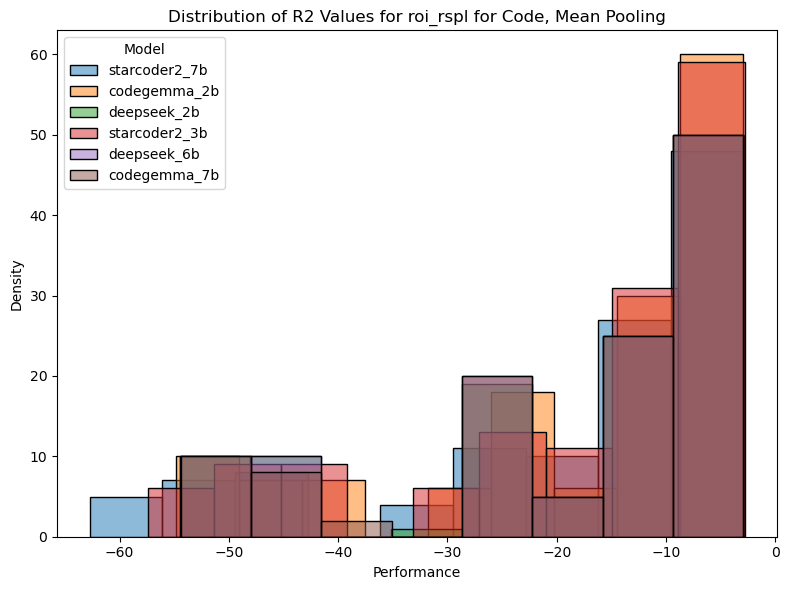

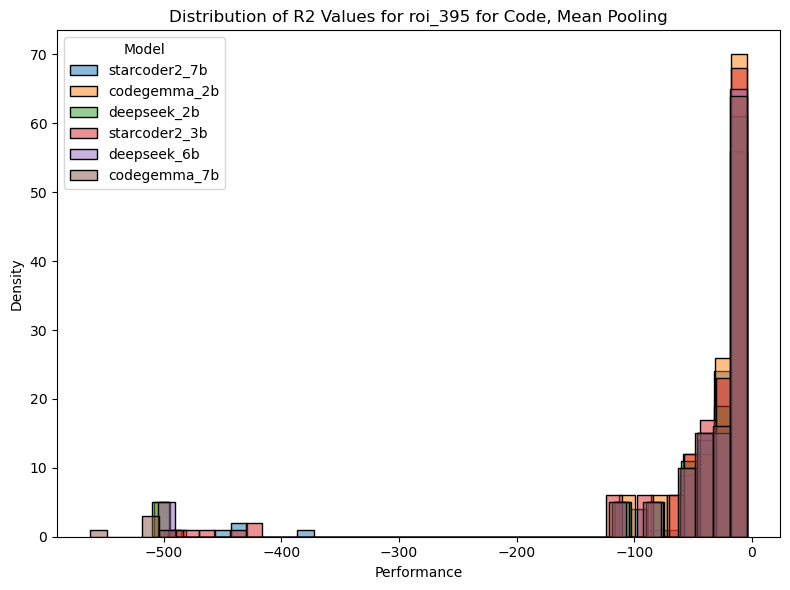

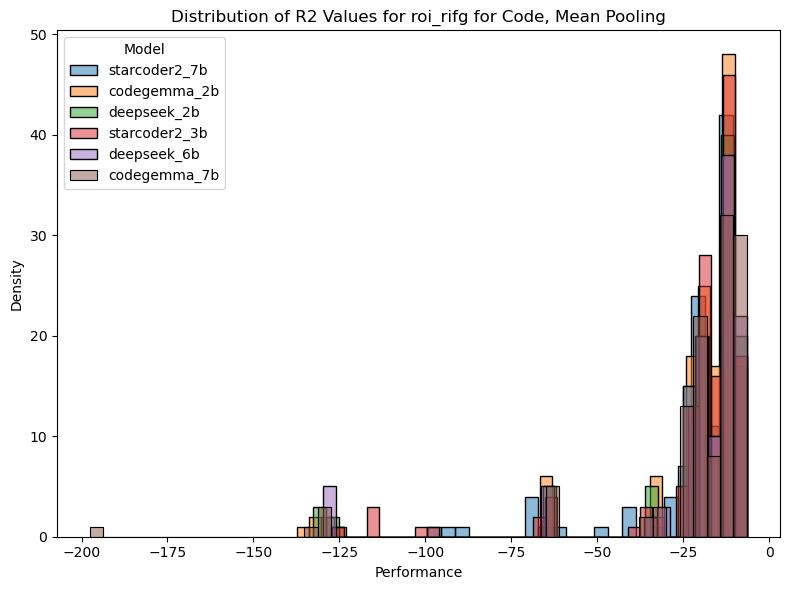

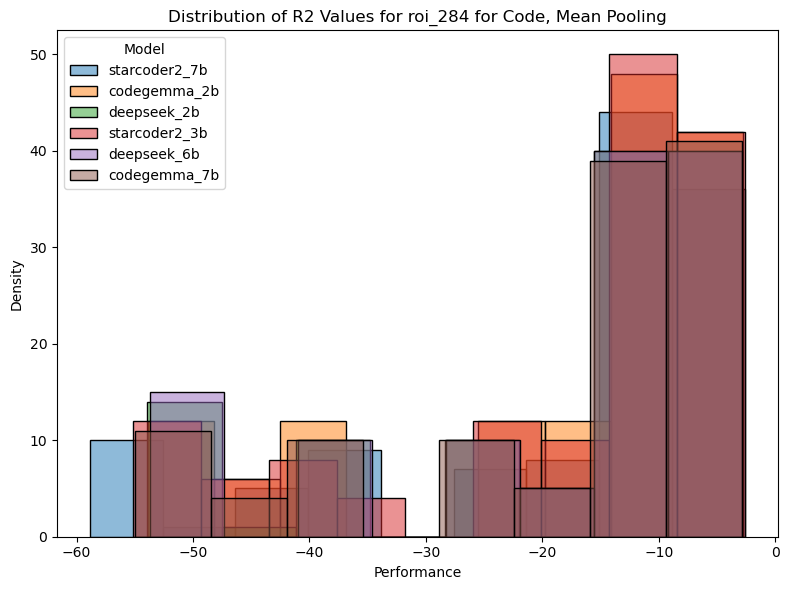

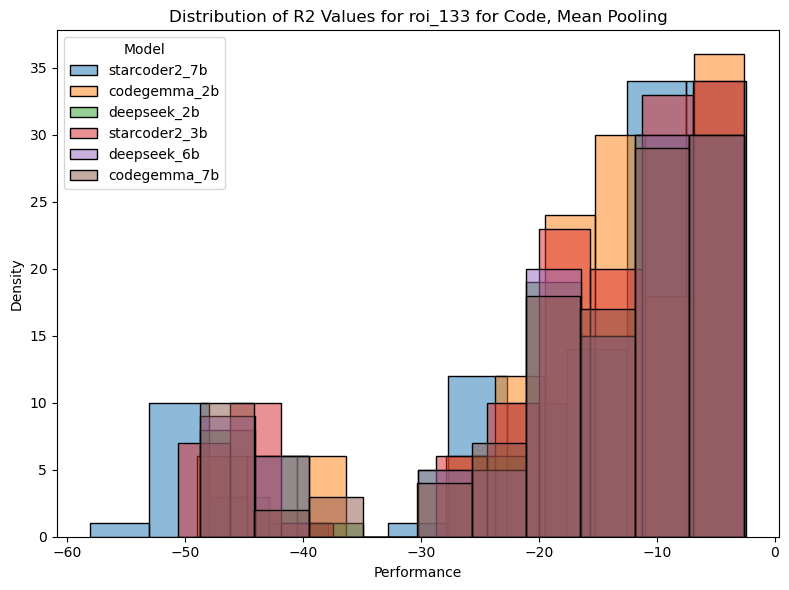

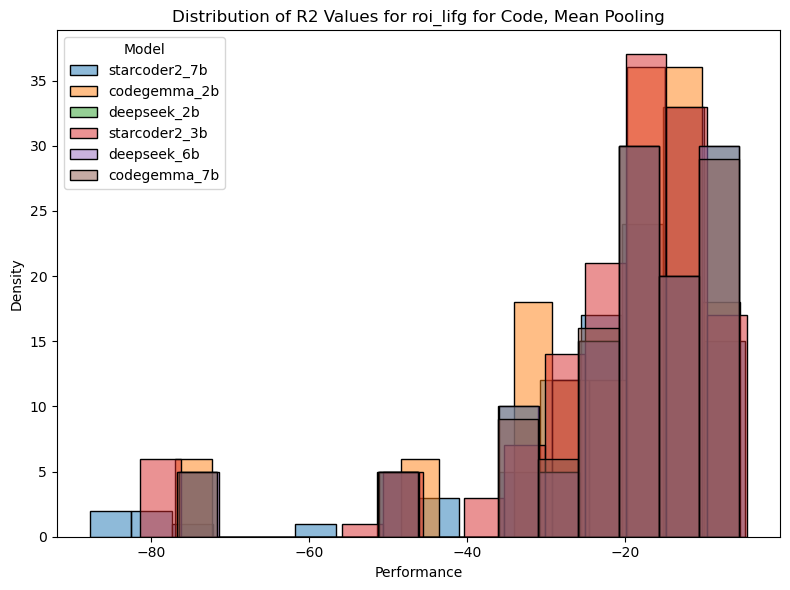

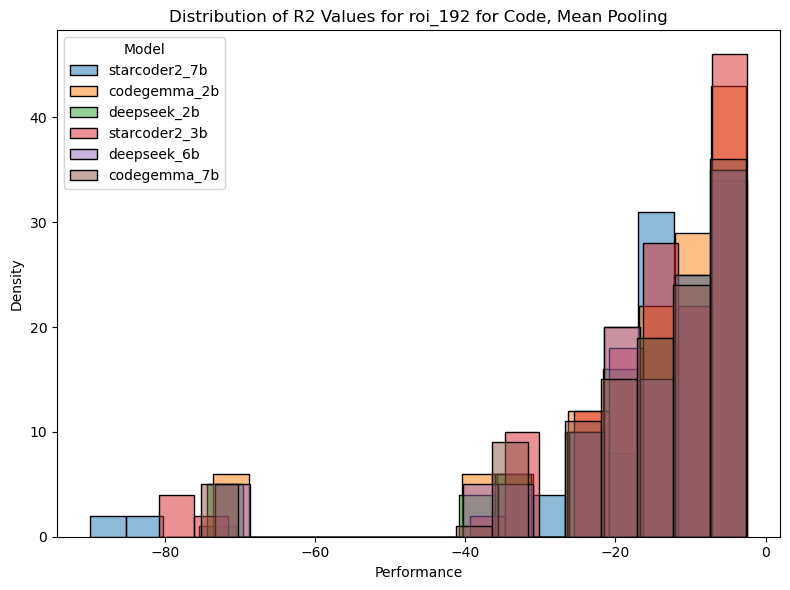

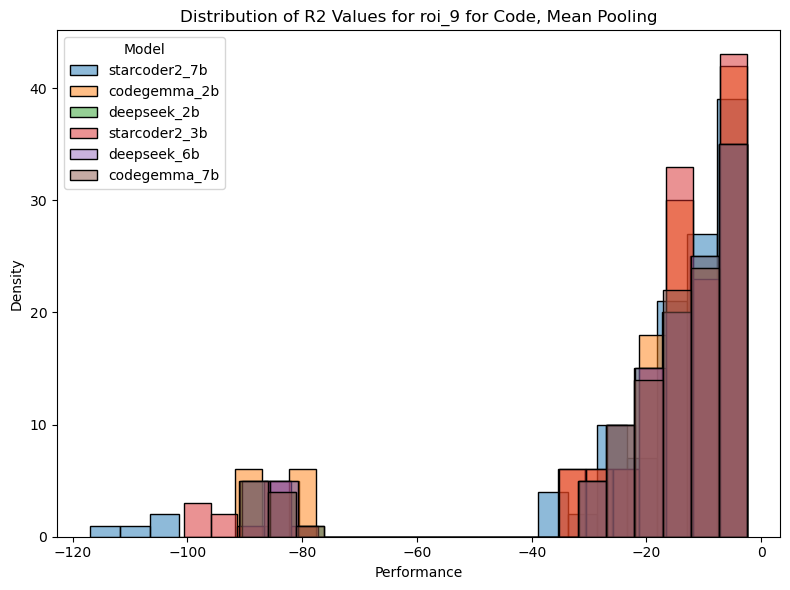

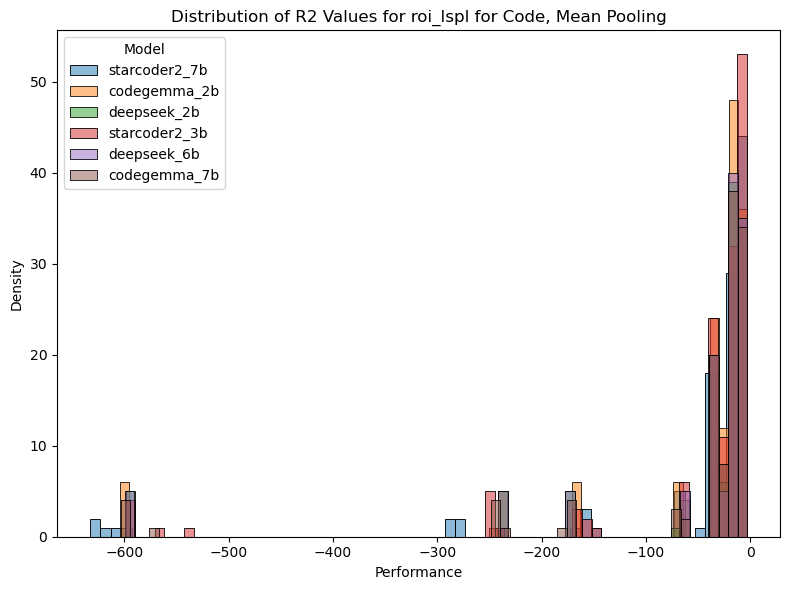

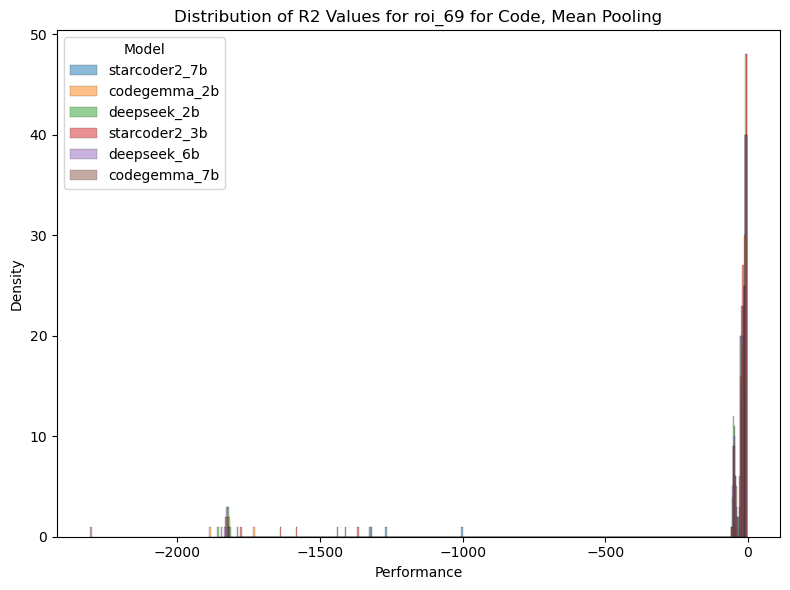

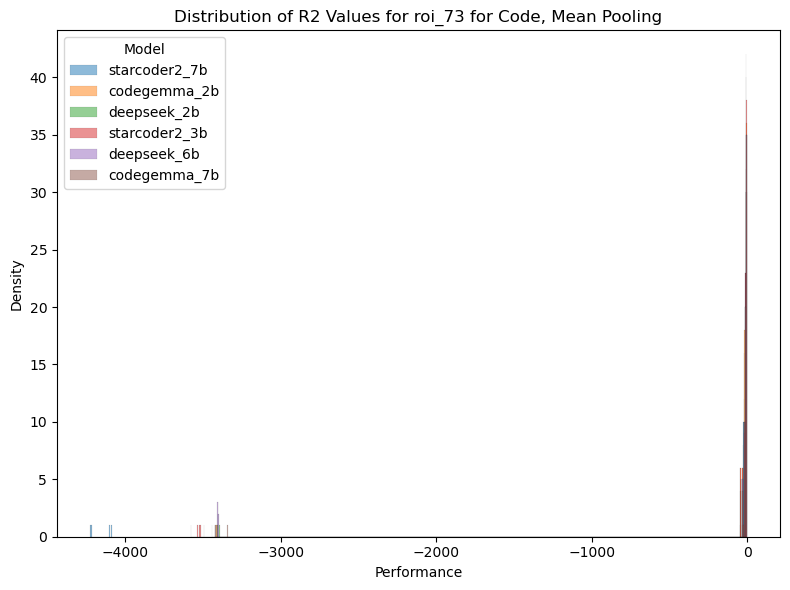

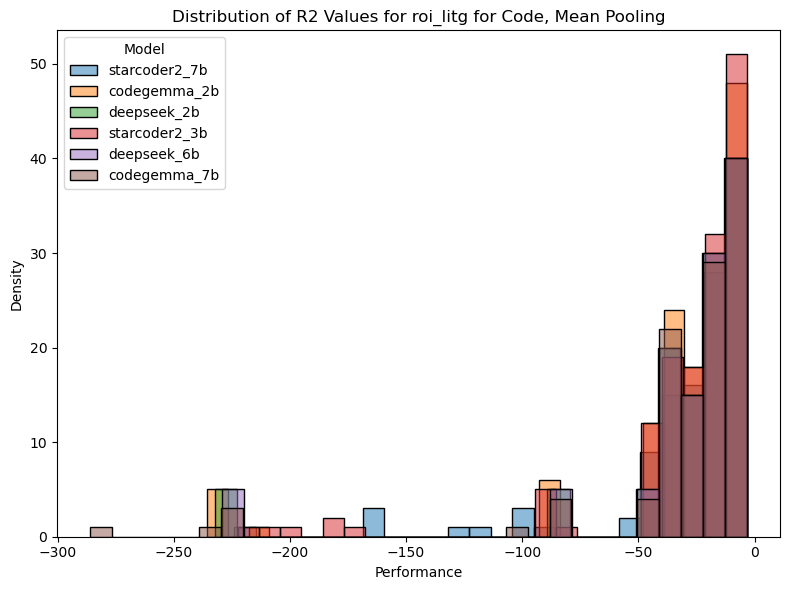

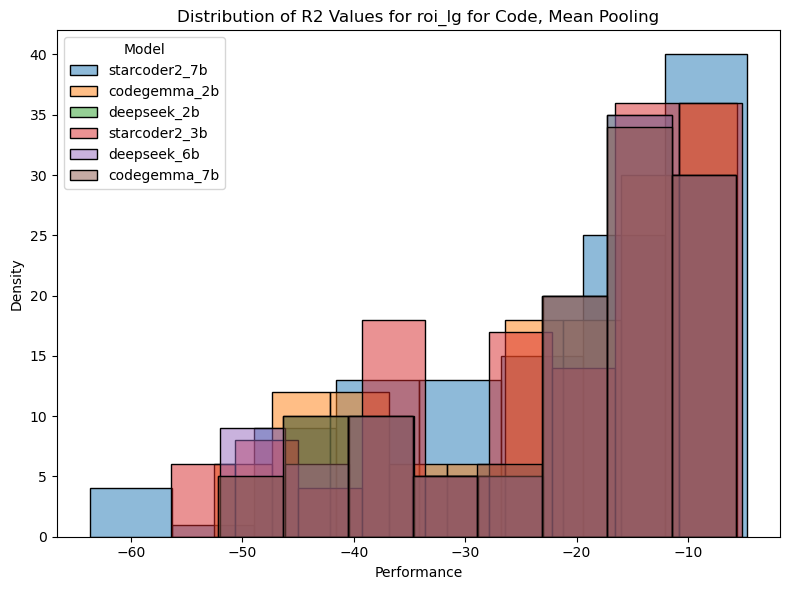

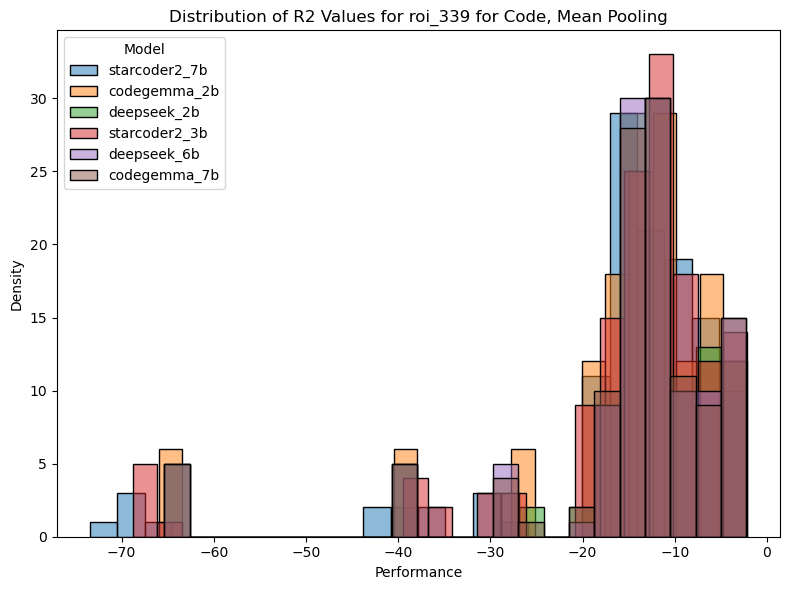

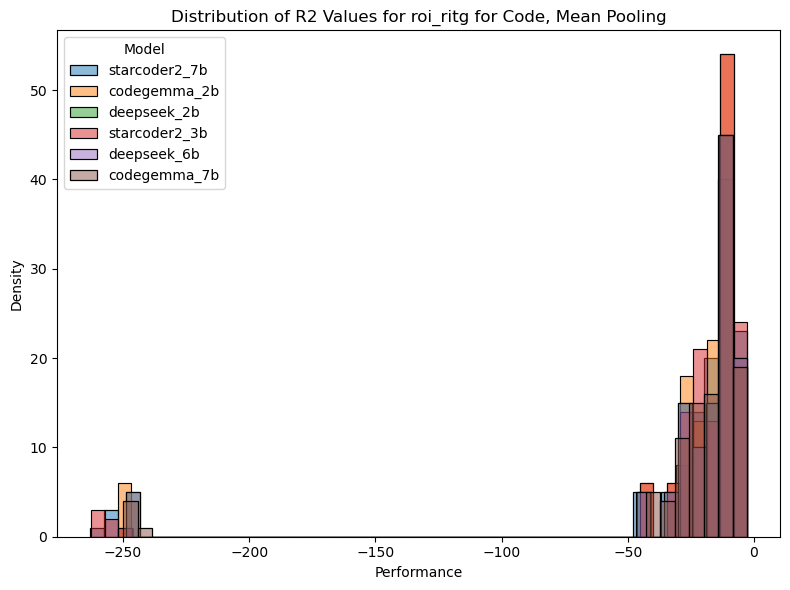

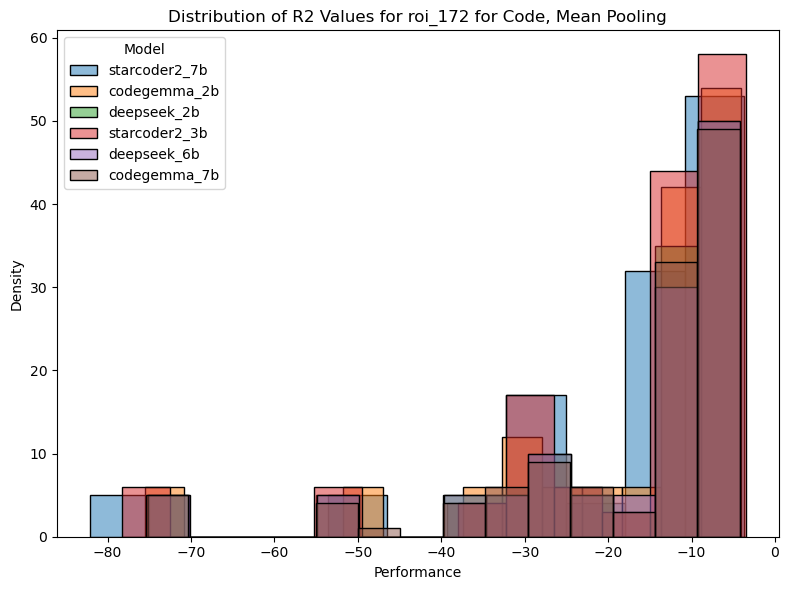

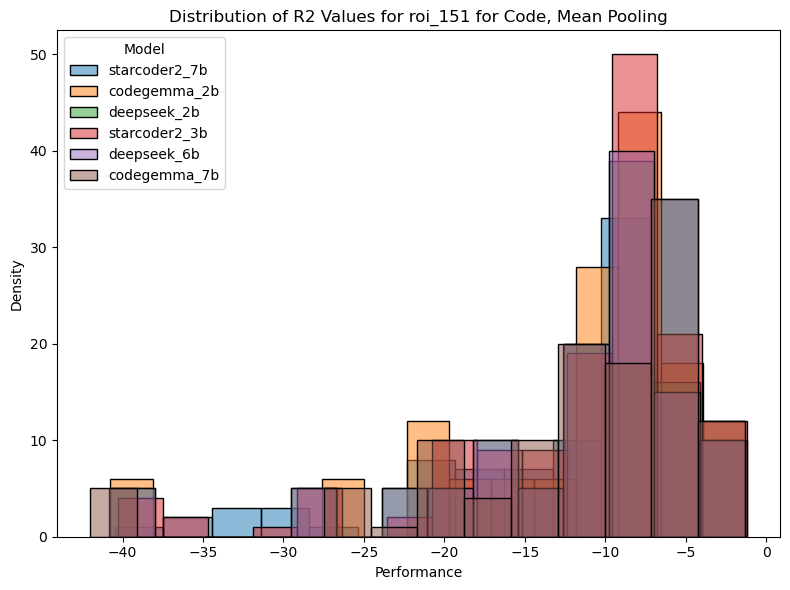

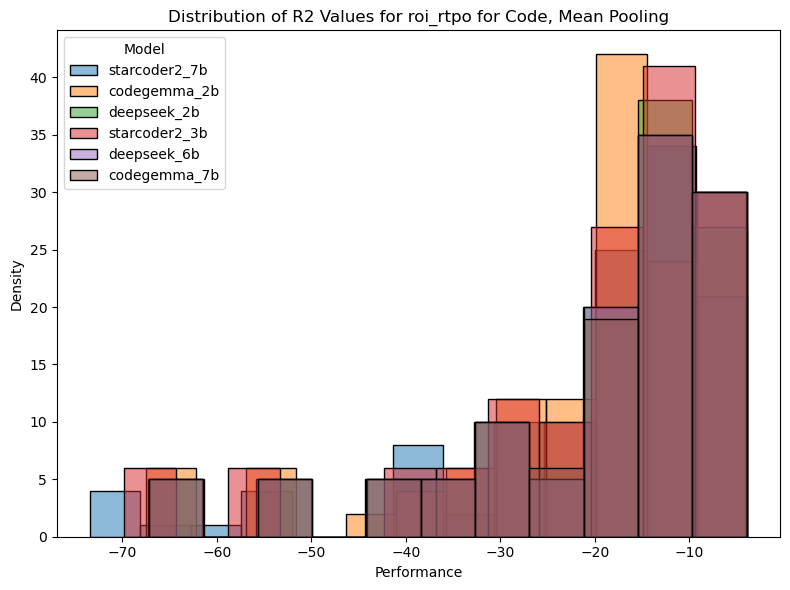

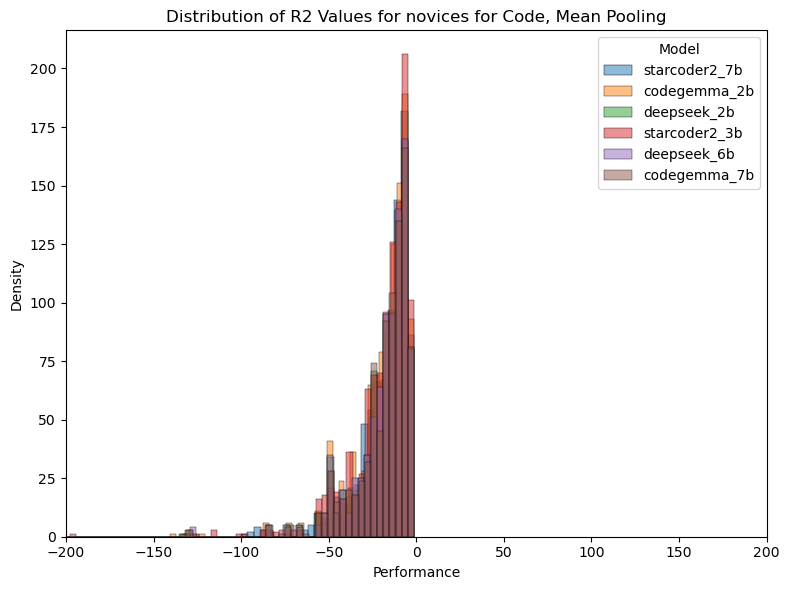

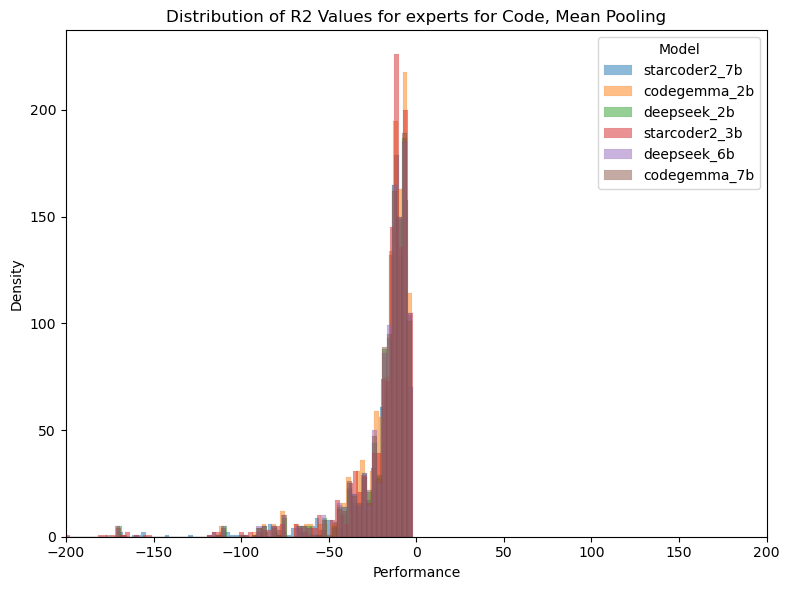

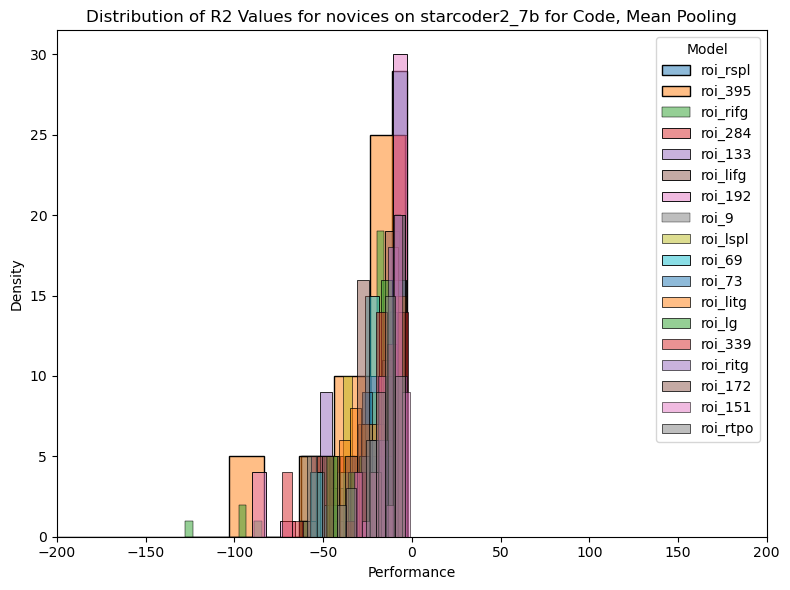

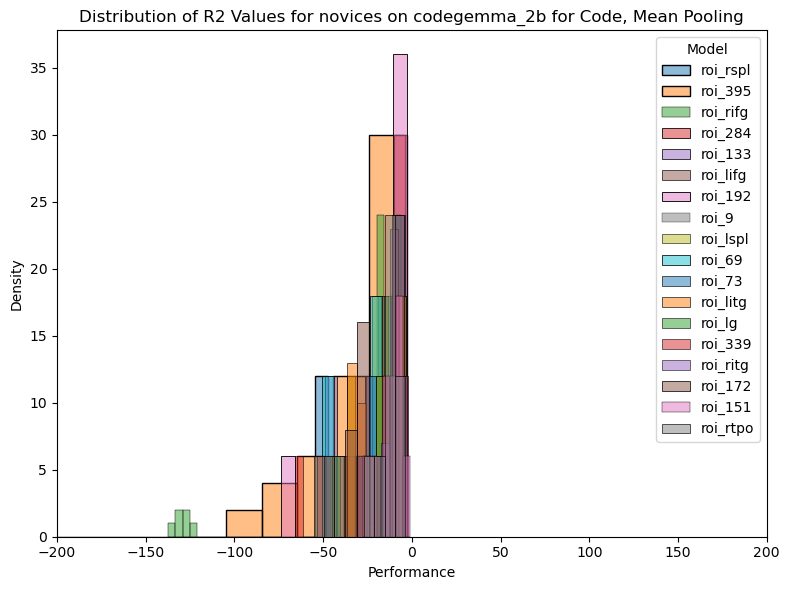

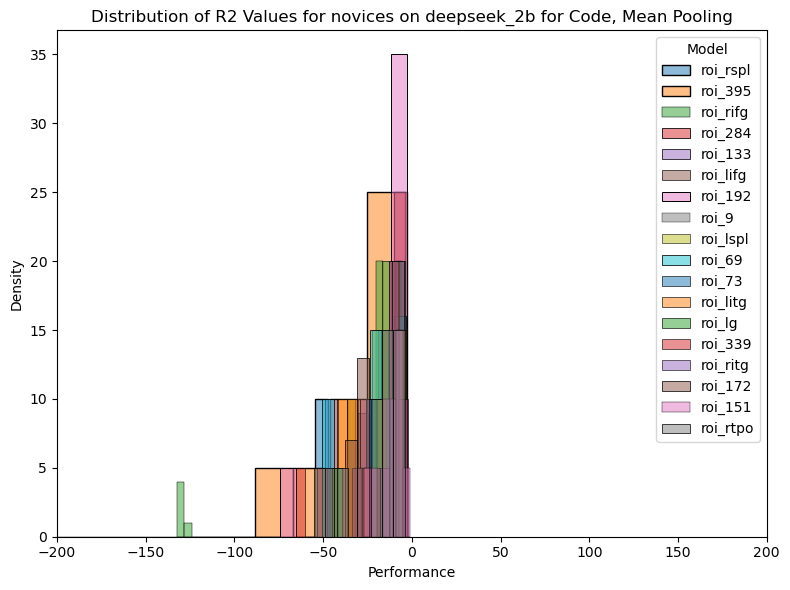

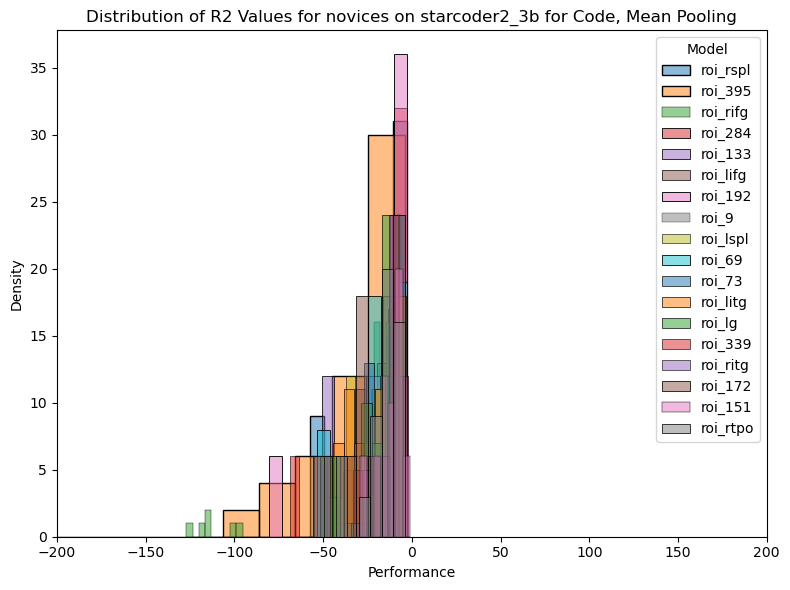

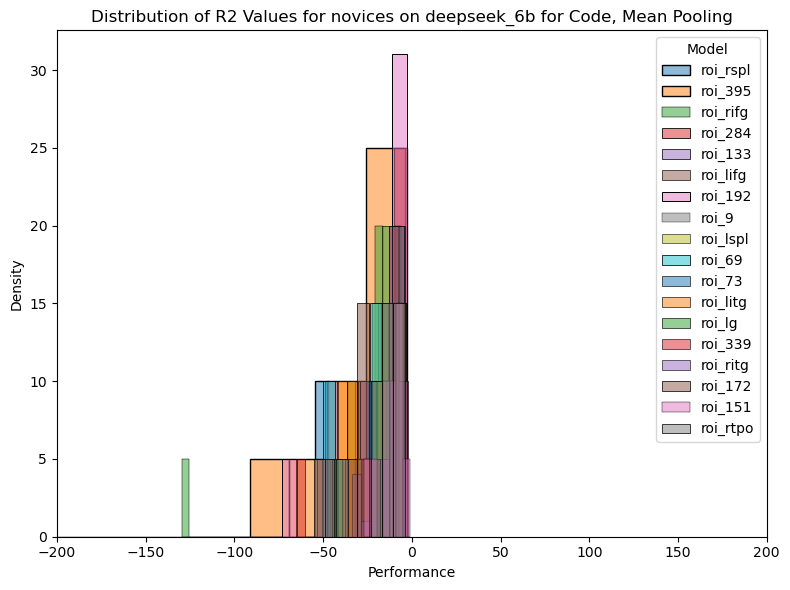

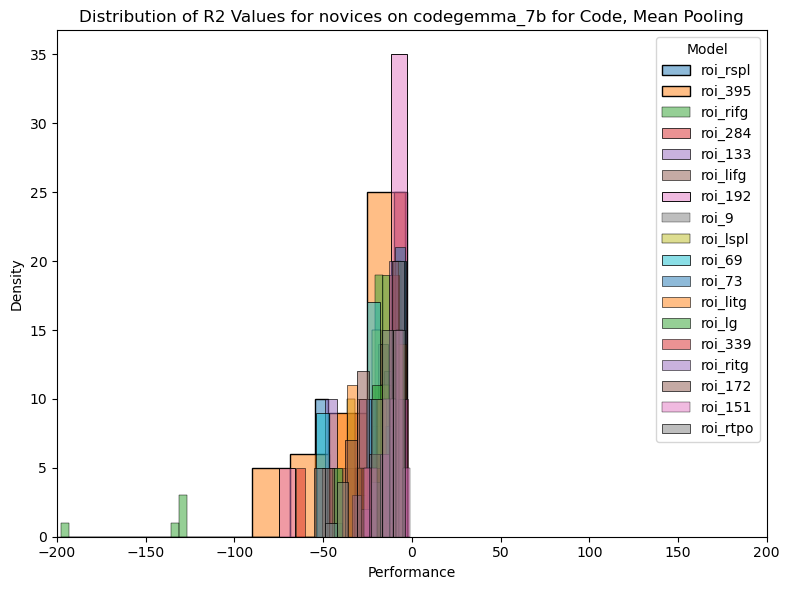

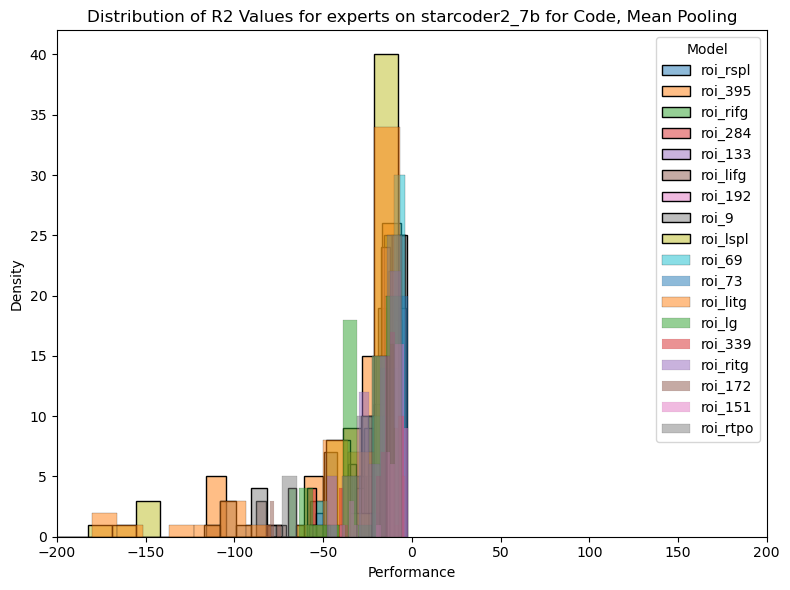

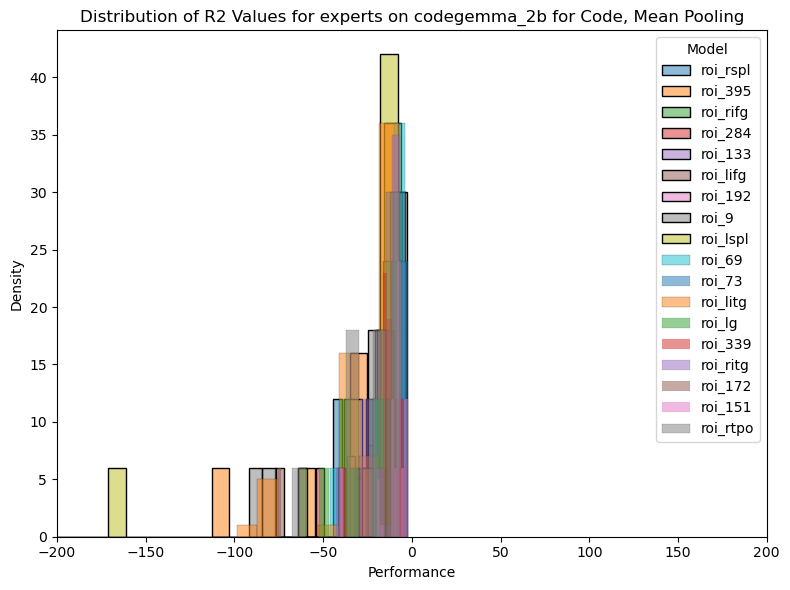

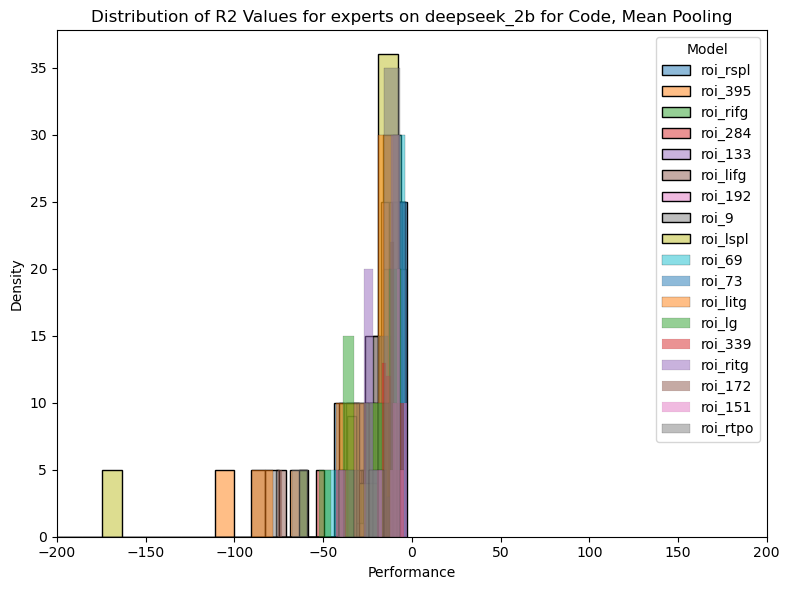

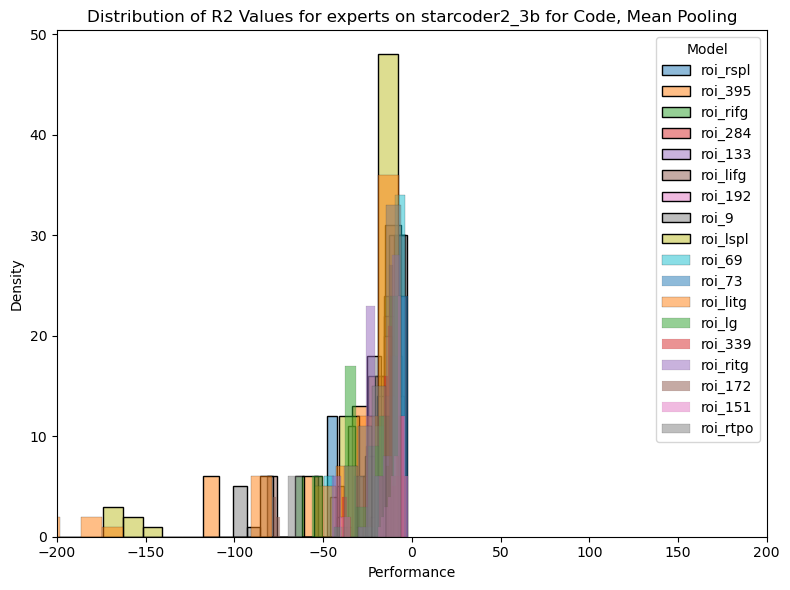

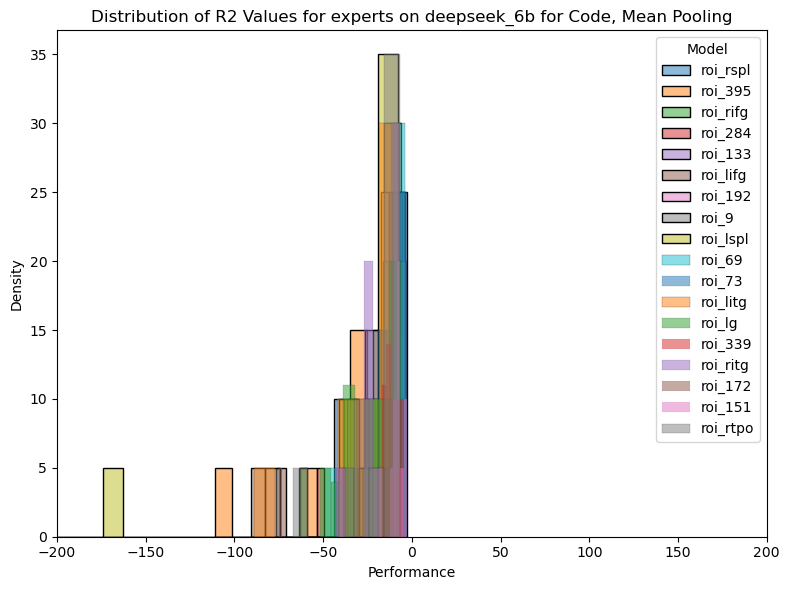

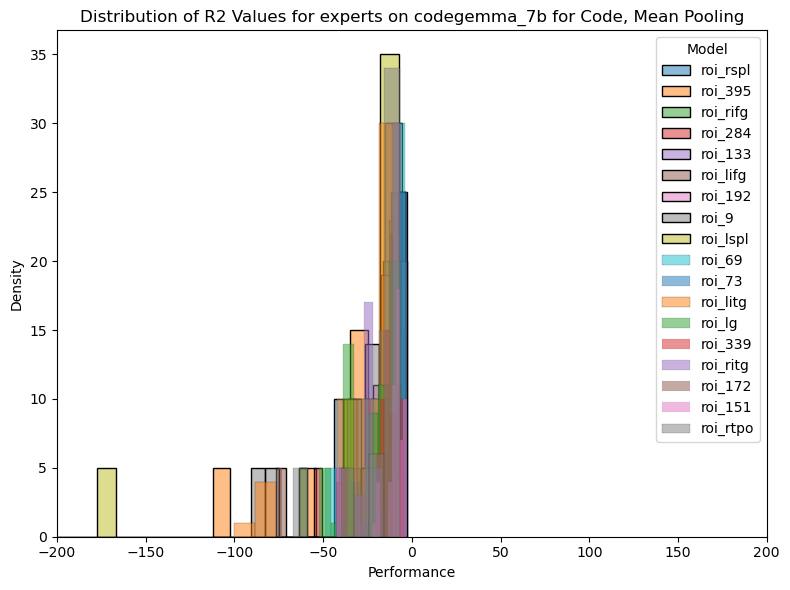

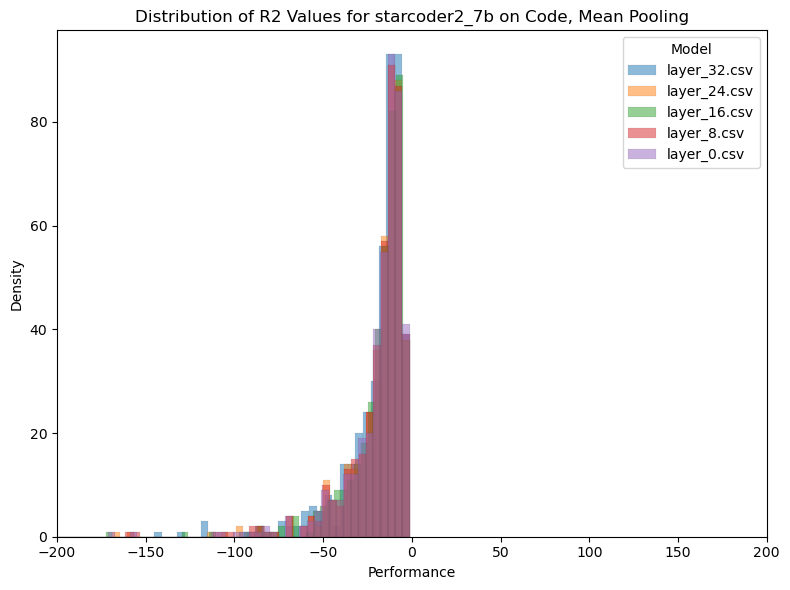

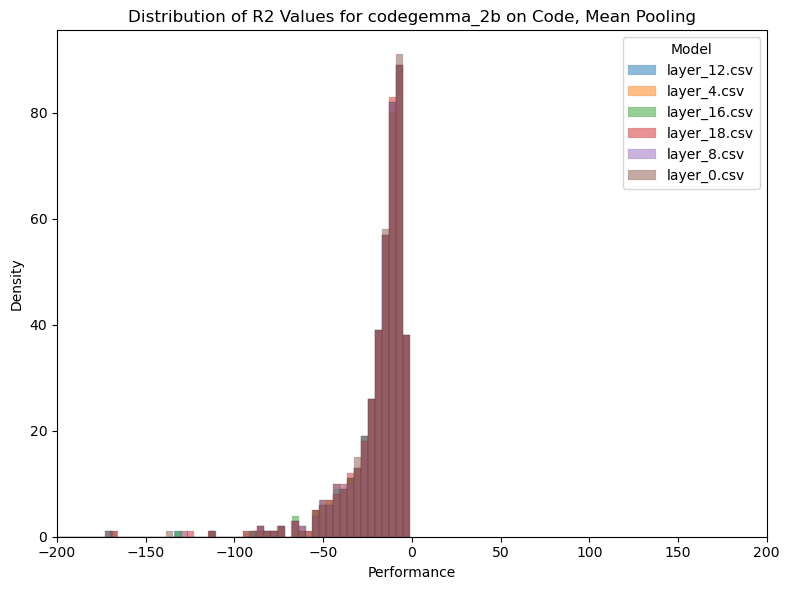

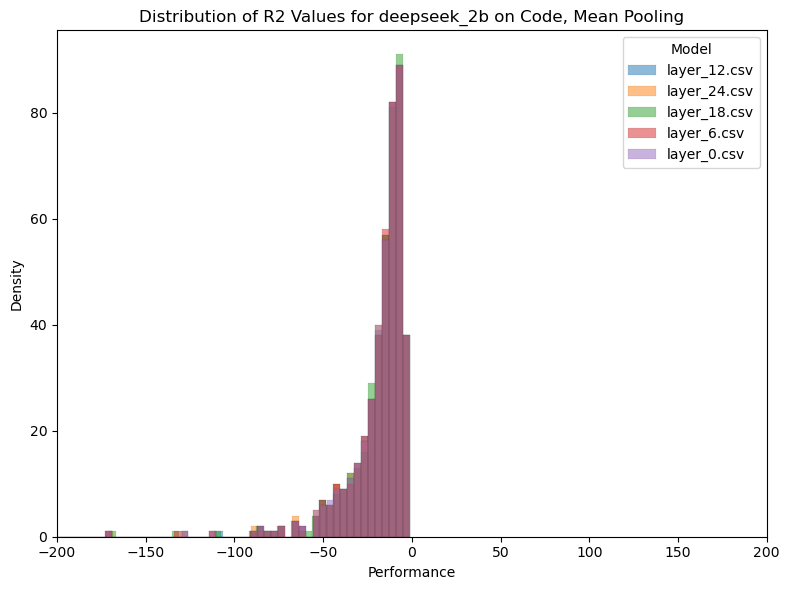

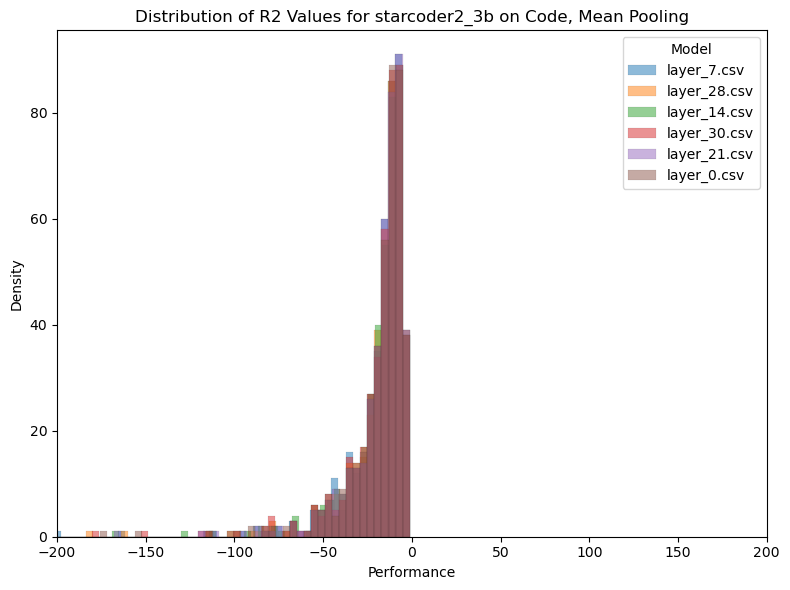

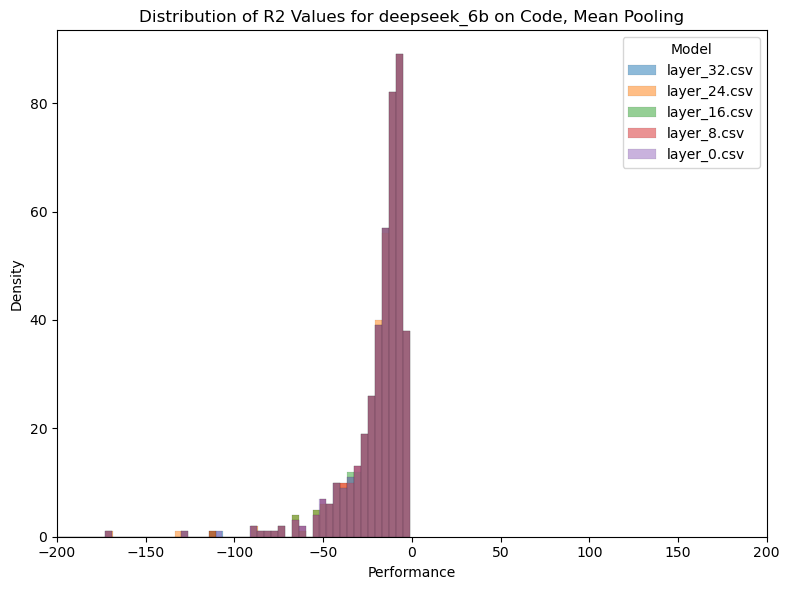

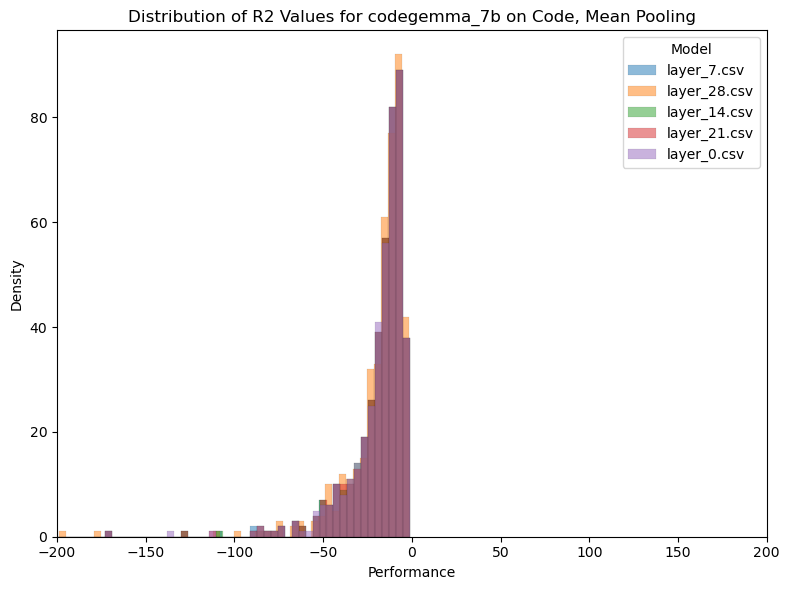

In [52]:
performance_by_roi(results_dict_mean_pooling_code, 'Mean Pooling', 'Code')

performance_by_expertise(results_dict_mean_pooling_code, 'Mean Pooling', 'Code')

performance_by_layer(results_dict_mean_pooling_code, 'Mean Pooling', 'Code')

# Mean Pooling Prose

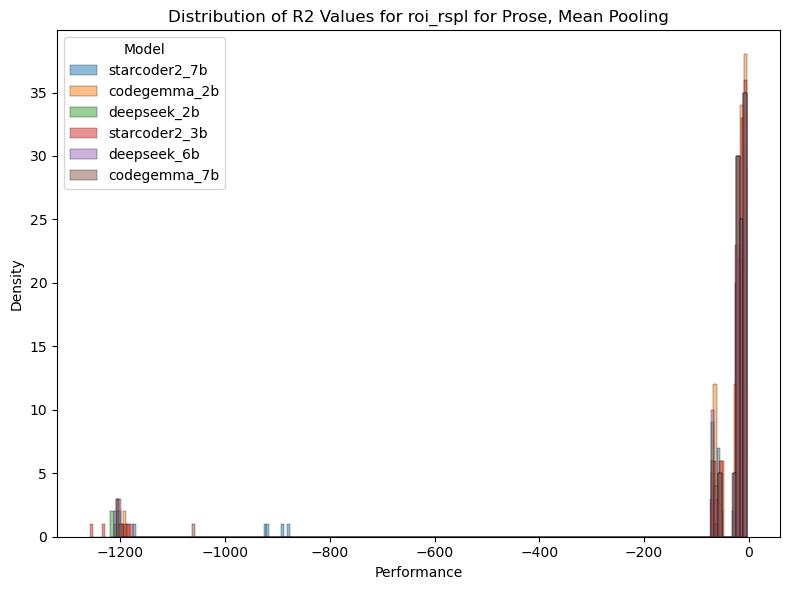

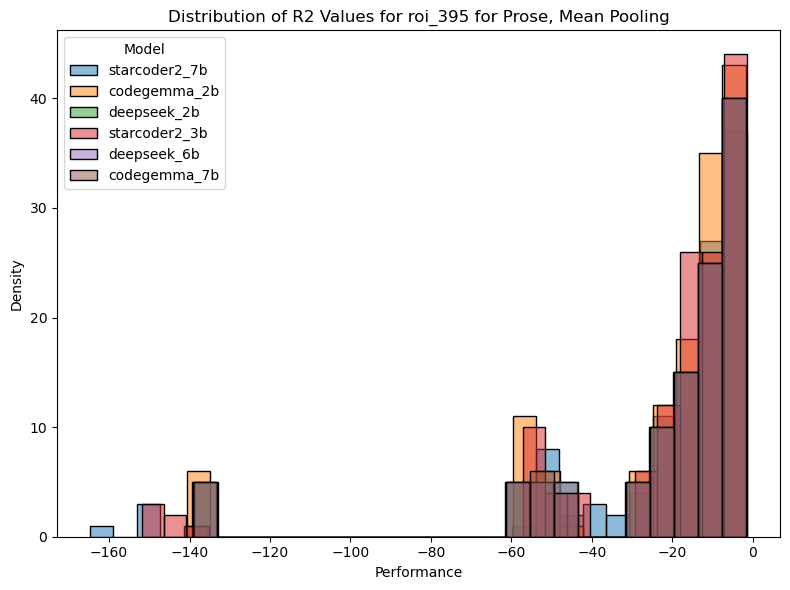

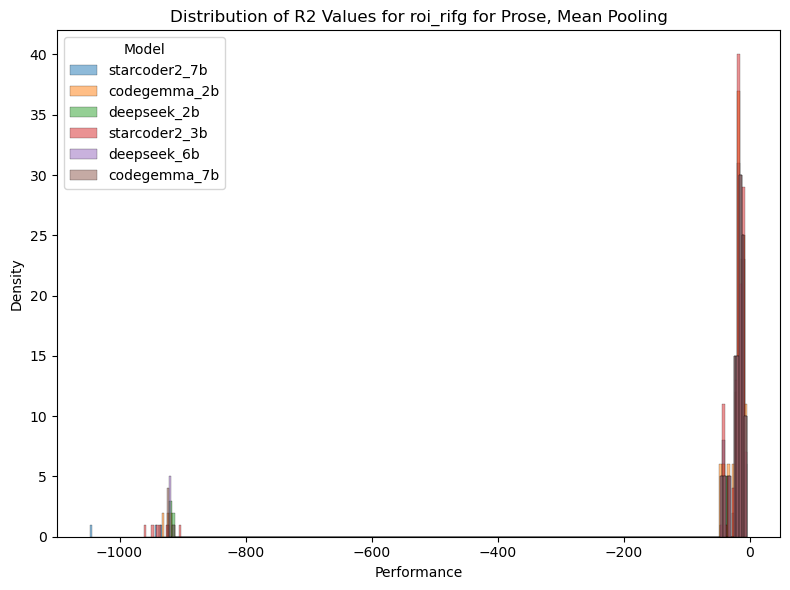

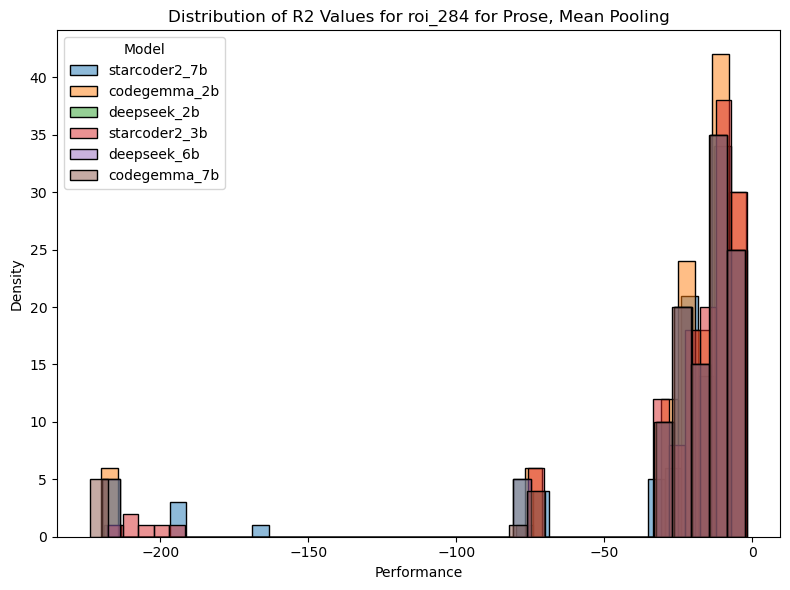

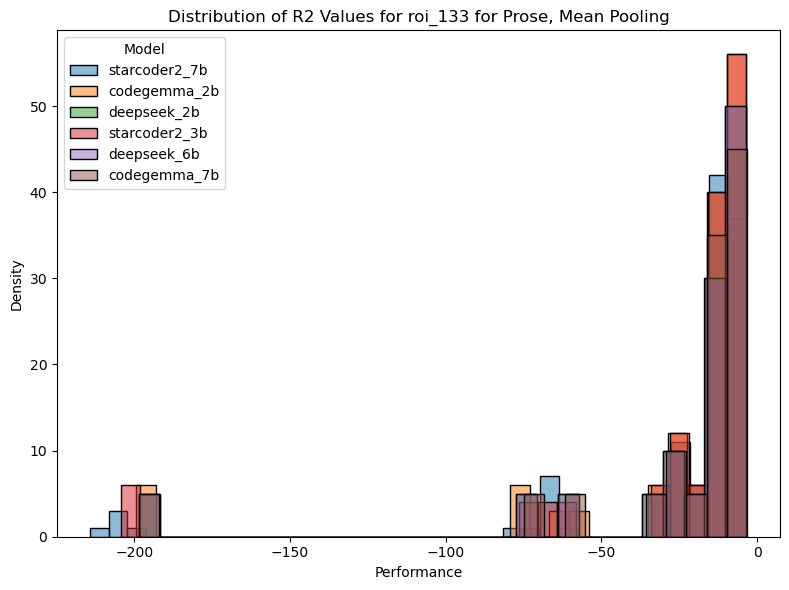

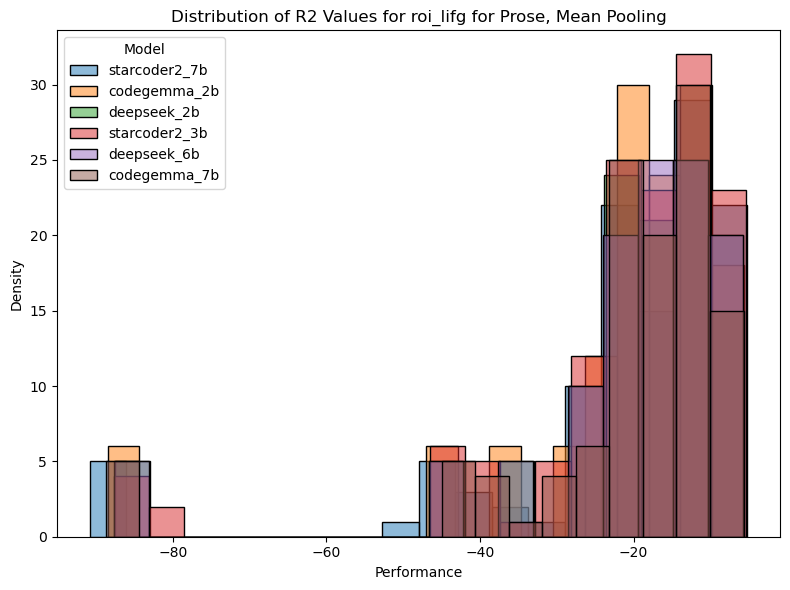

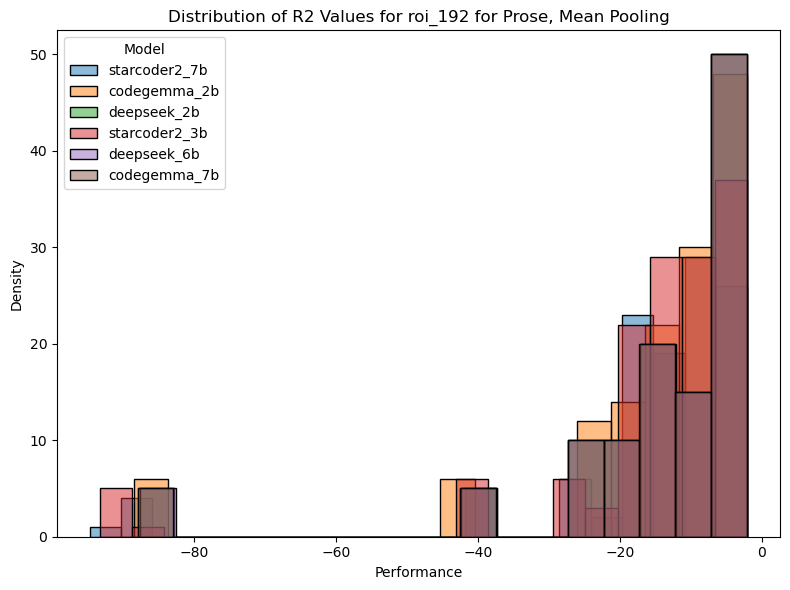

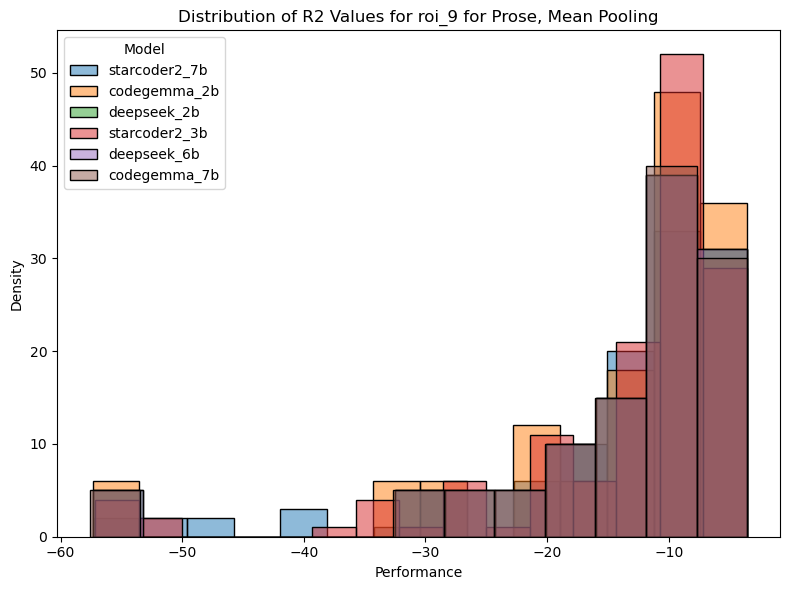

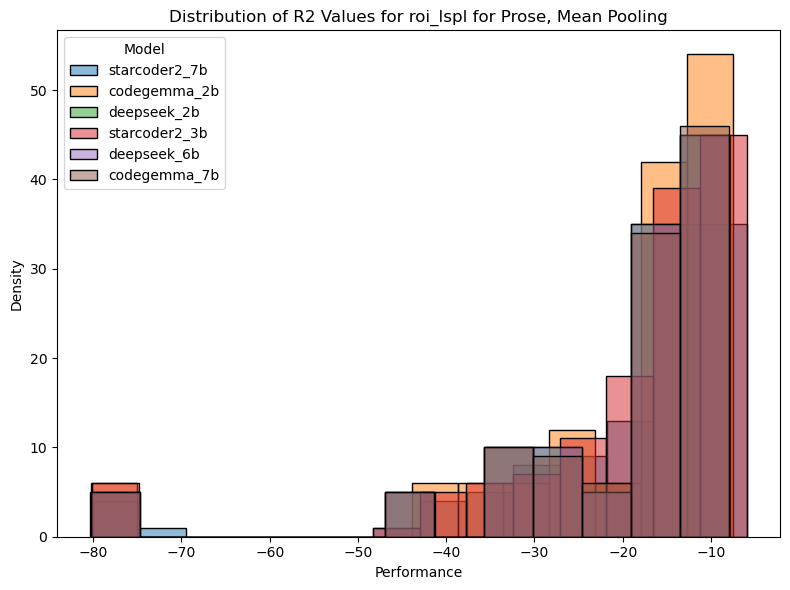

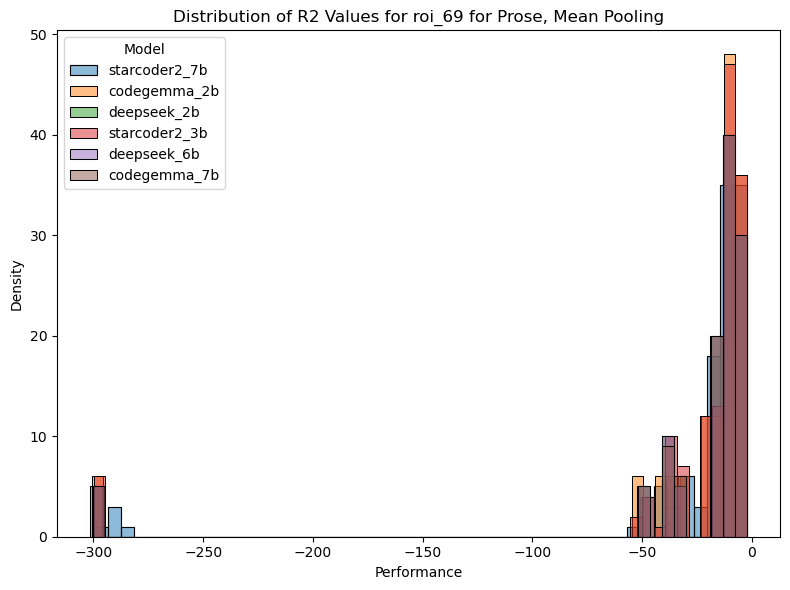

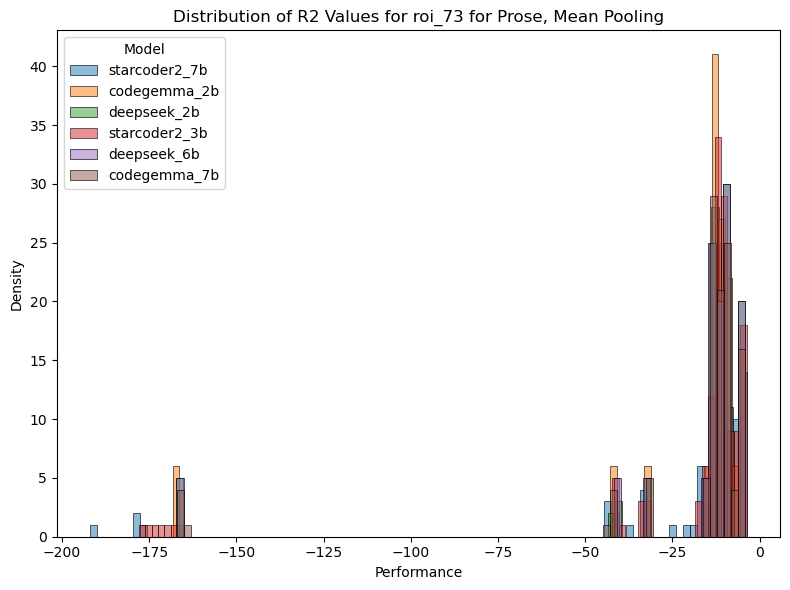

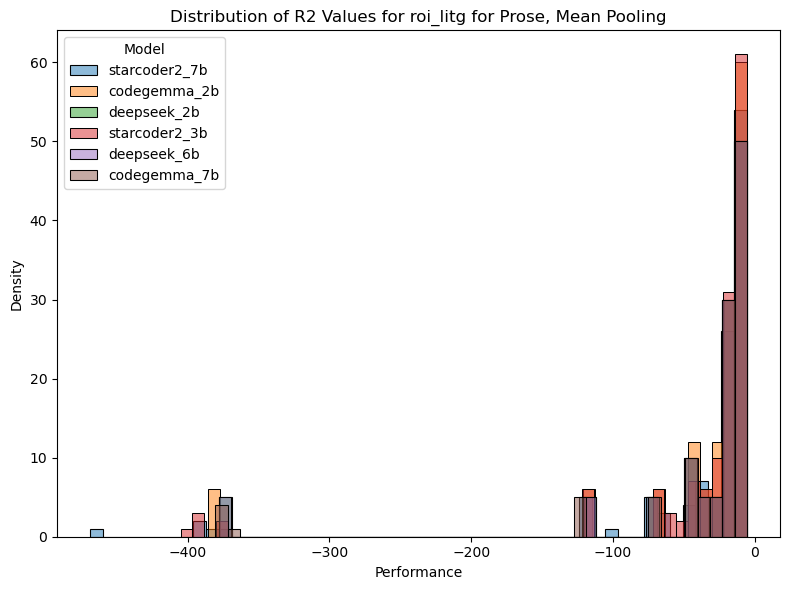

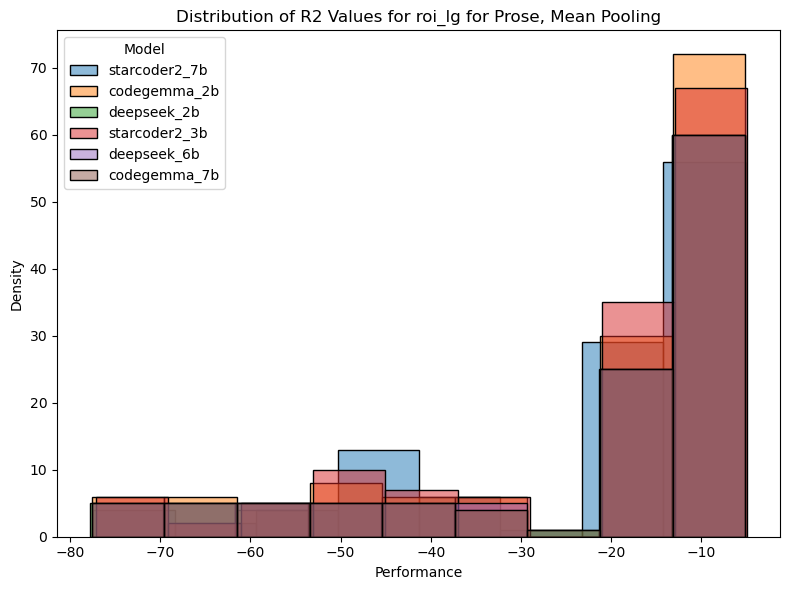

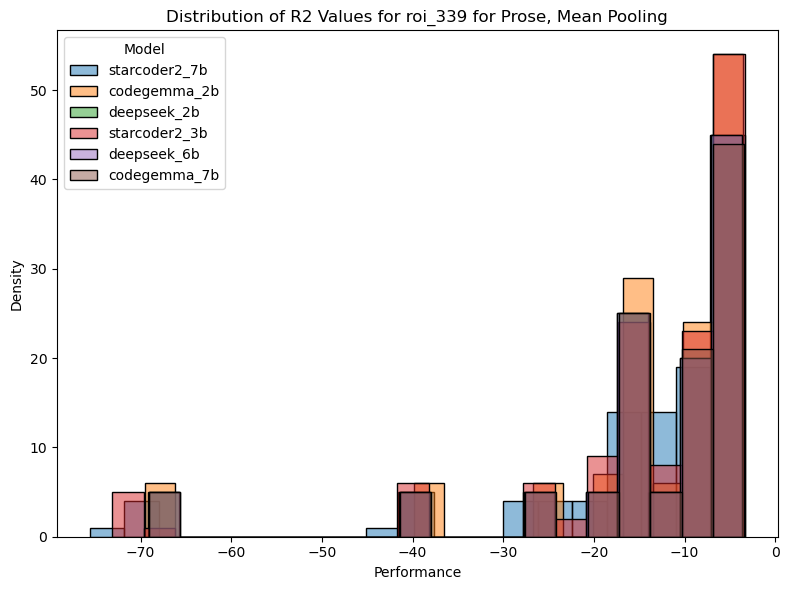

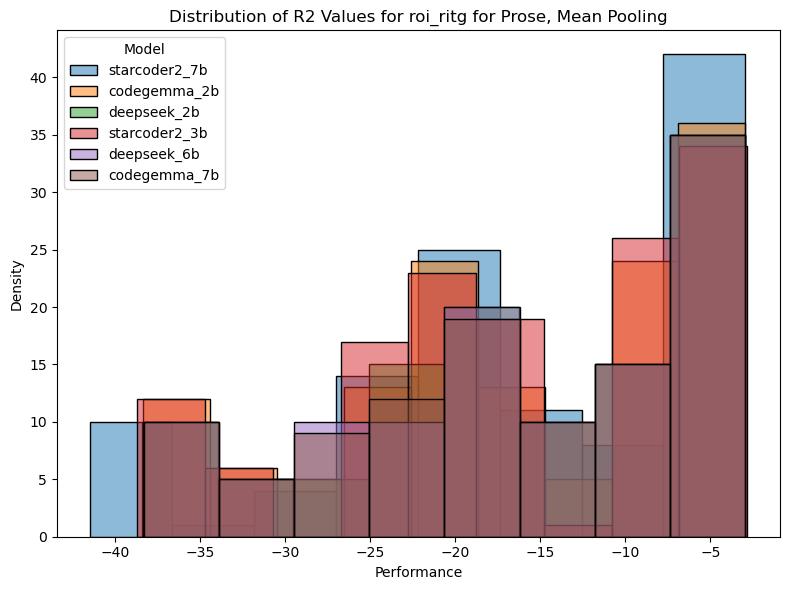

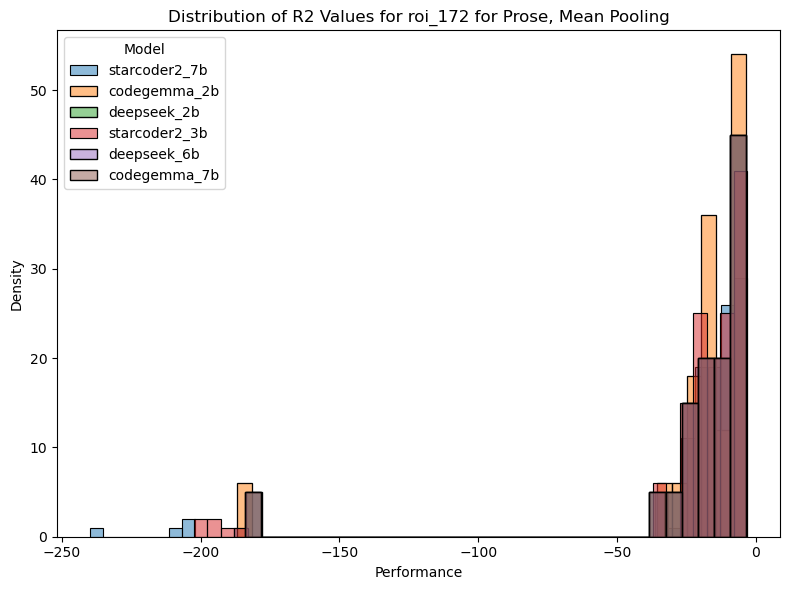

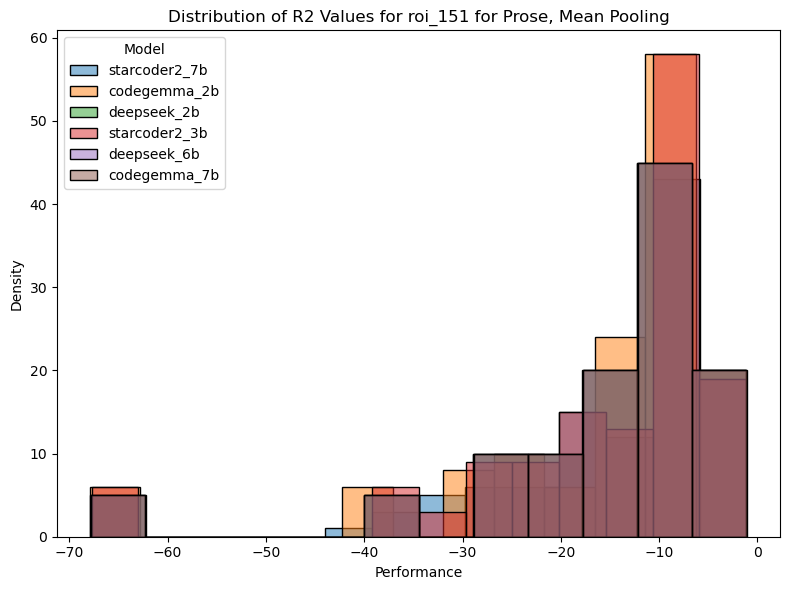

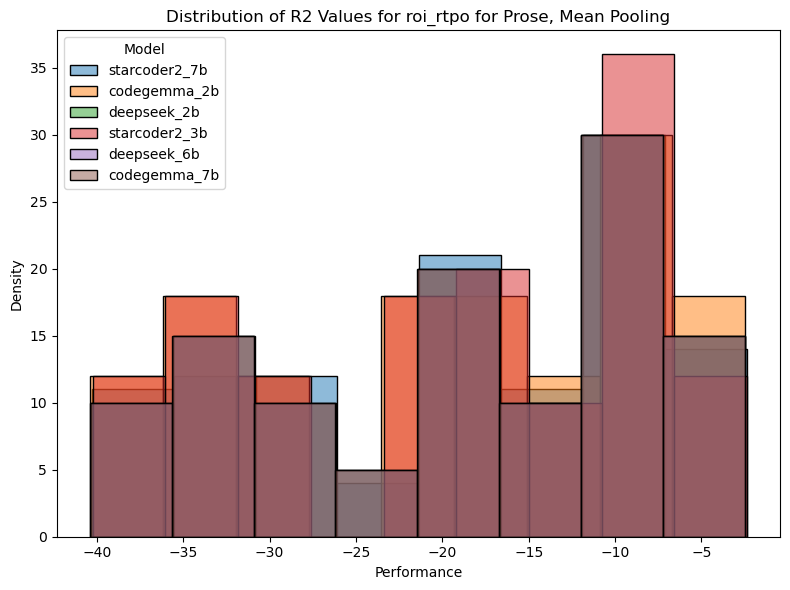

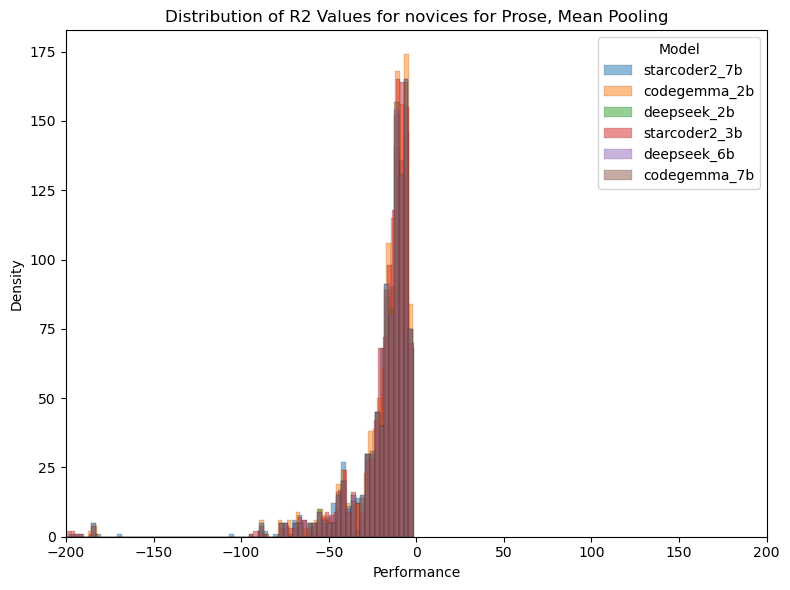

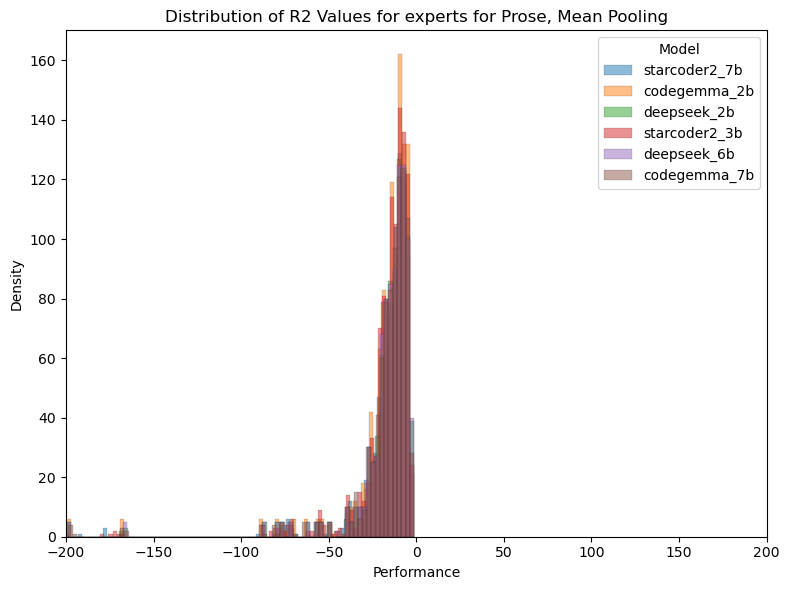

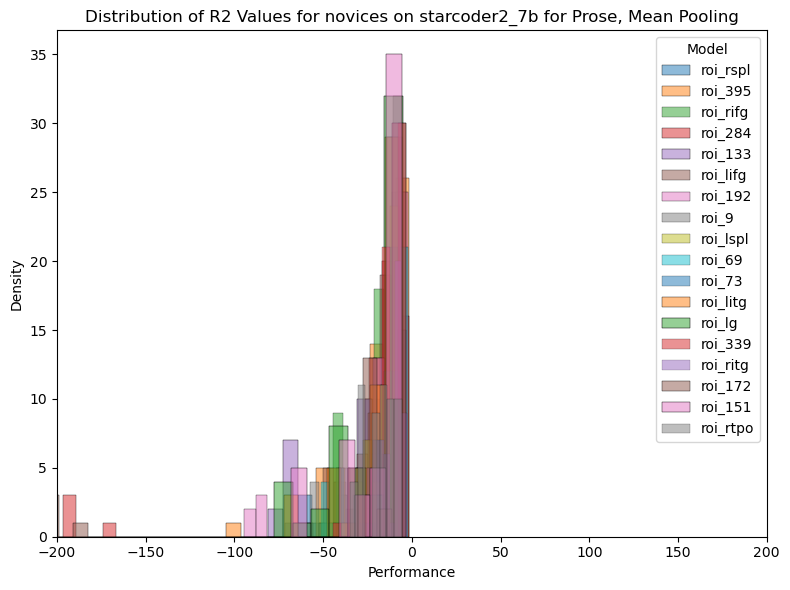

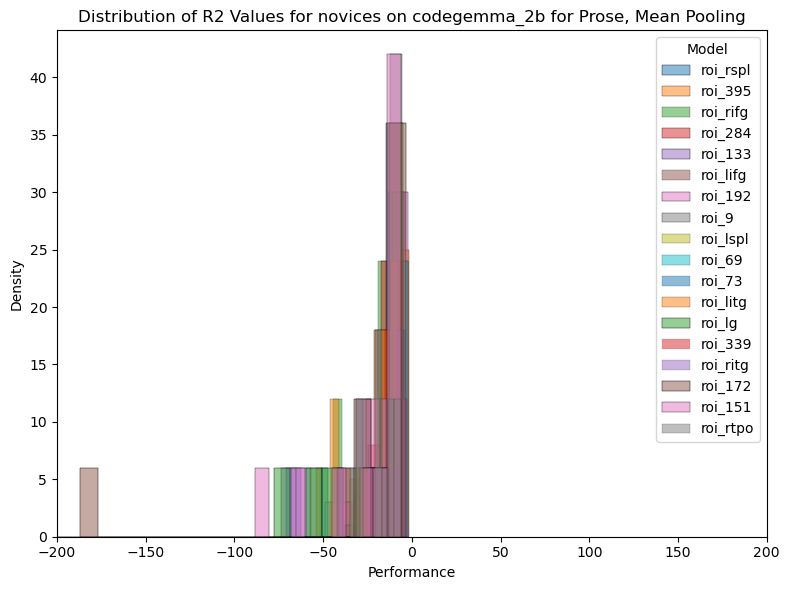

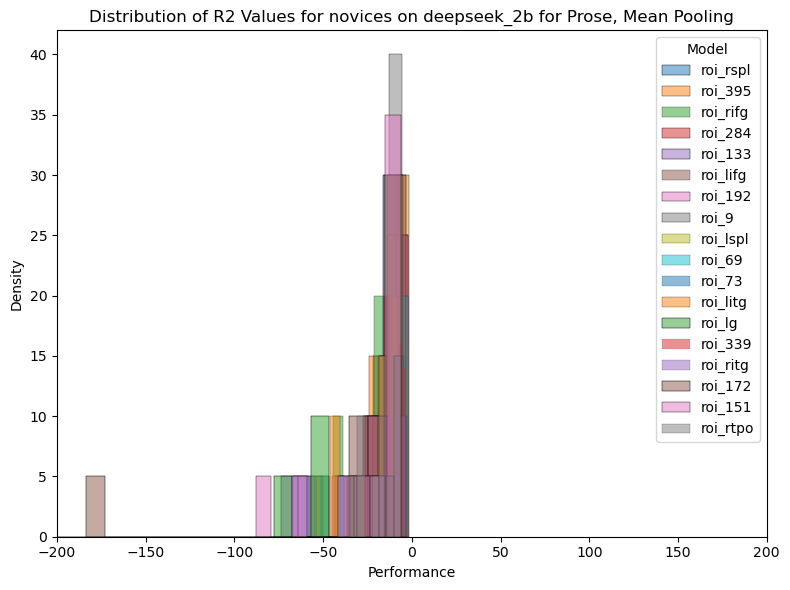

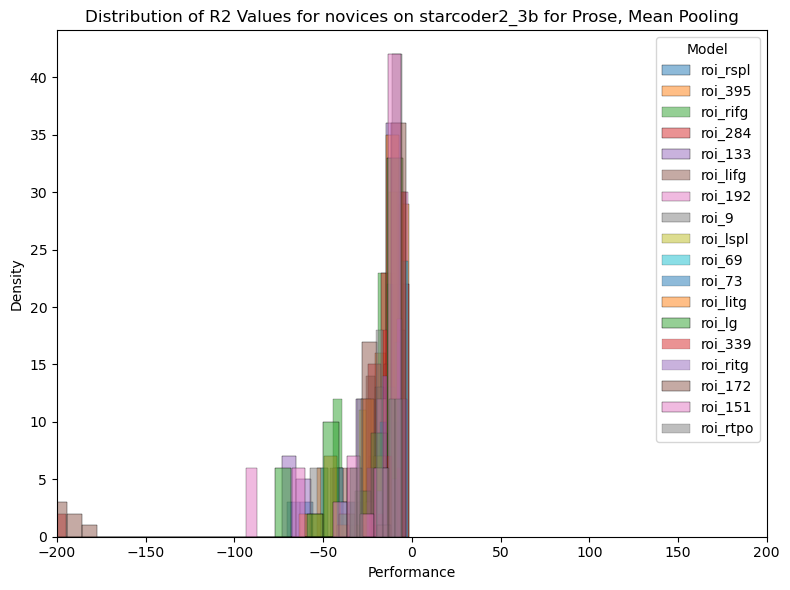

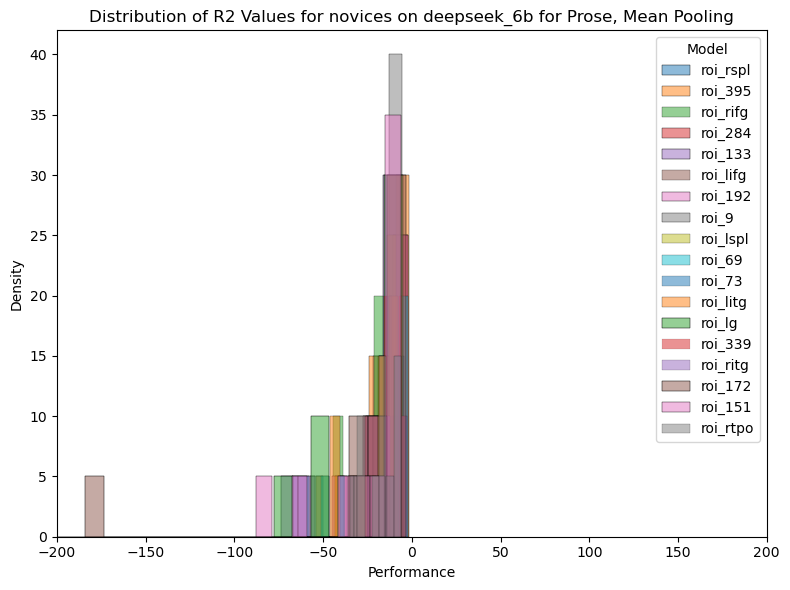

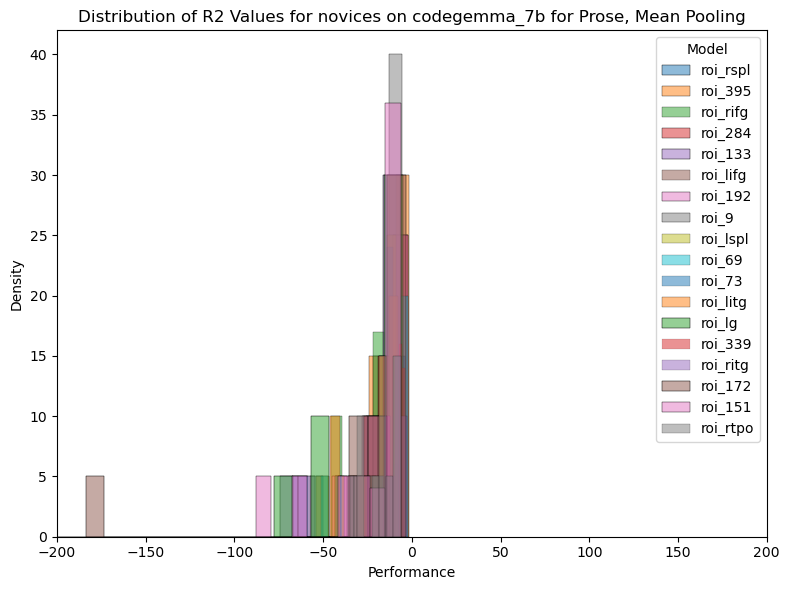

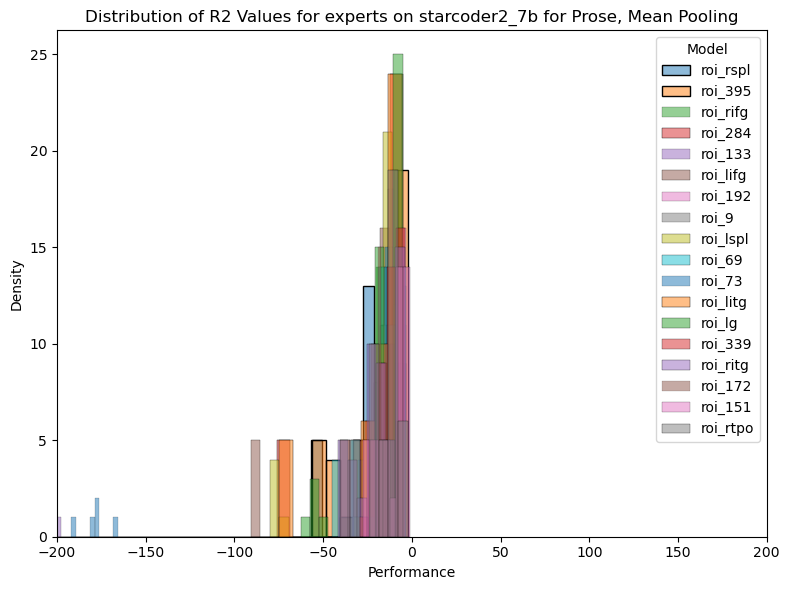

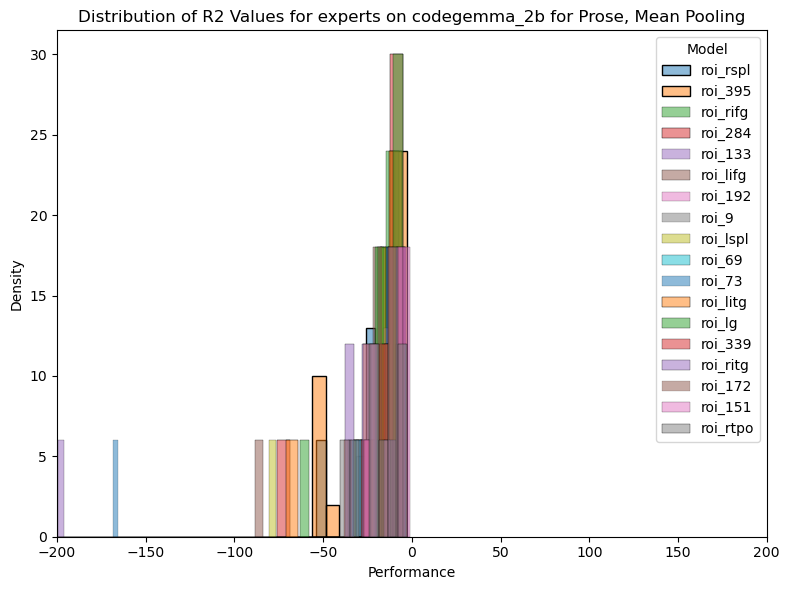

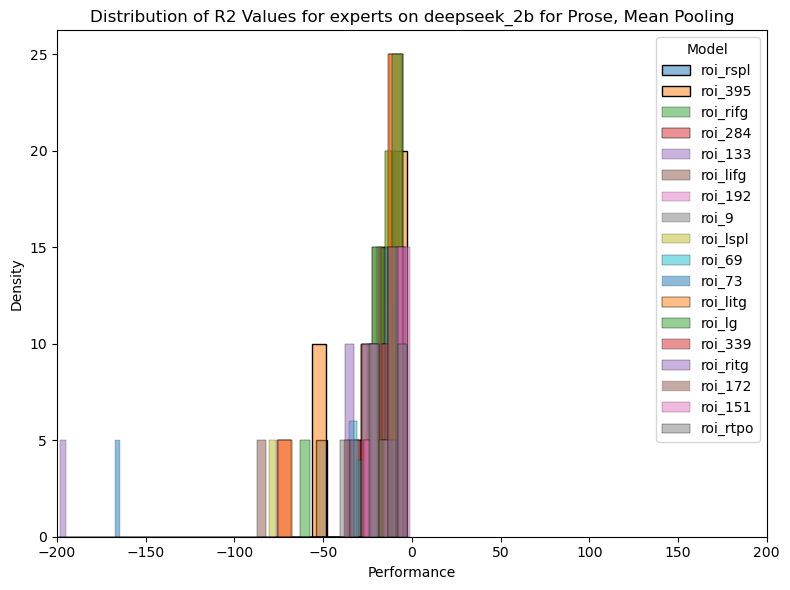

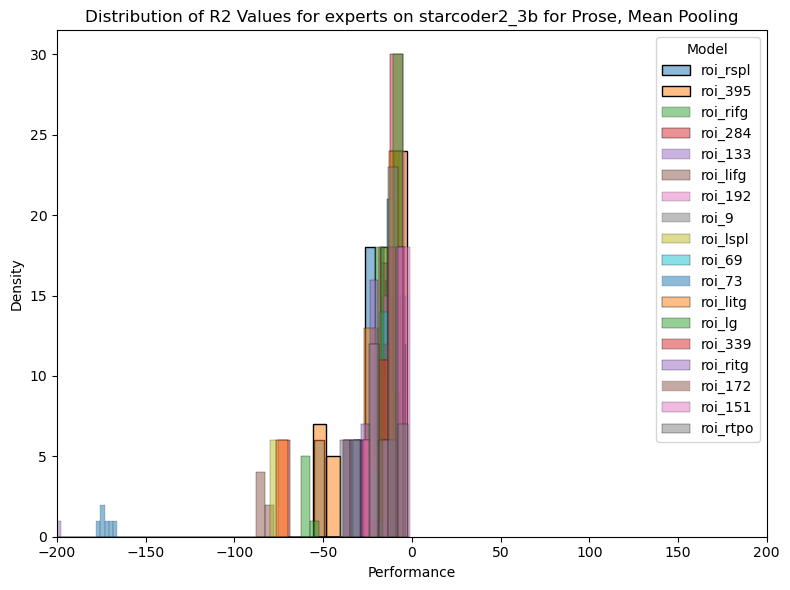

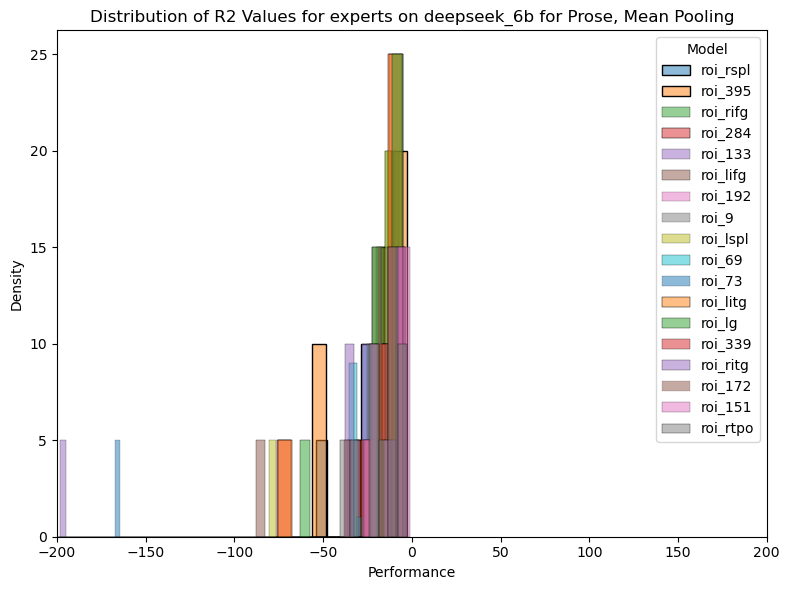

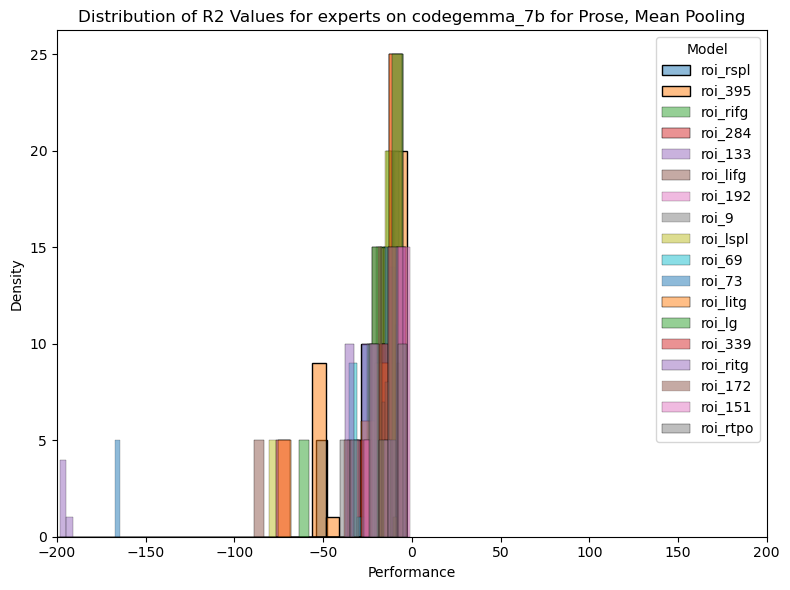

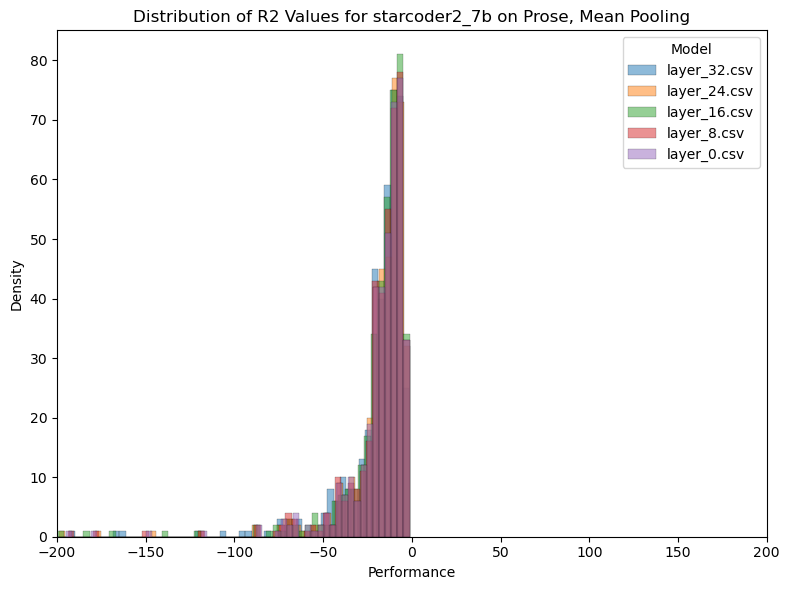

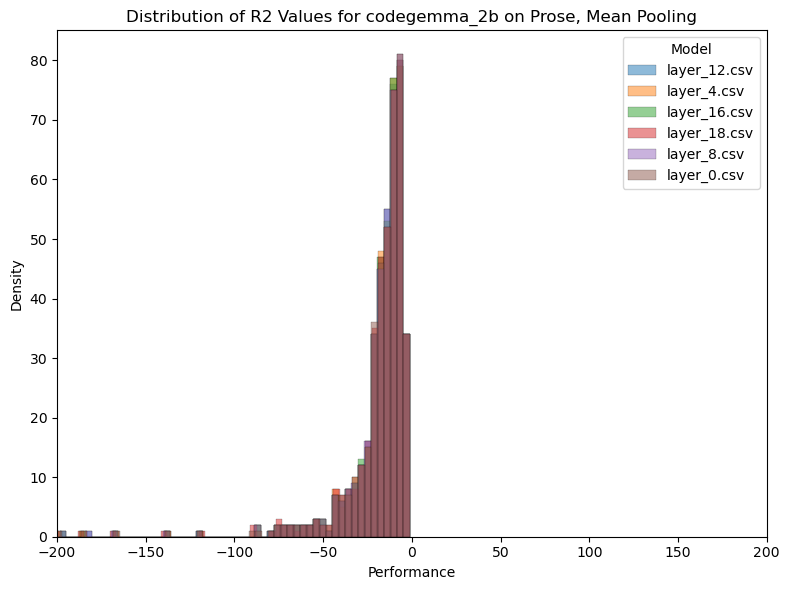

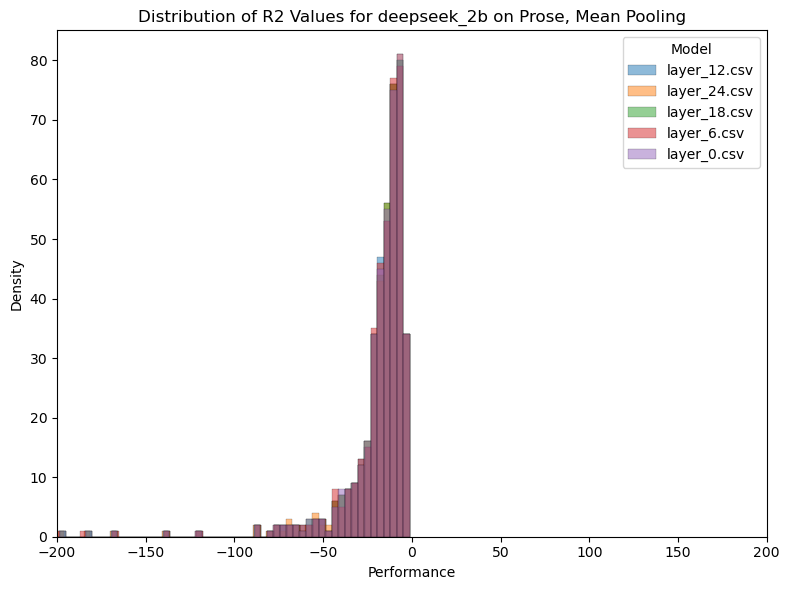

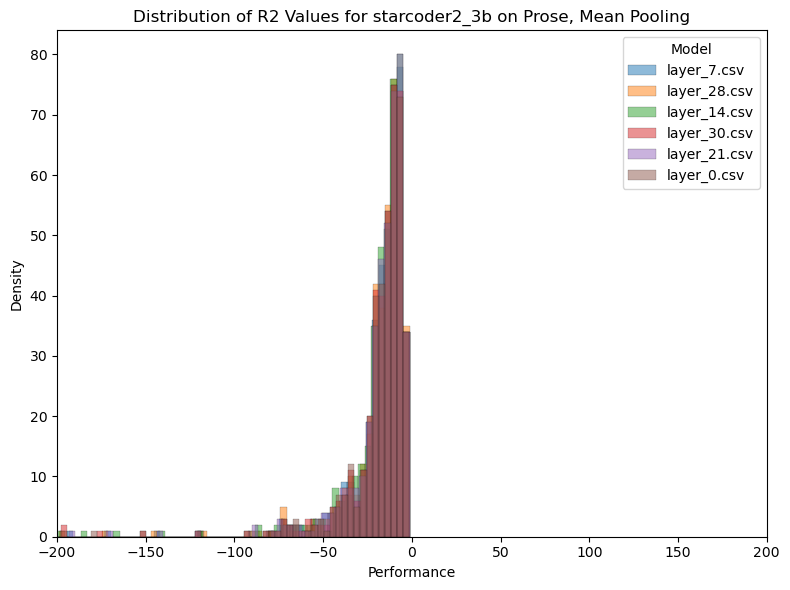

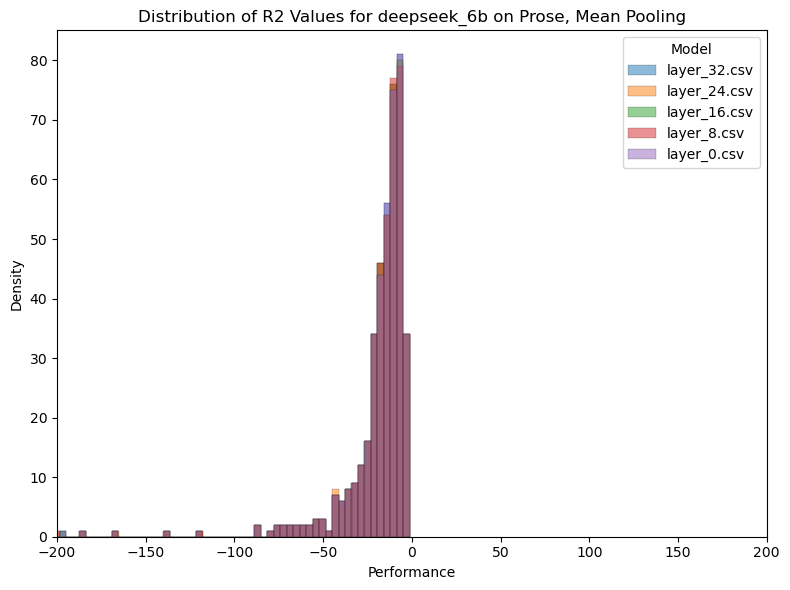

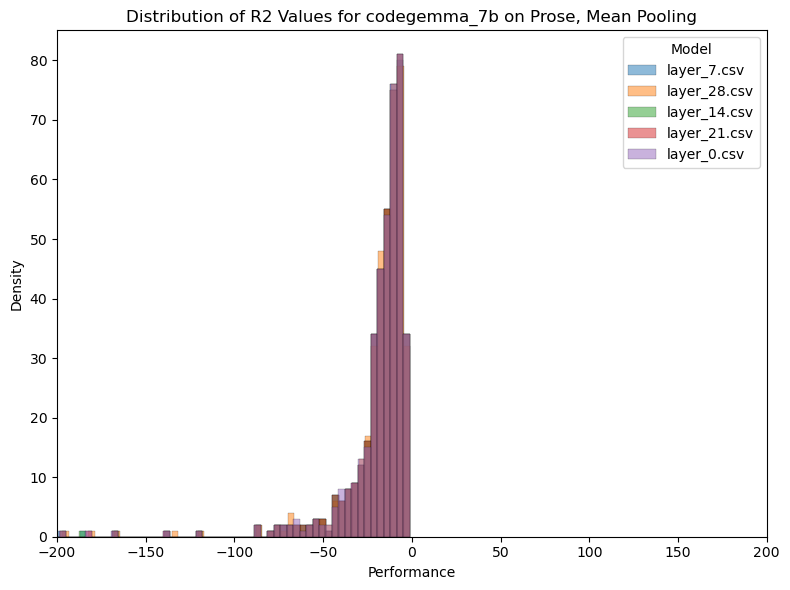

In [53]:
performance_by_roi(results_dict_mean_pooling_prose, 'Mean Pooling', 'Prose')

performance_by_expertise(results_dict_mean_pooling_prose, 'Mean Pooling', 'Prose')

performance_by_layer(results_dict_mean_pooling_prose, 'Mean Pooling', 'Prose')

# CLS Token Code

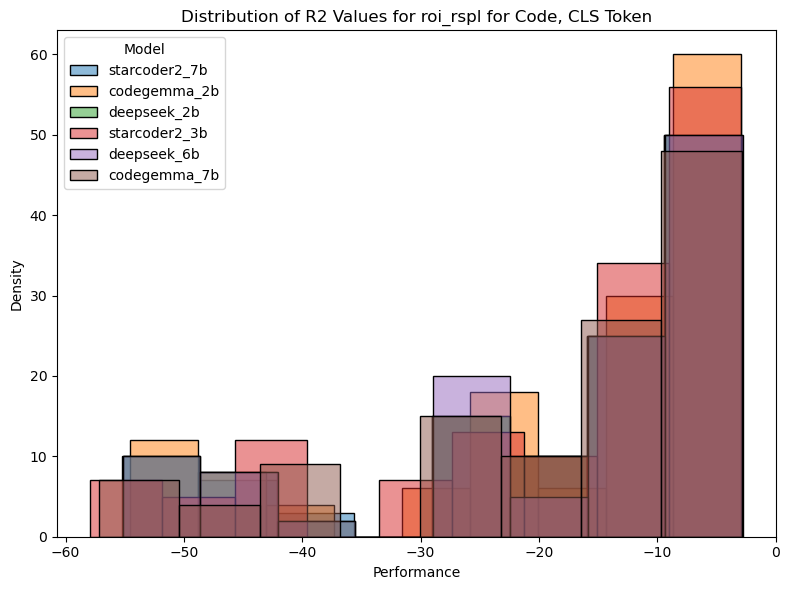

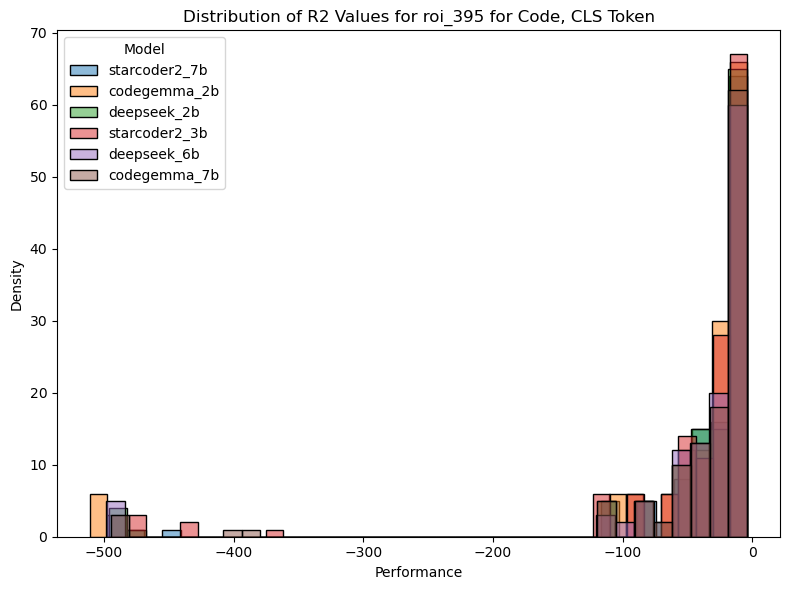

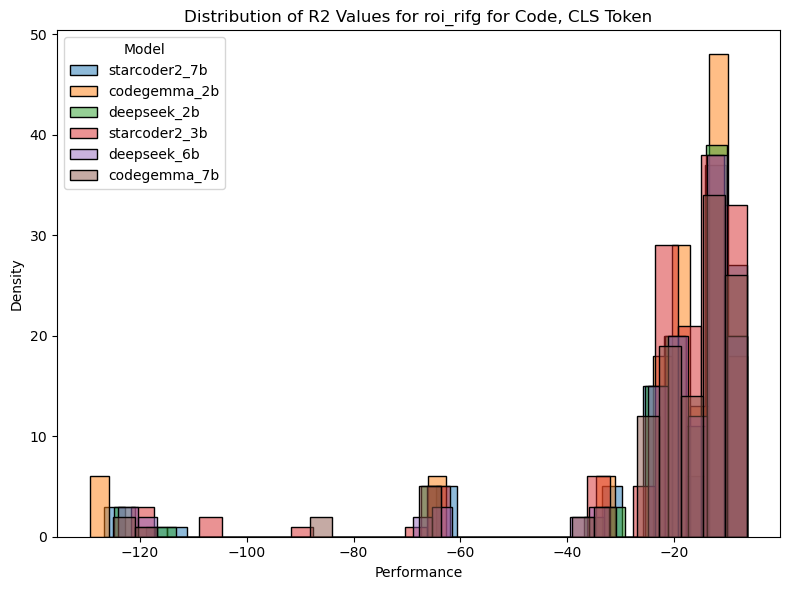

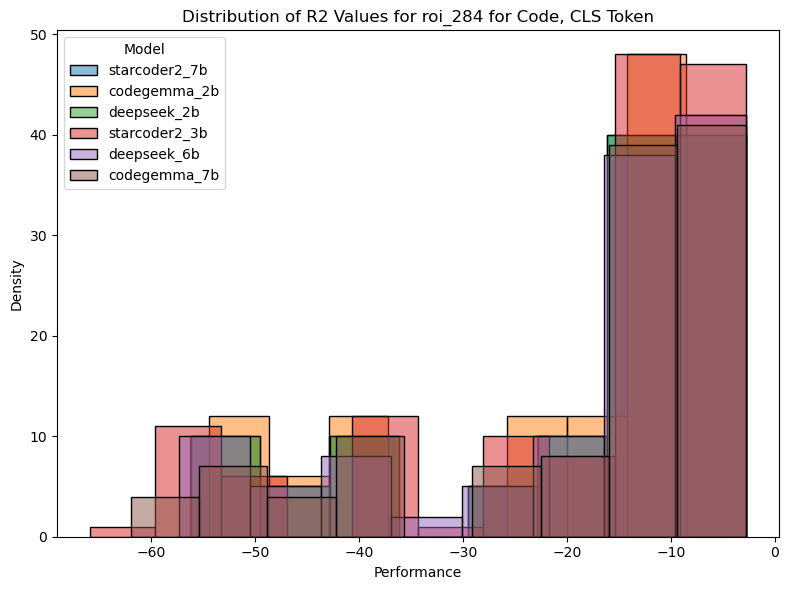

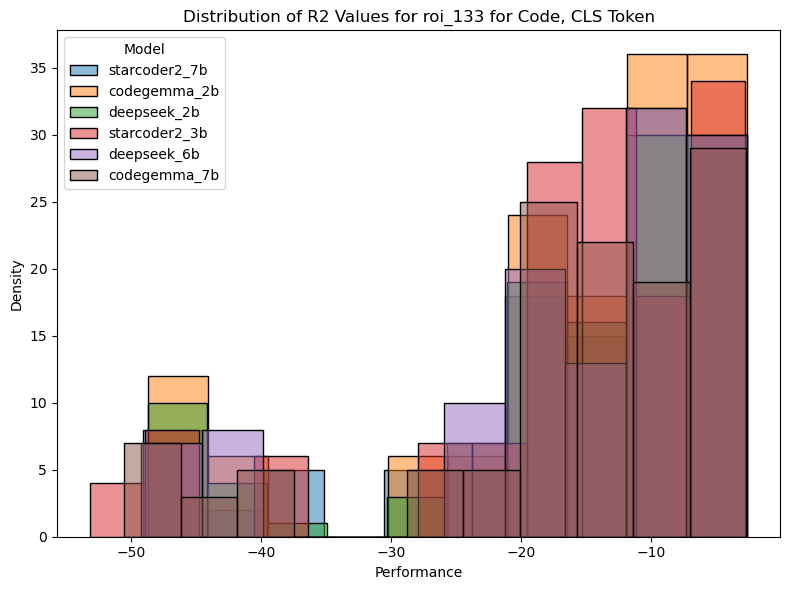

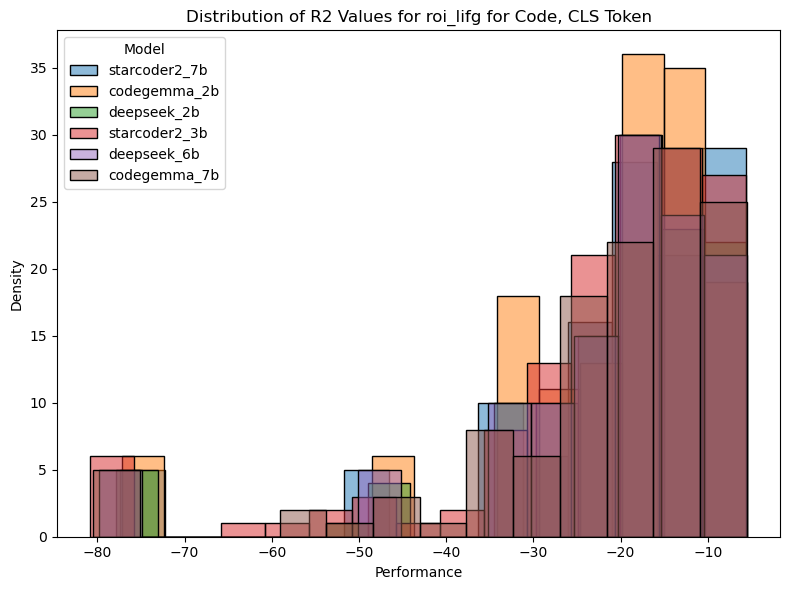

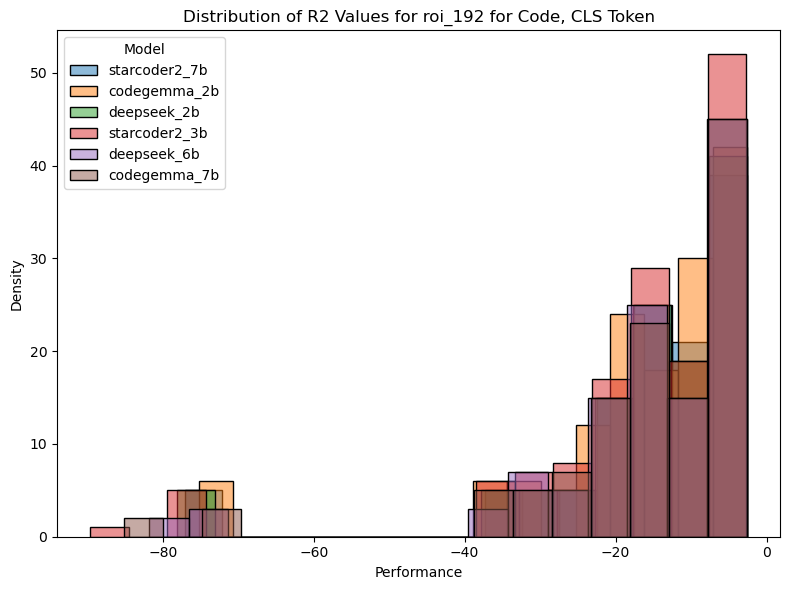

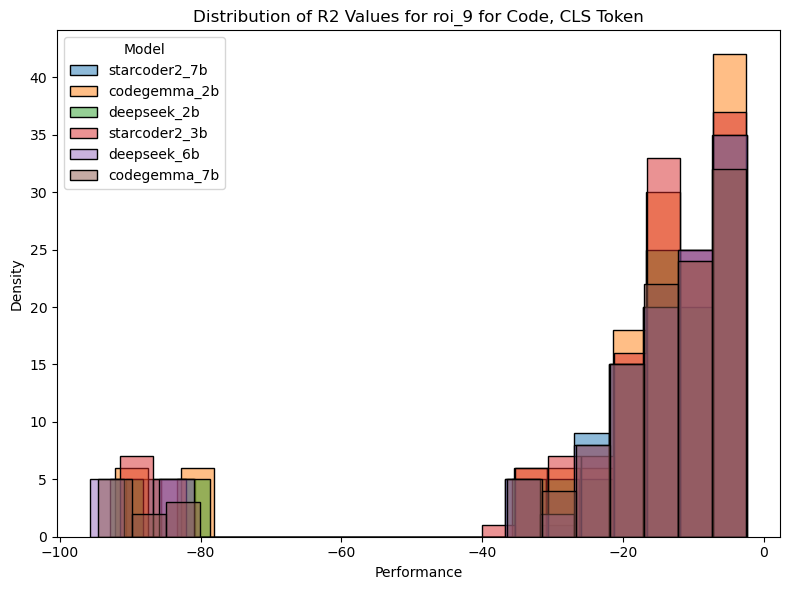

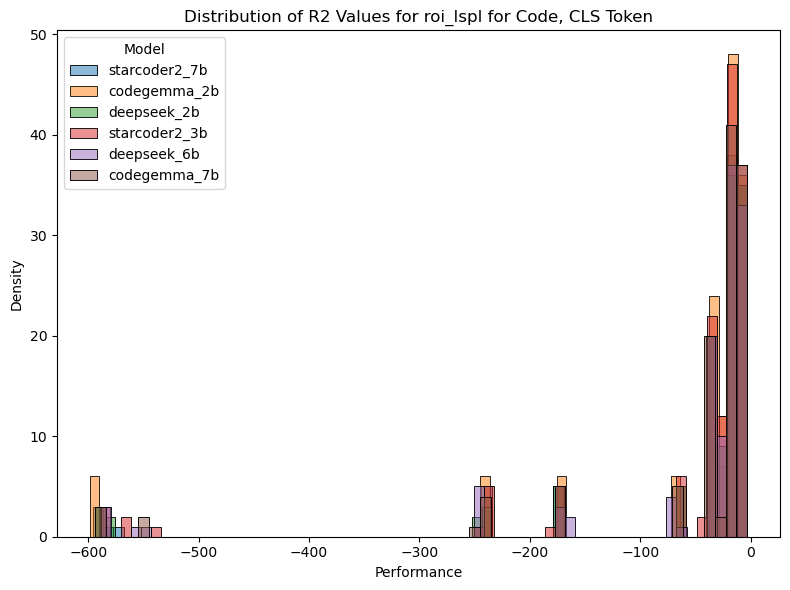

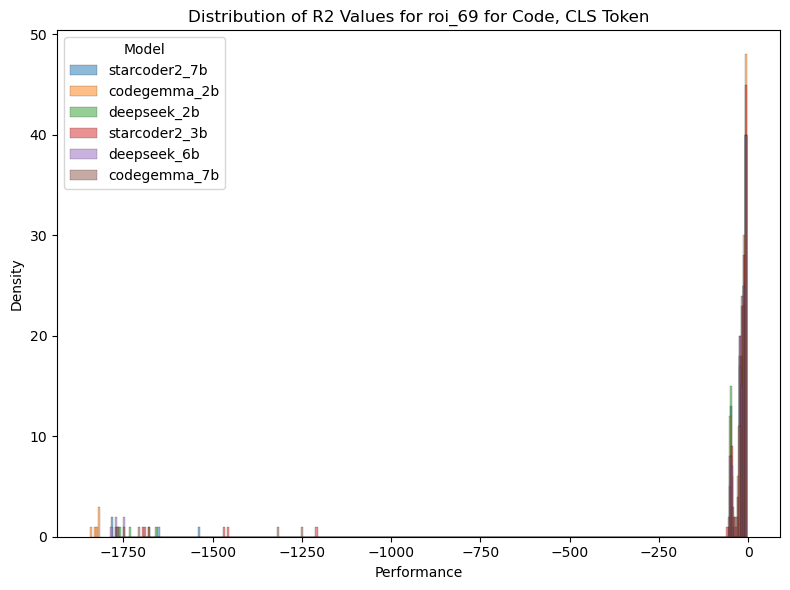

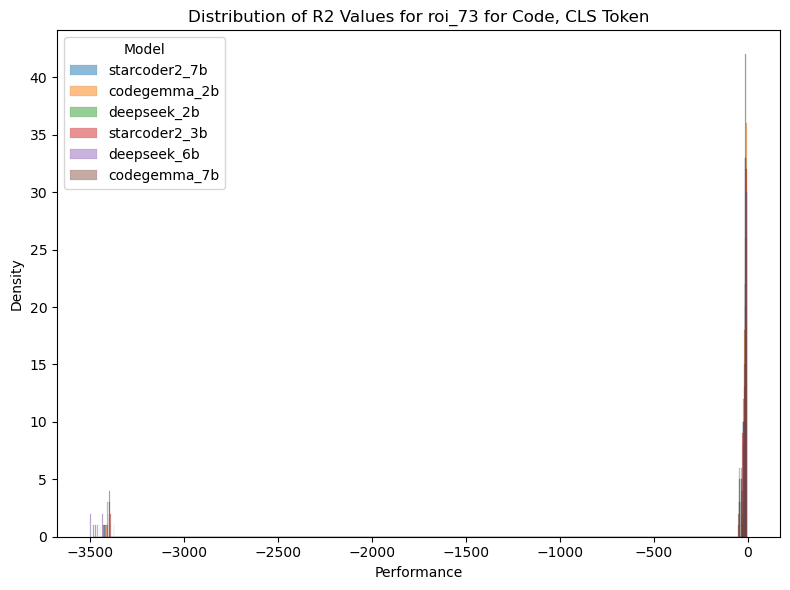

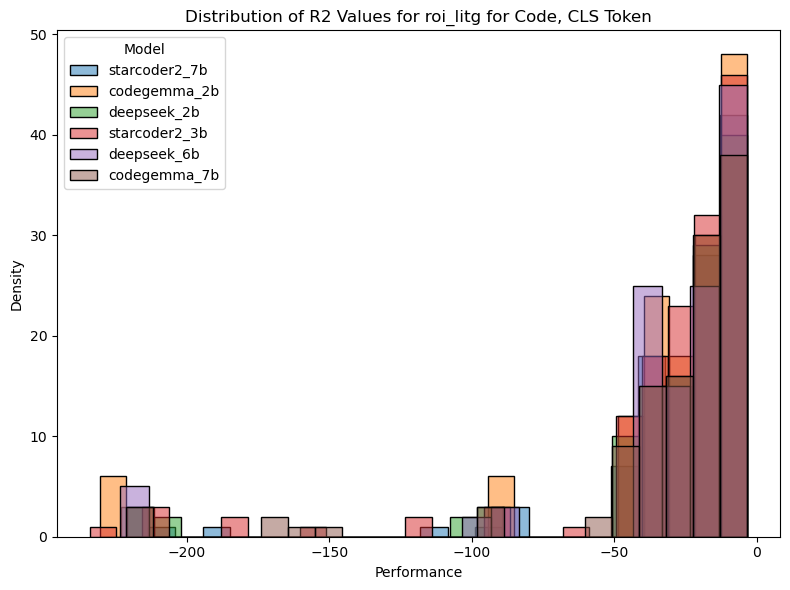

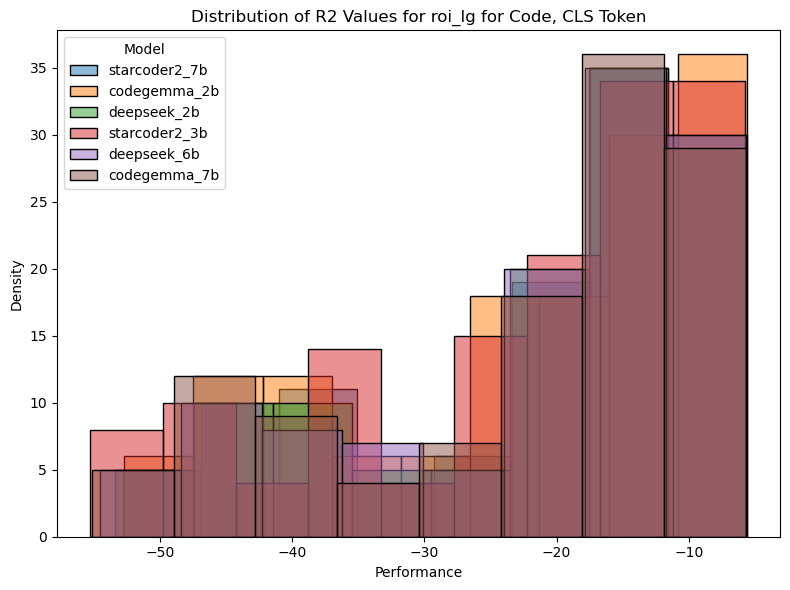

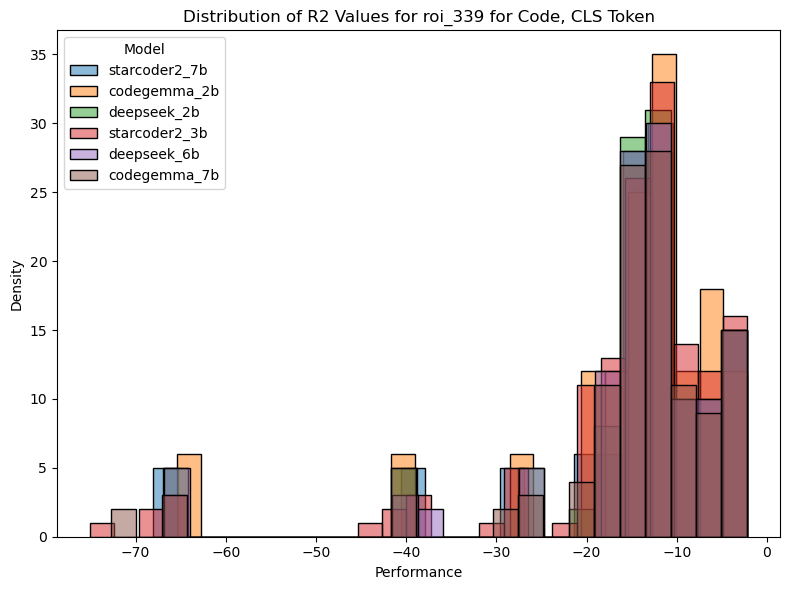

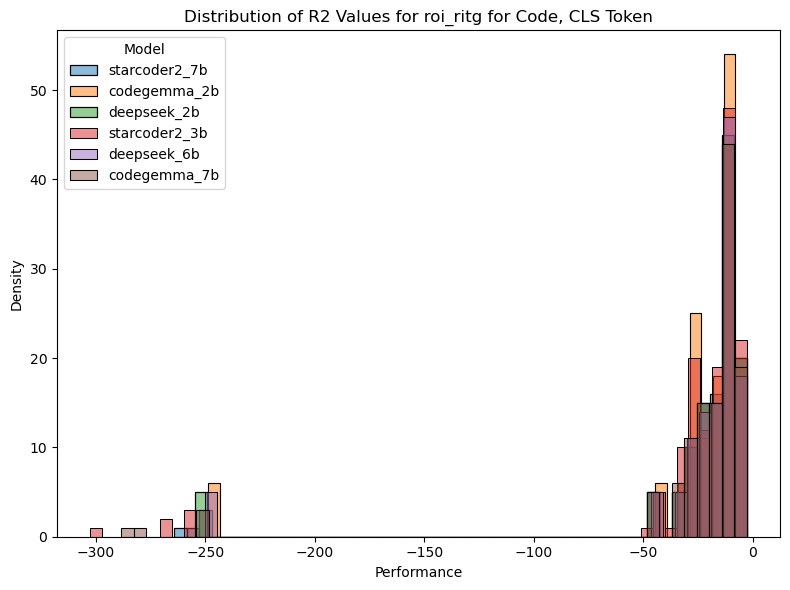

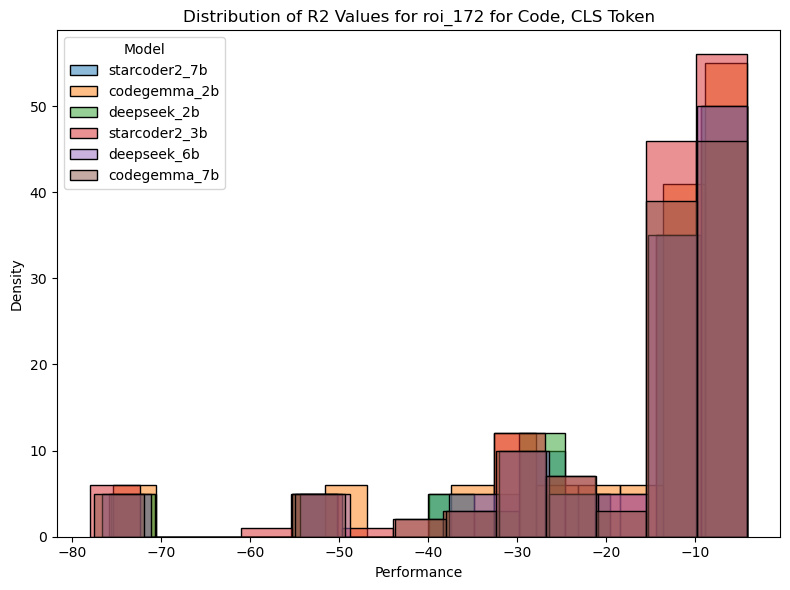

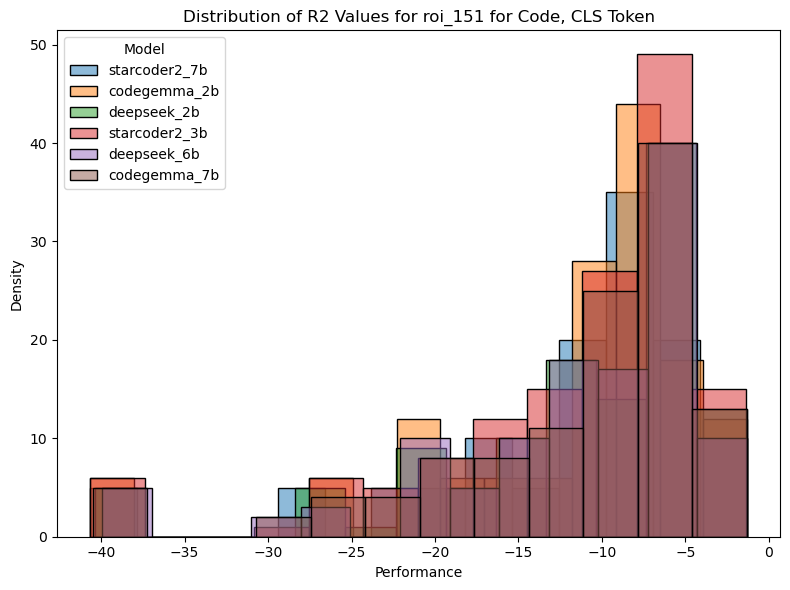

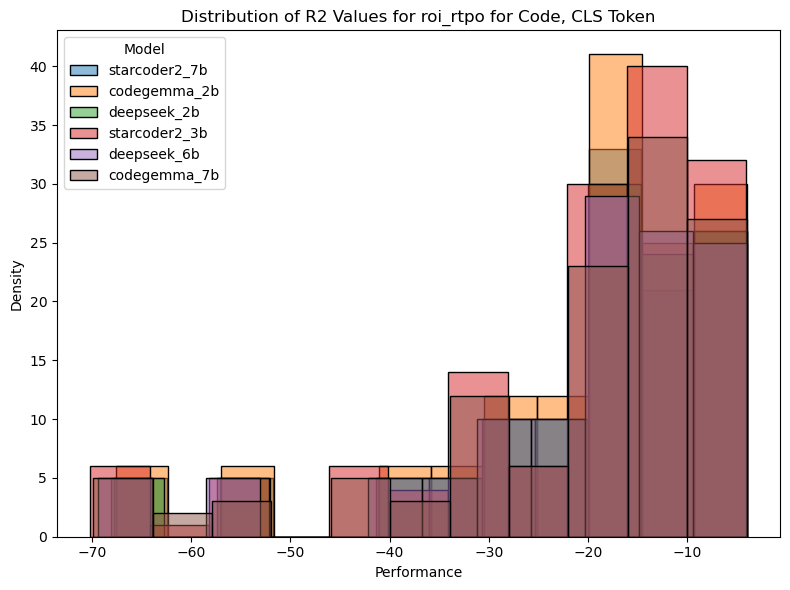

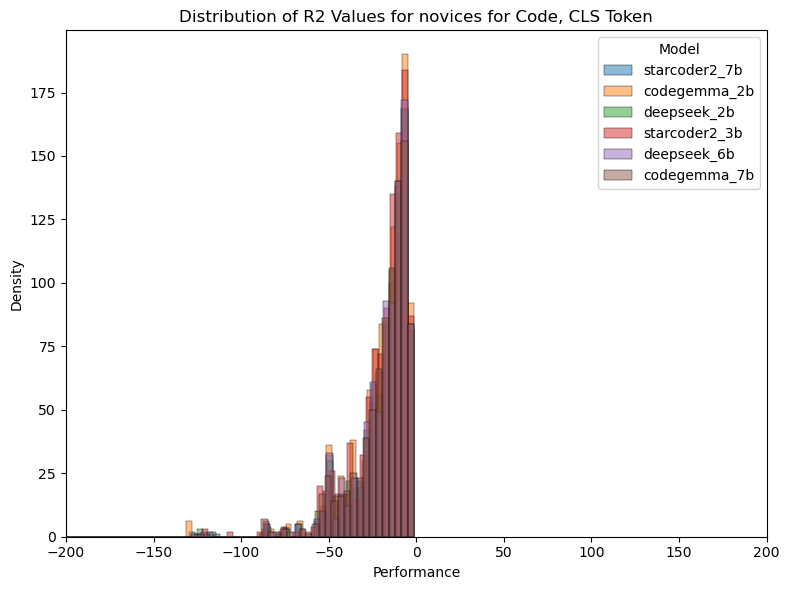

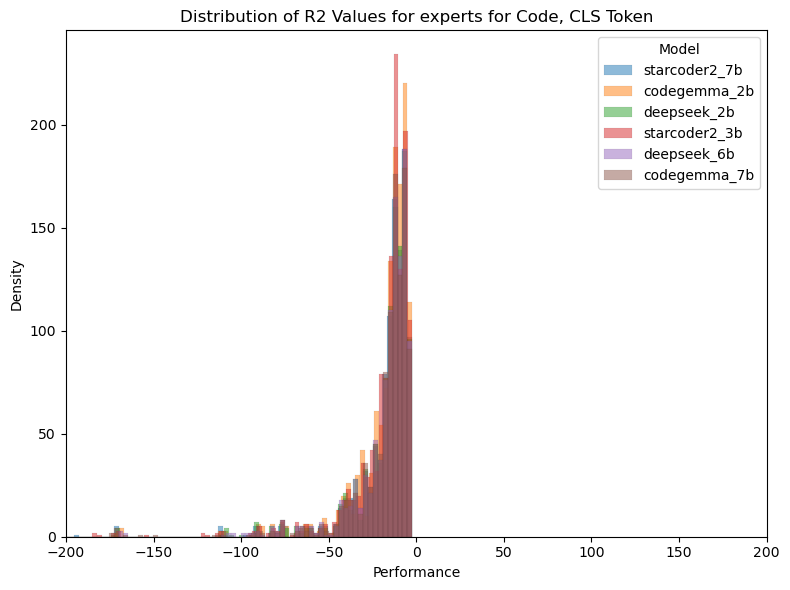

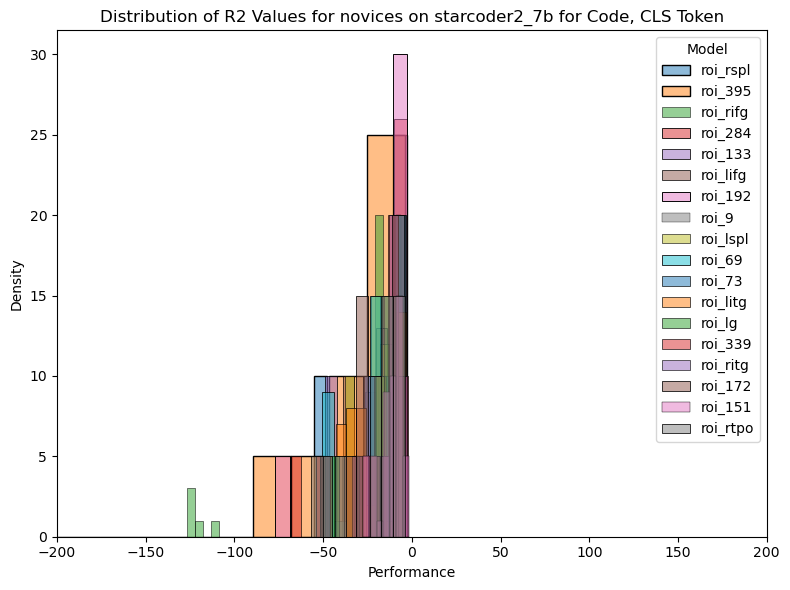

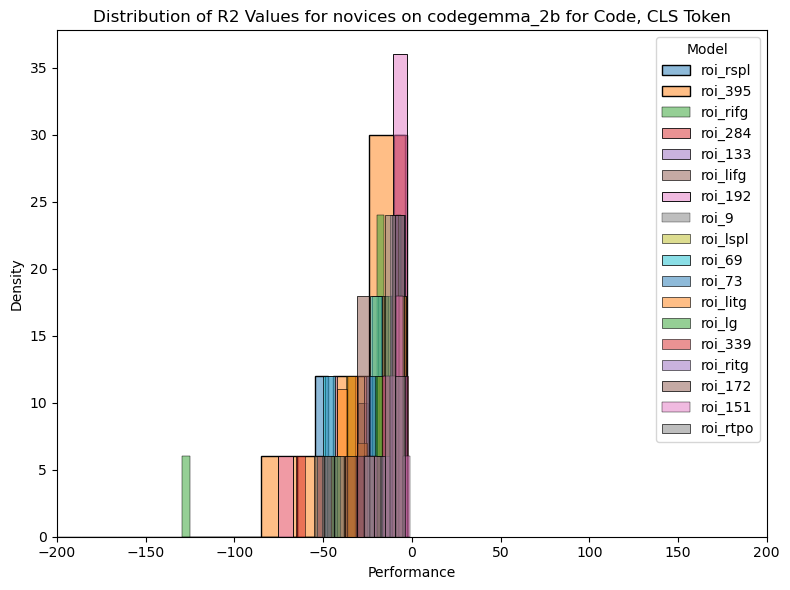

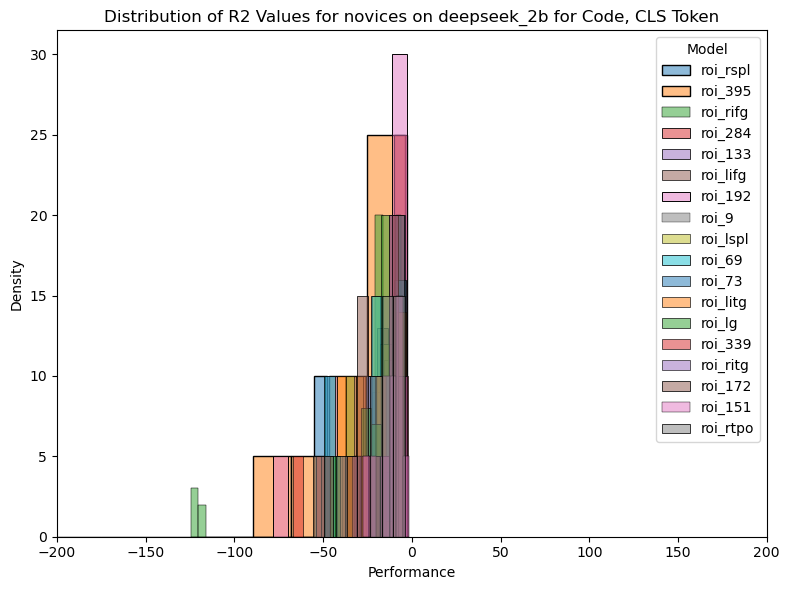

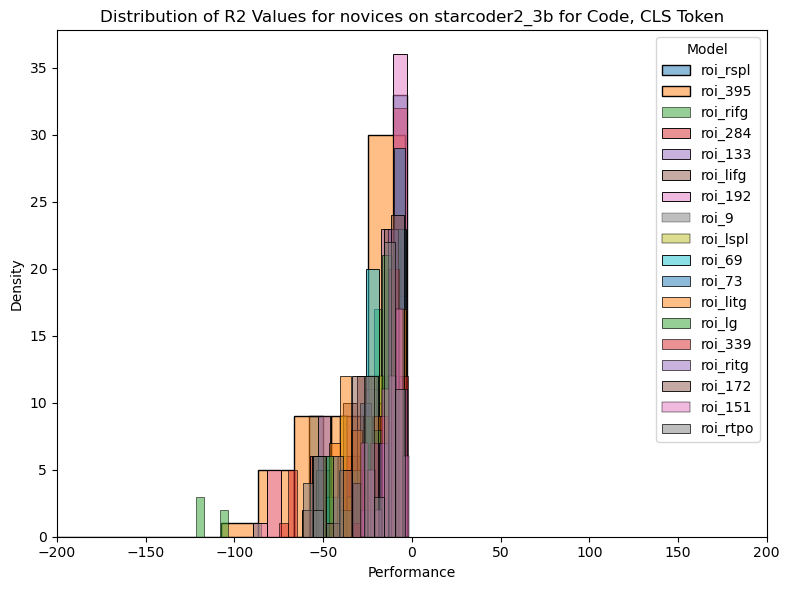

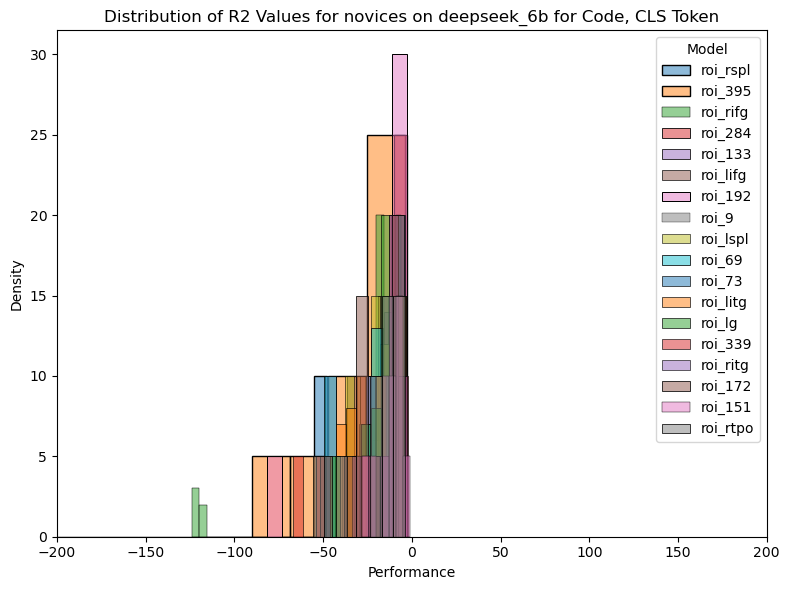

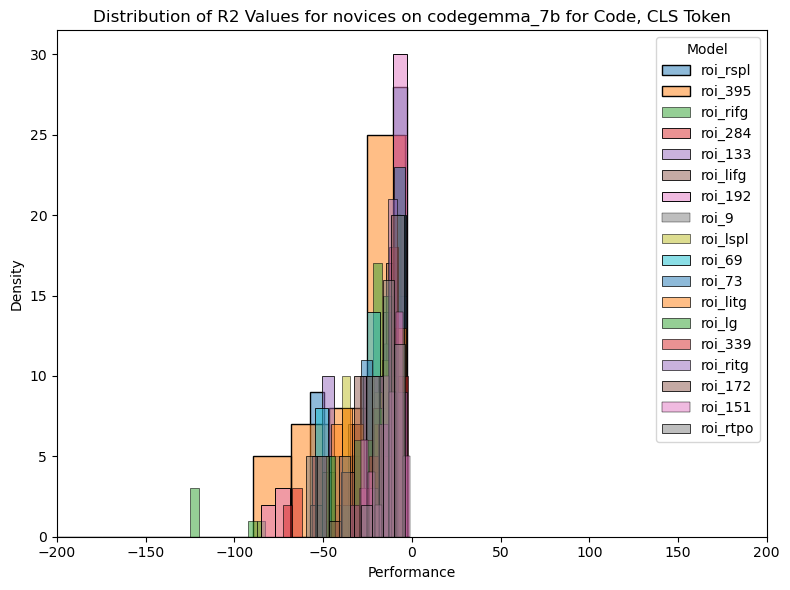

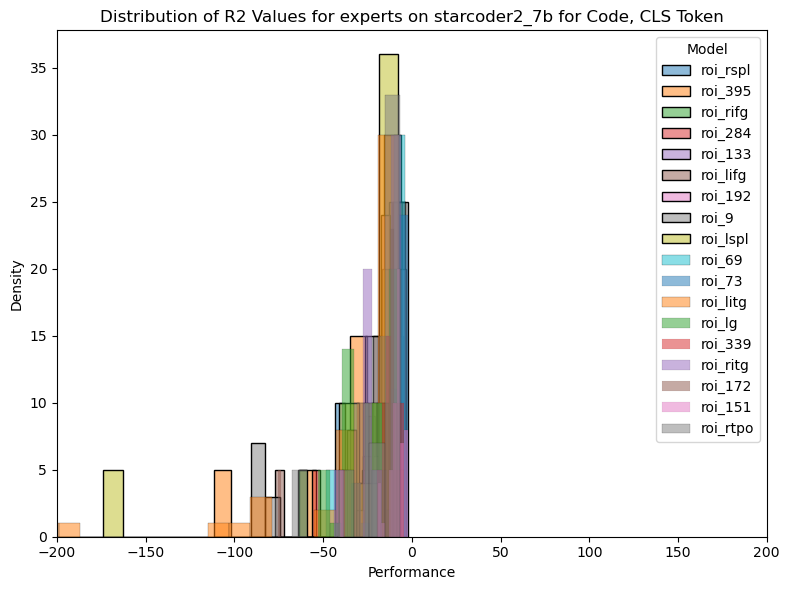

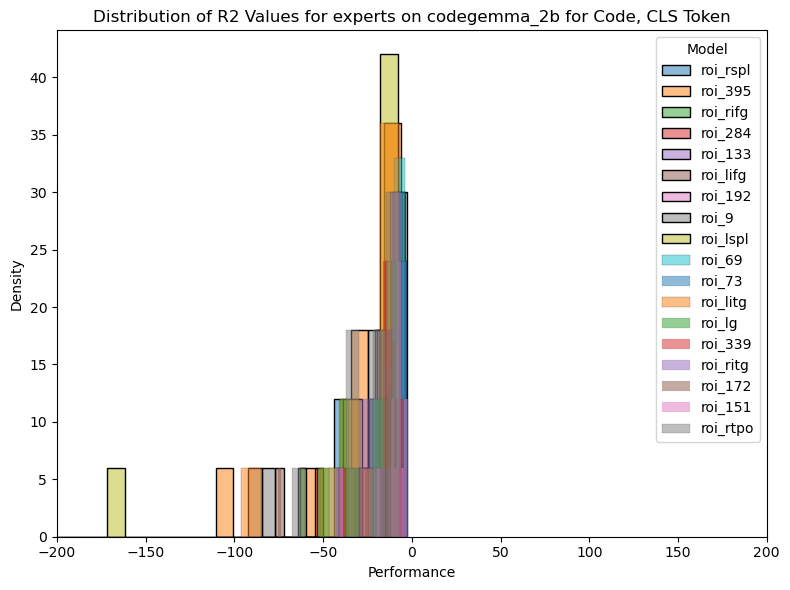

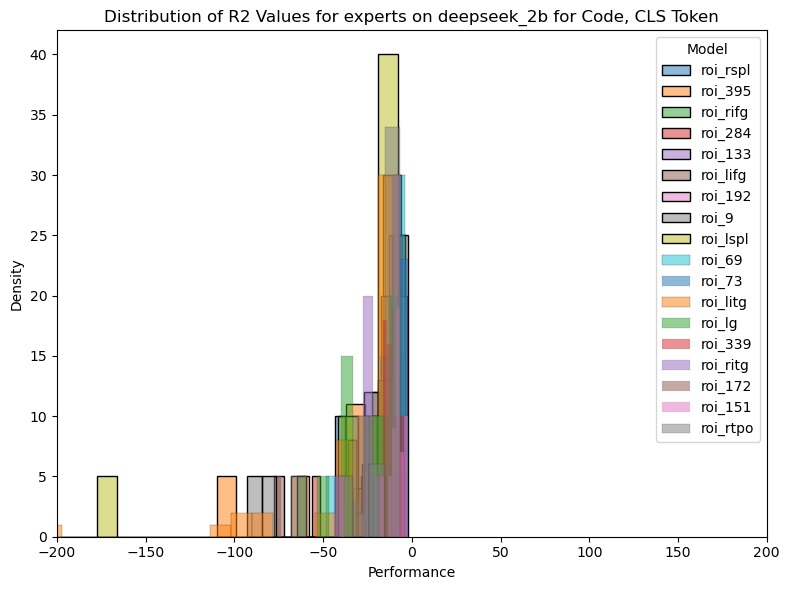

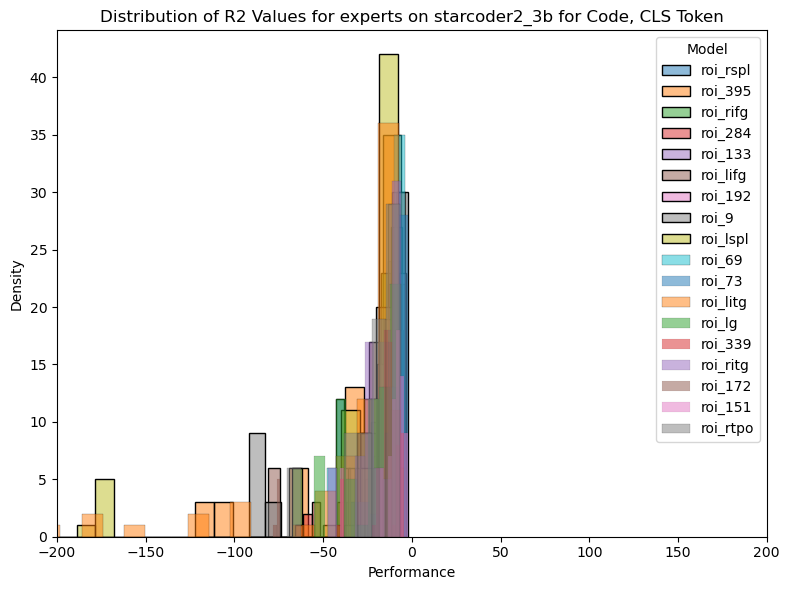

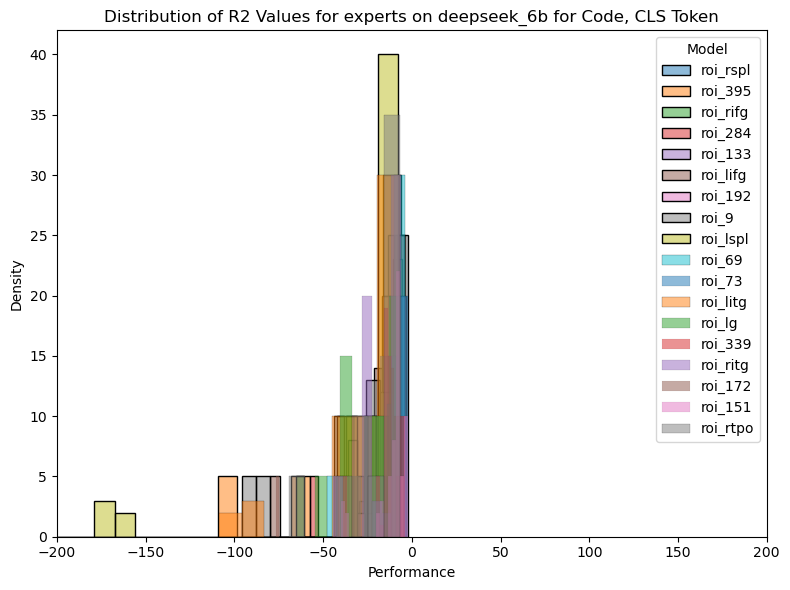

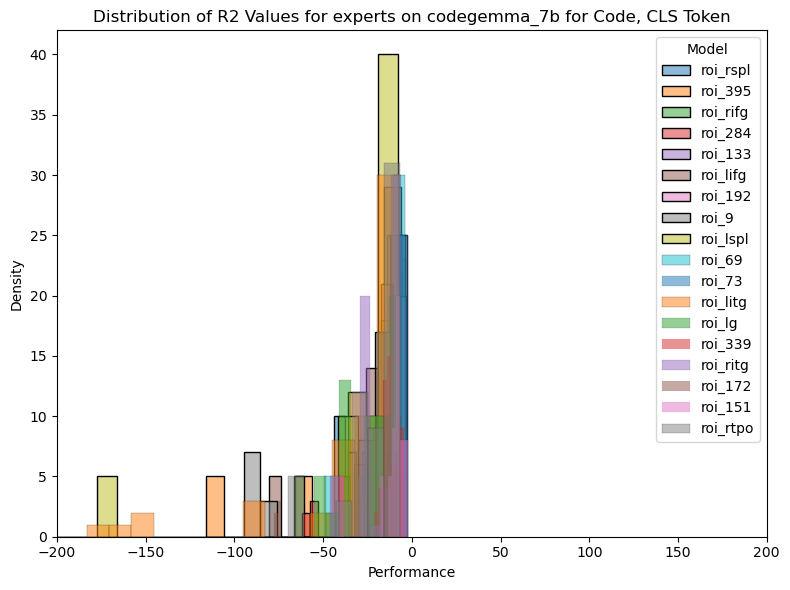

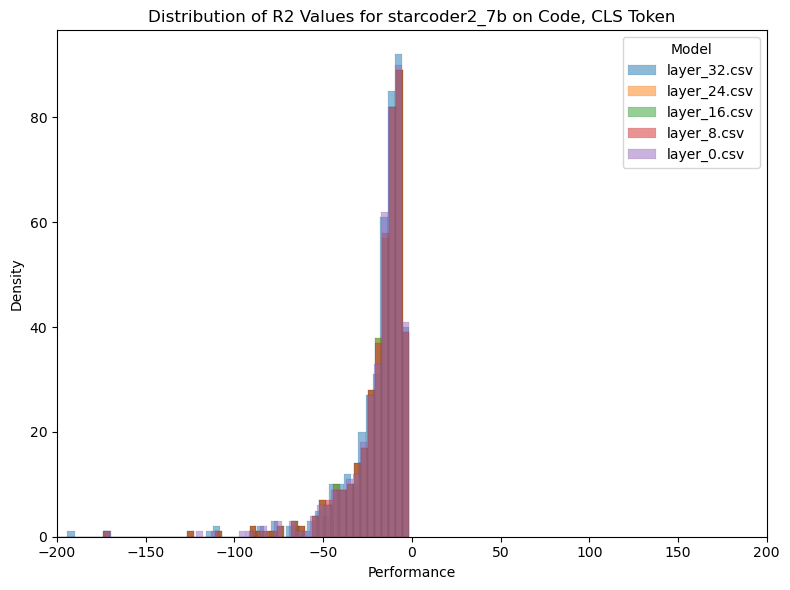

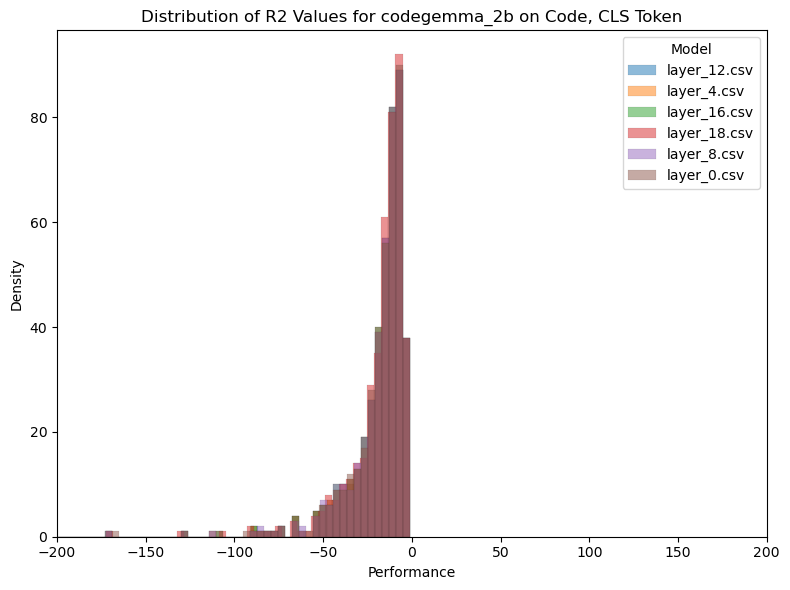

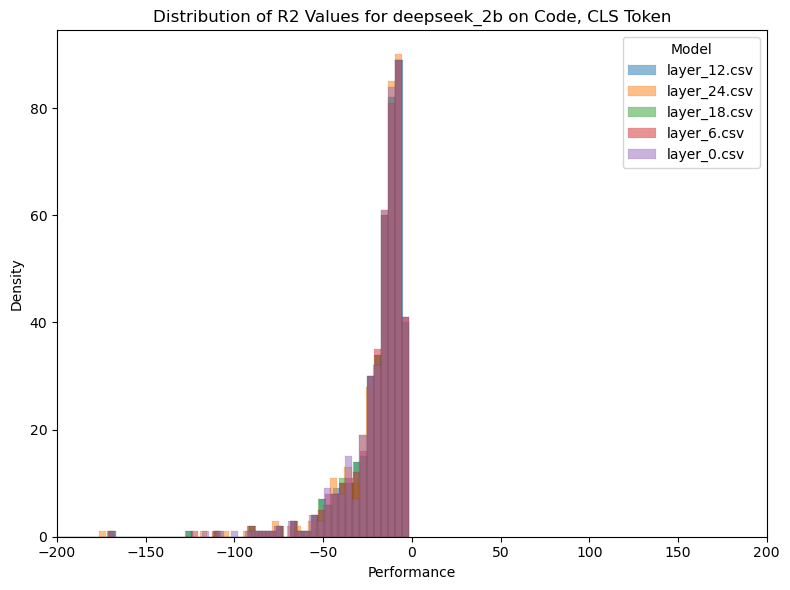

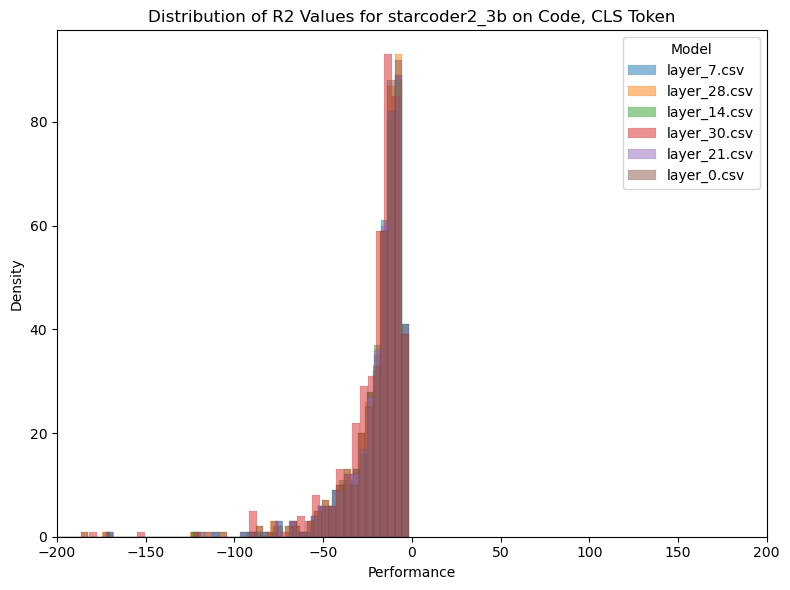

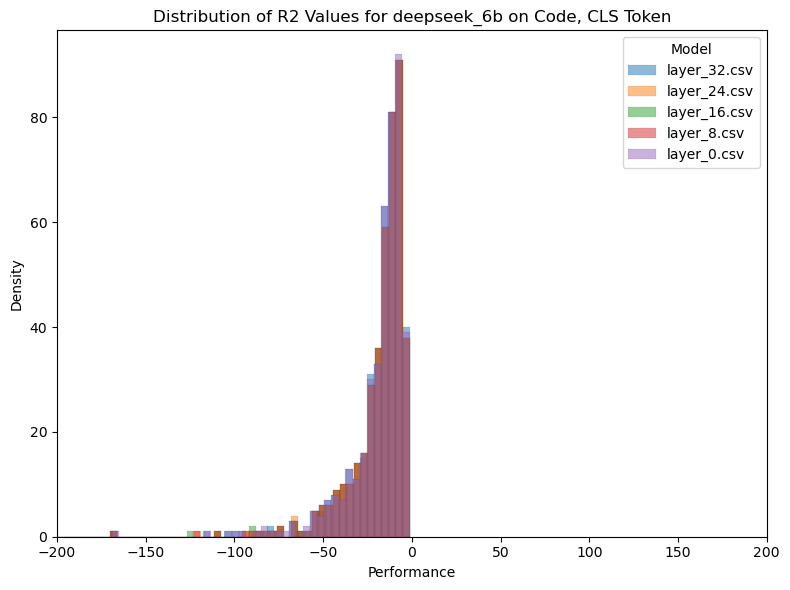

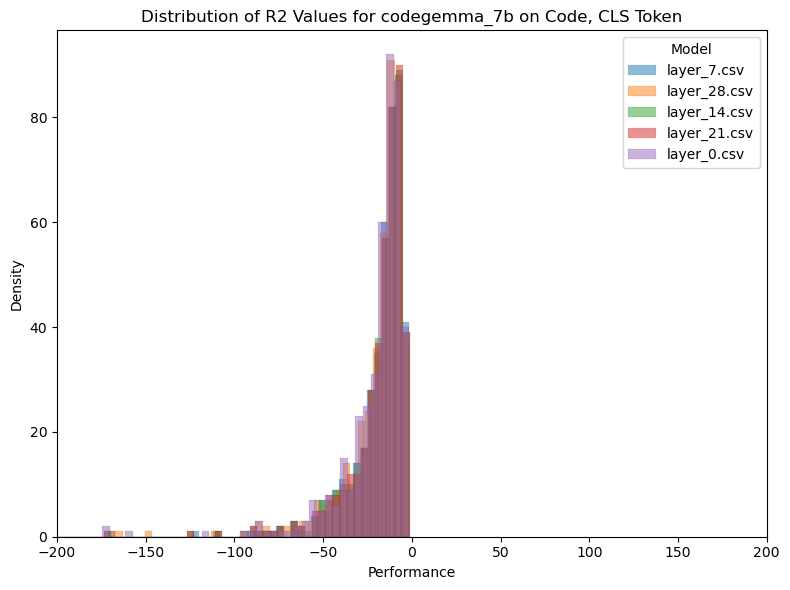

In [54]:
performance_by_roi(results_dict_cls_code, 'CLS Token', 'Code')

performance_by_expertise(results_dict_cls_code, 'CLS Token', 'Code')

performance_by_layer(results_dict_cls_code, 'CLS Token', 'Code')

# CLS Token Prose

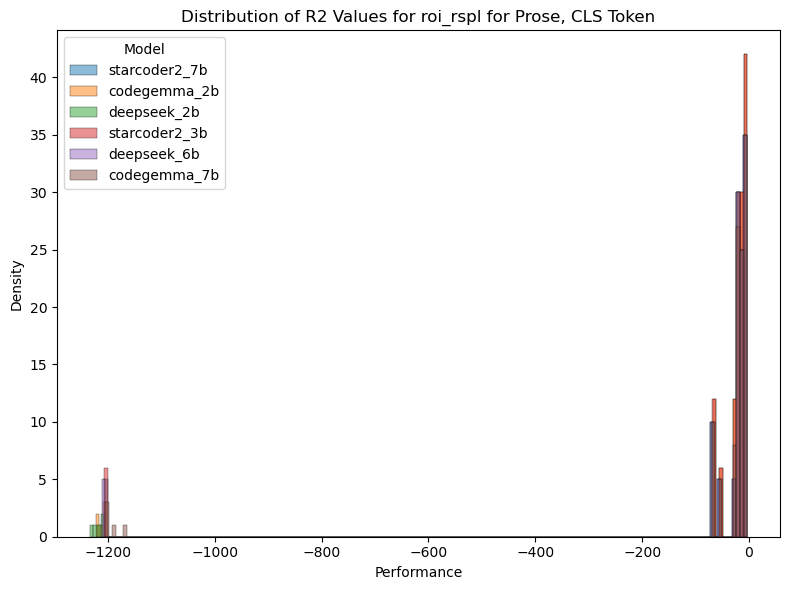

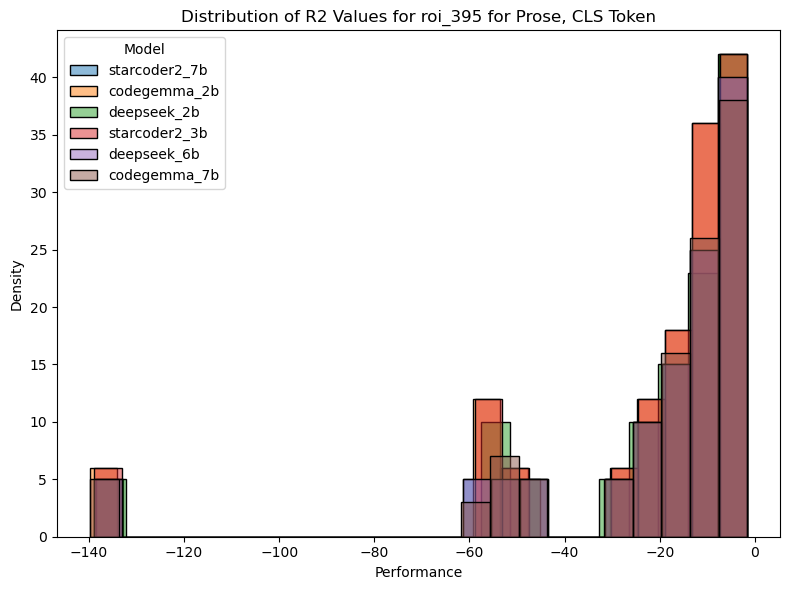

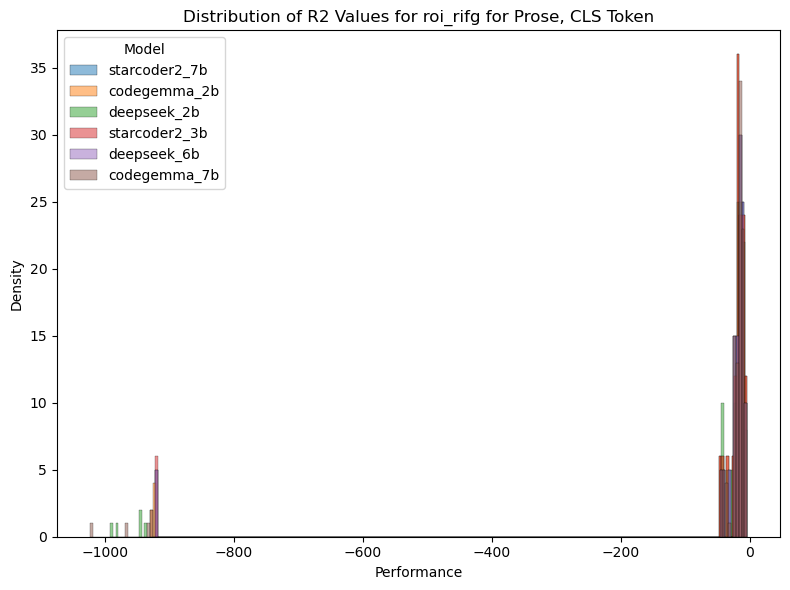

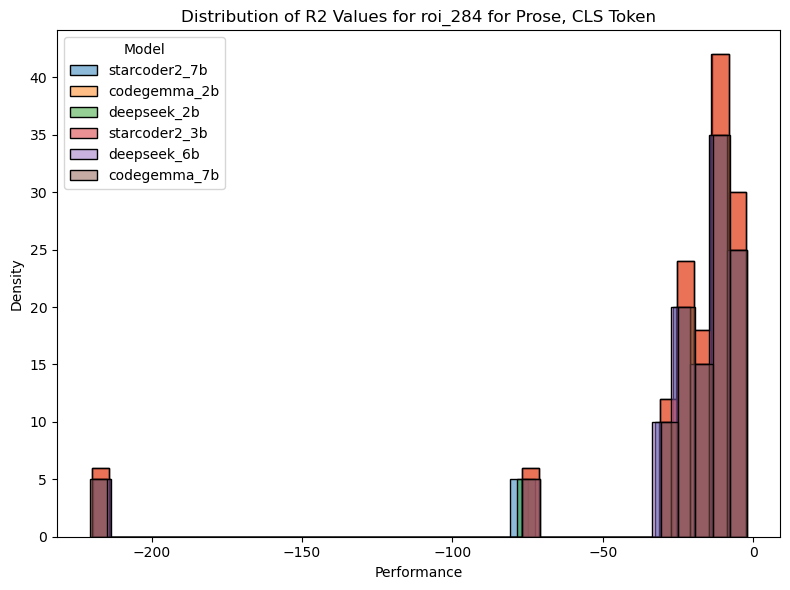

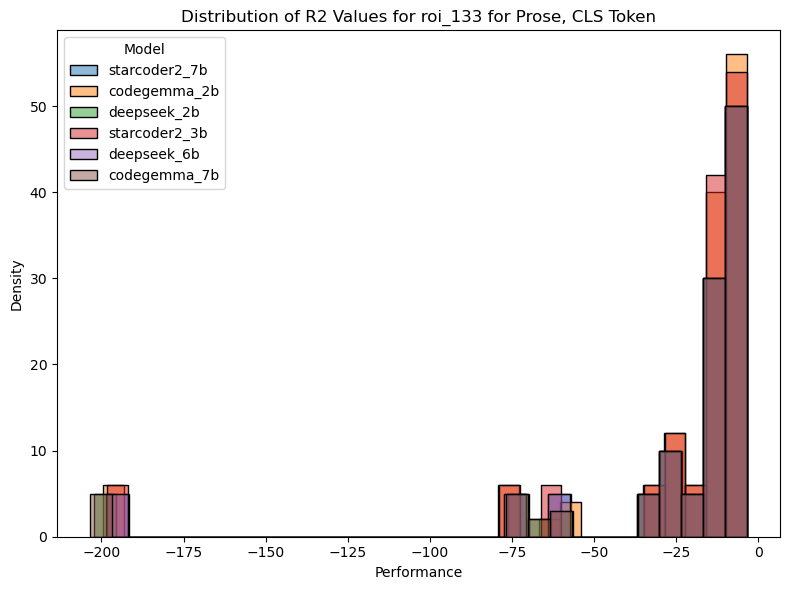

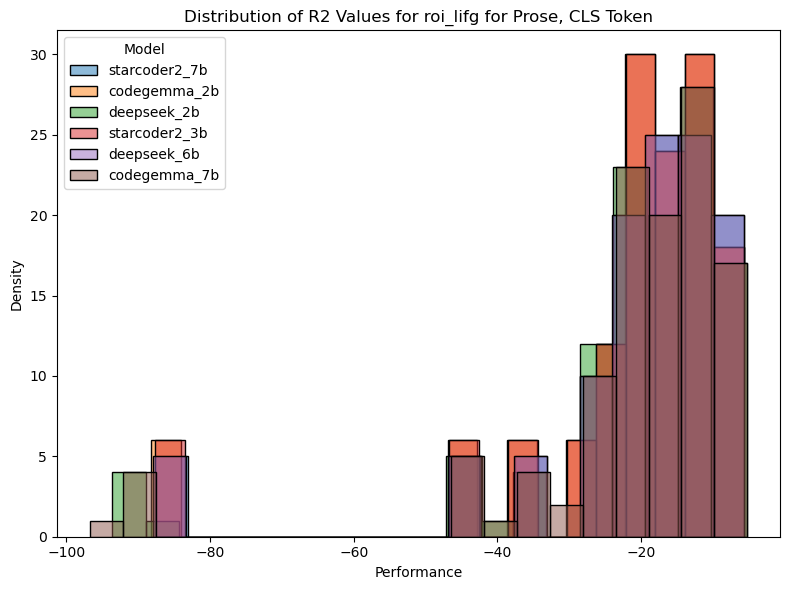

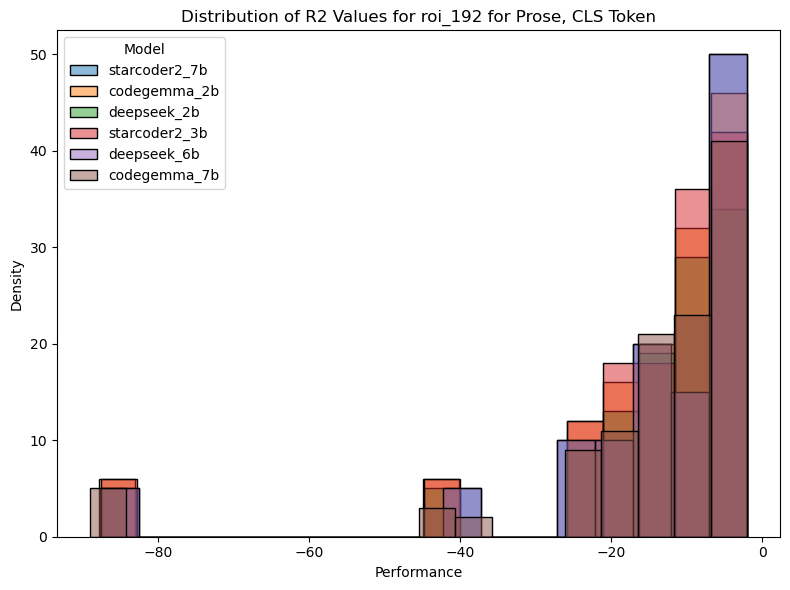

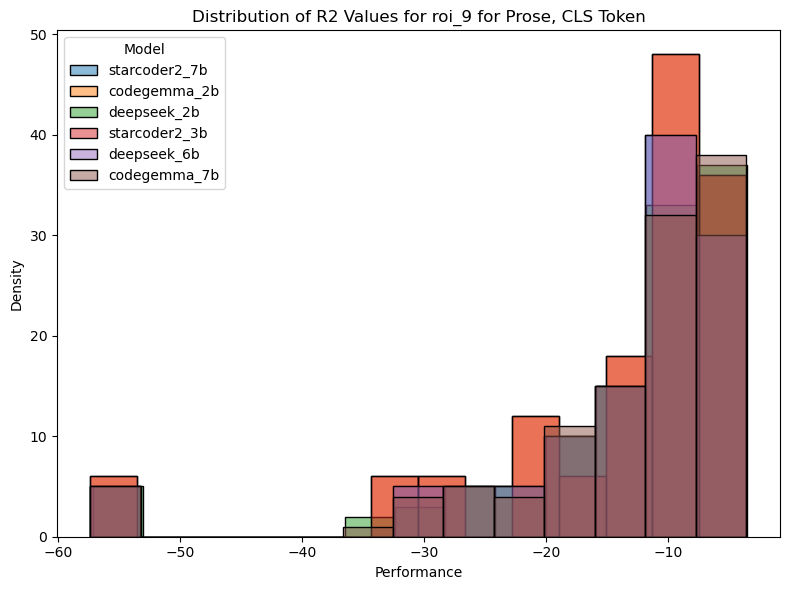

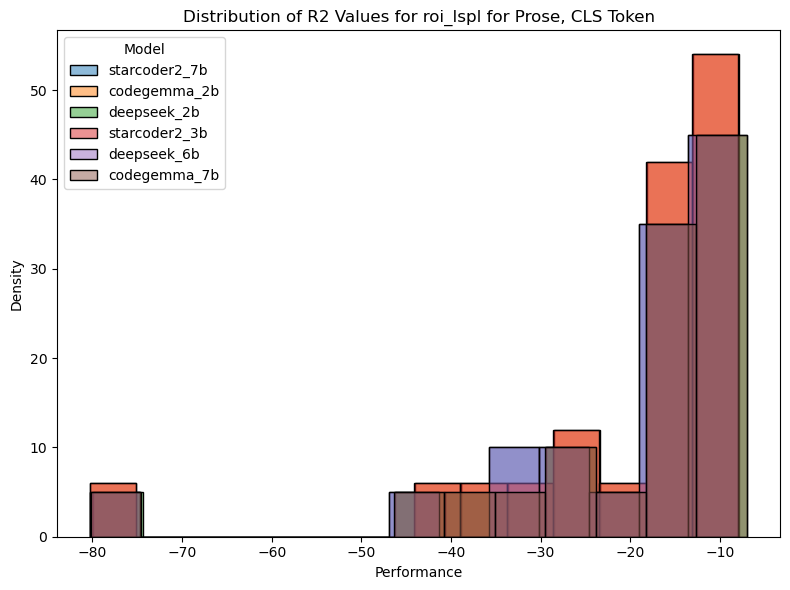

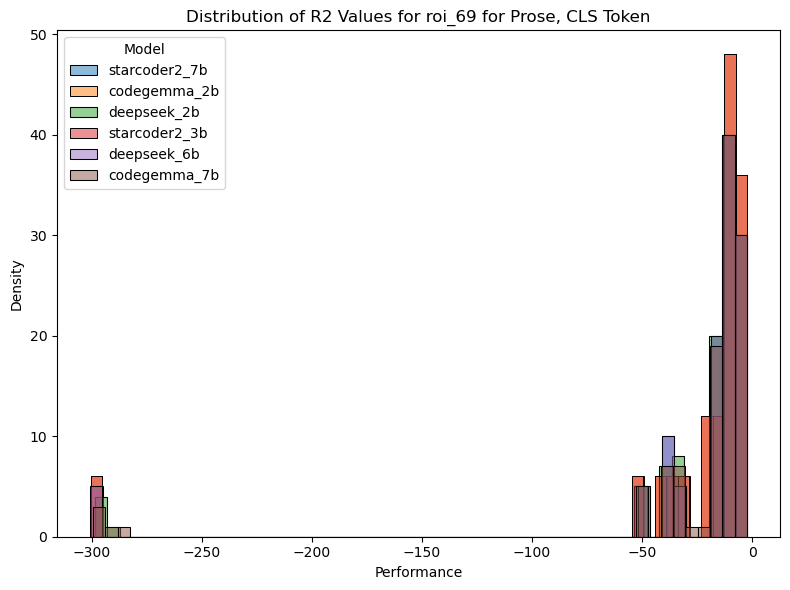

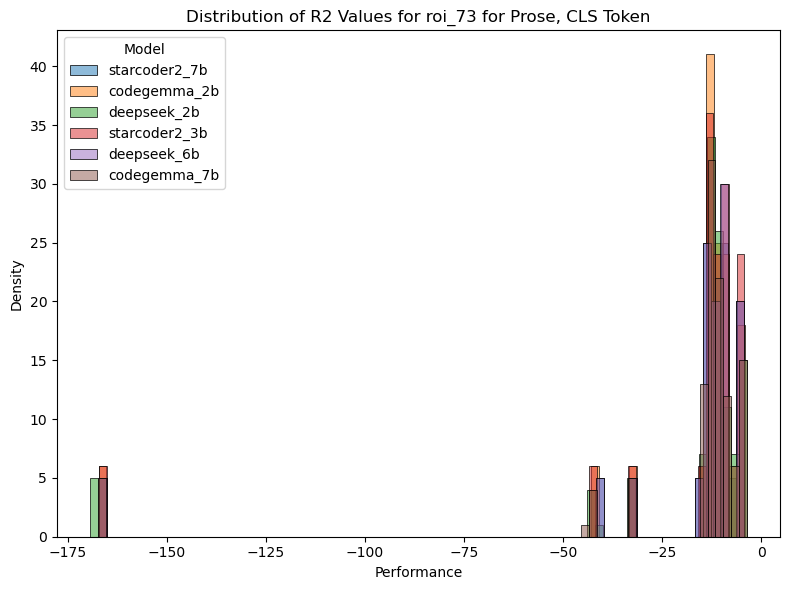

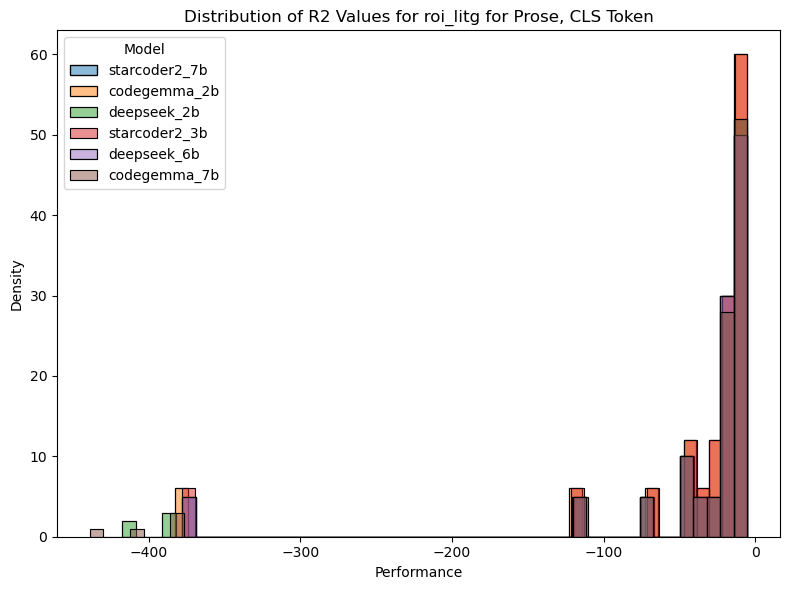

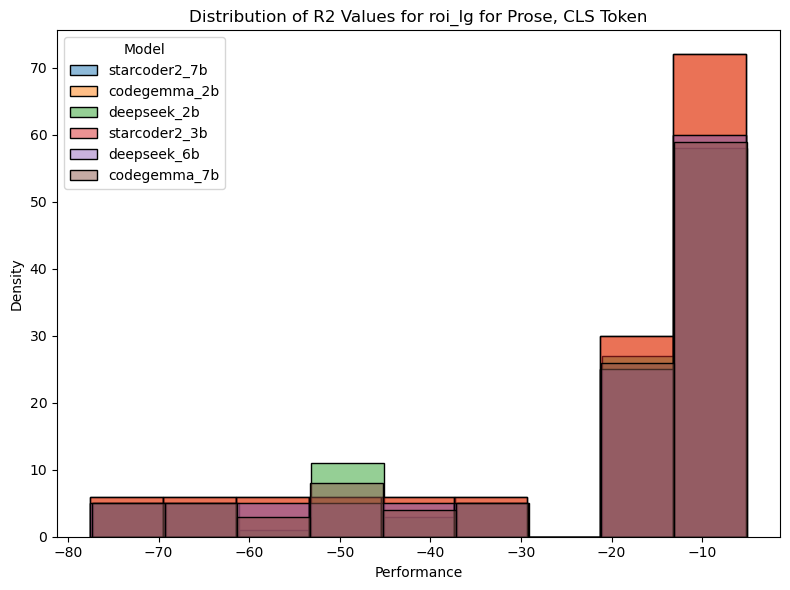

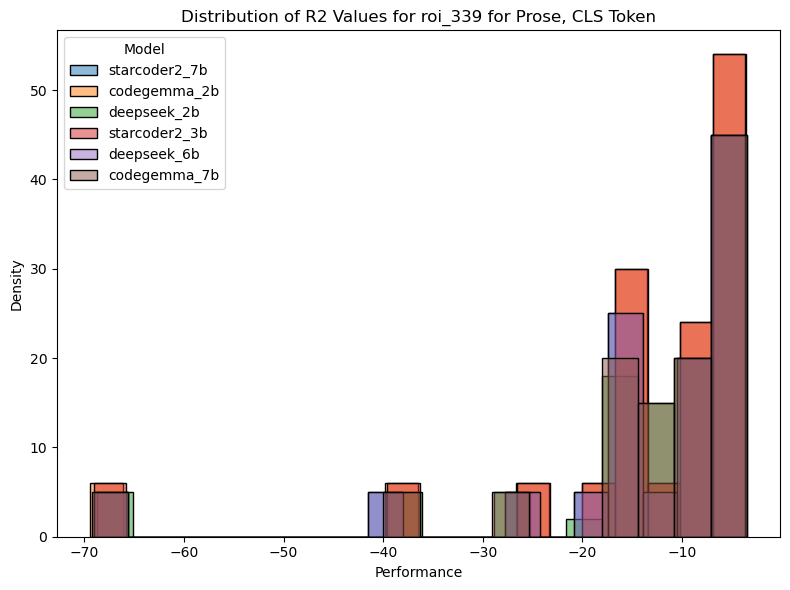

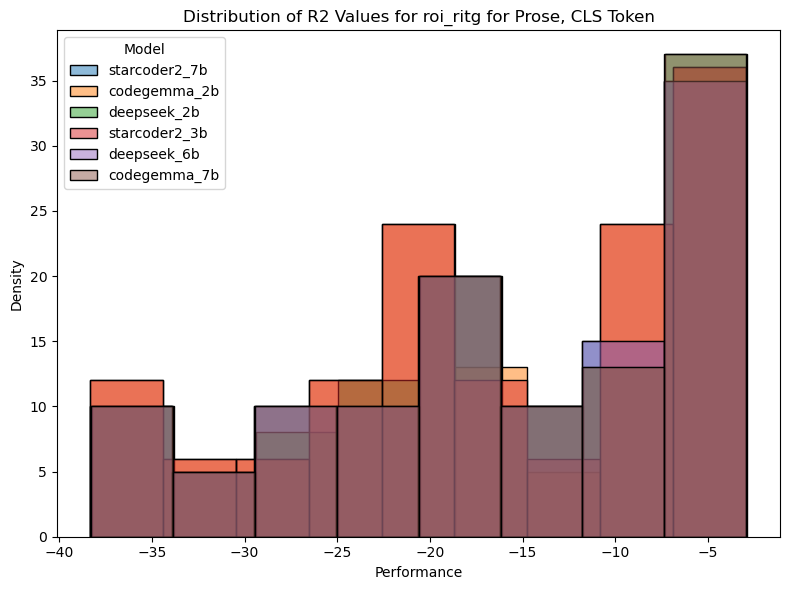

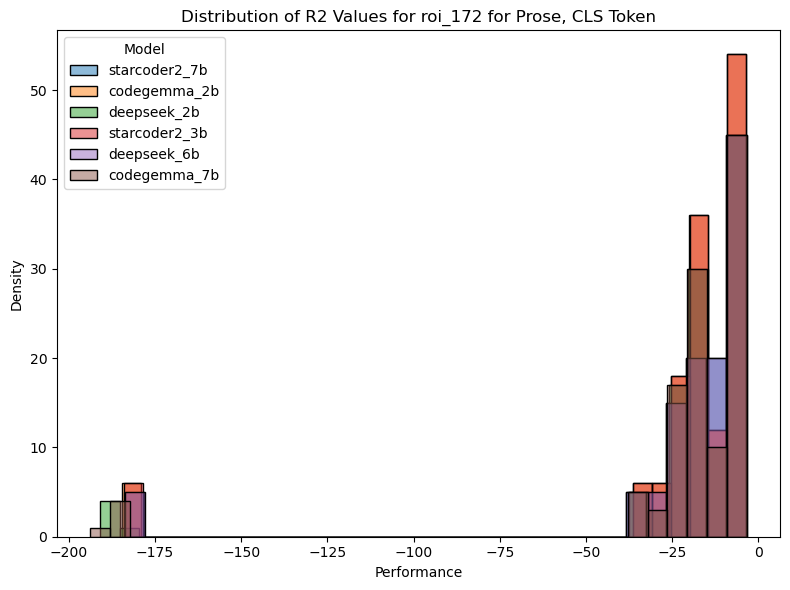

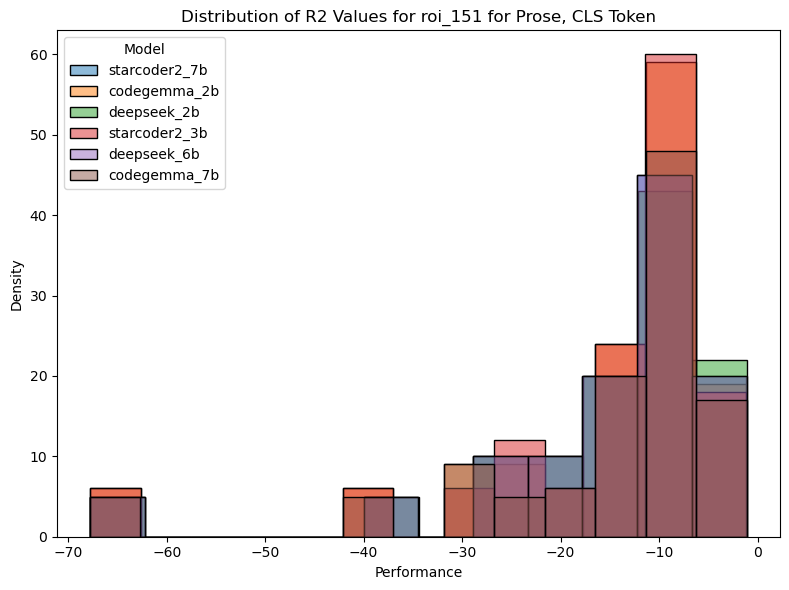

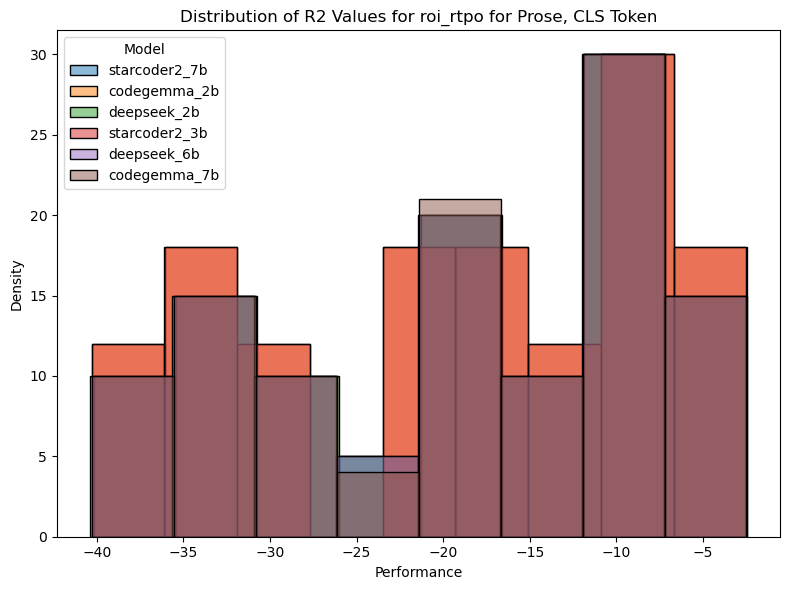

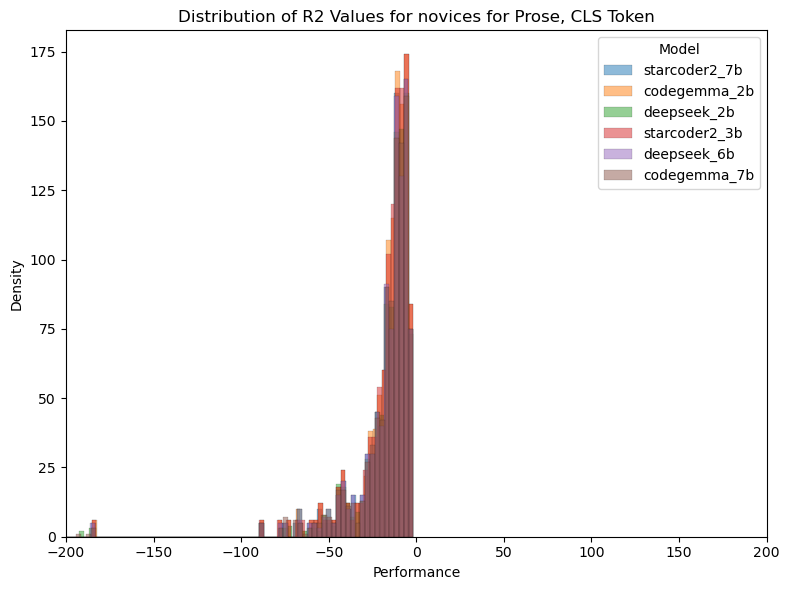

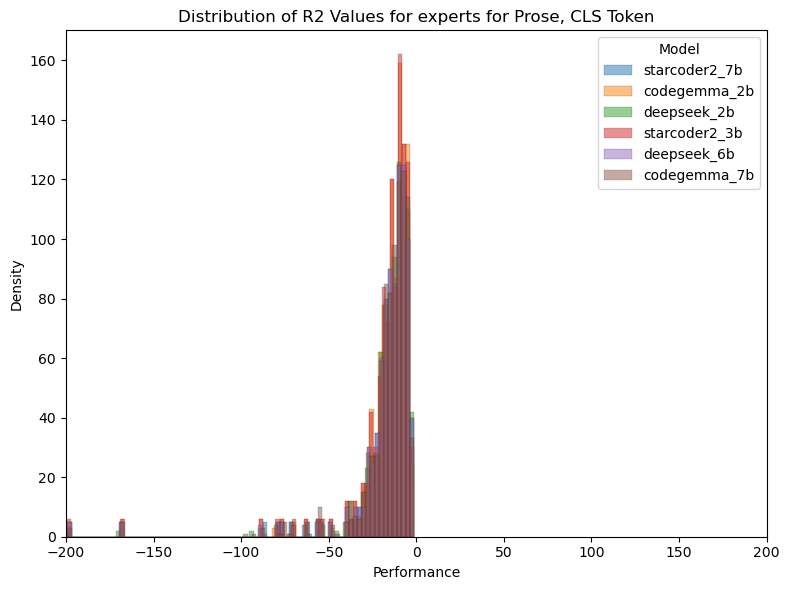

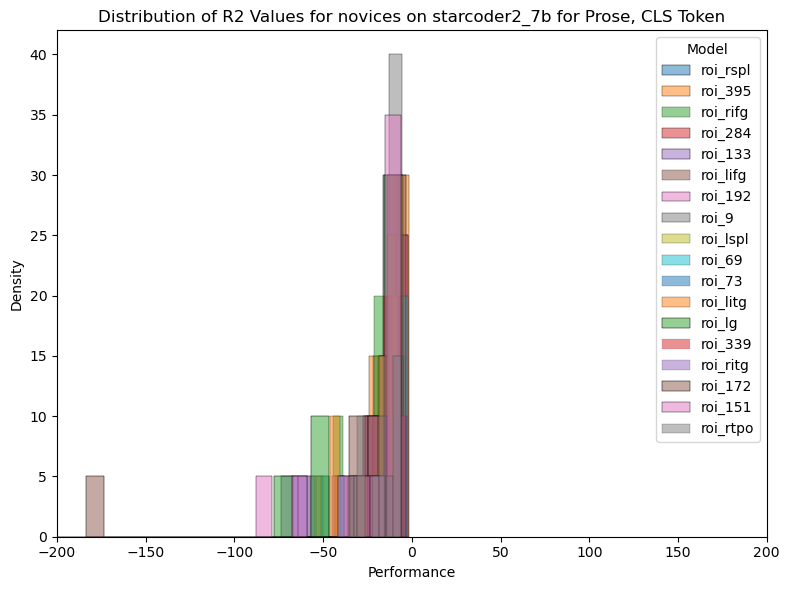

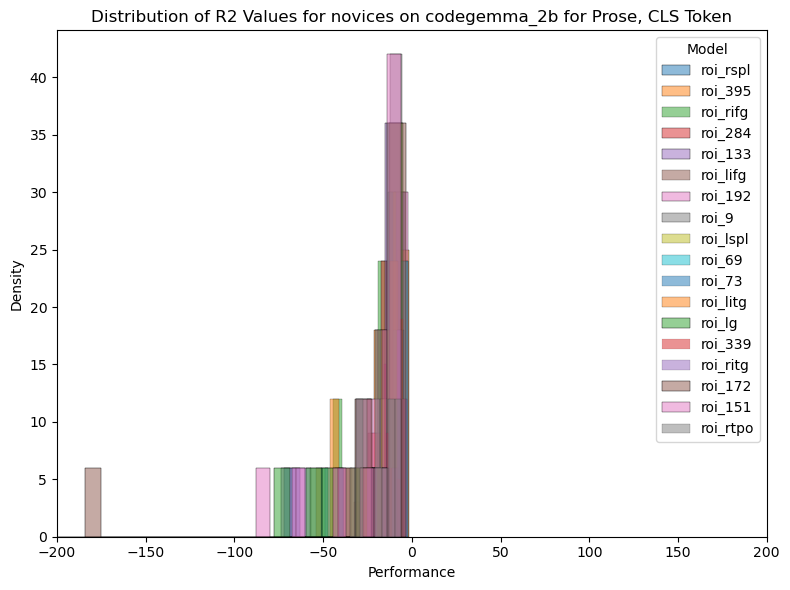

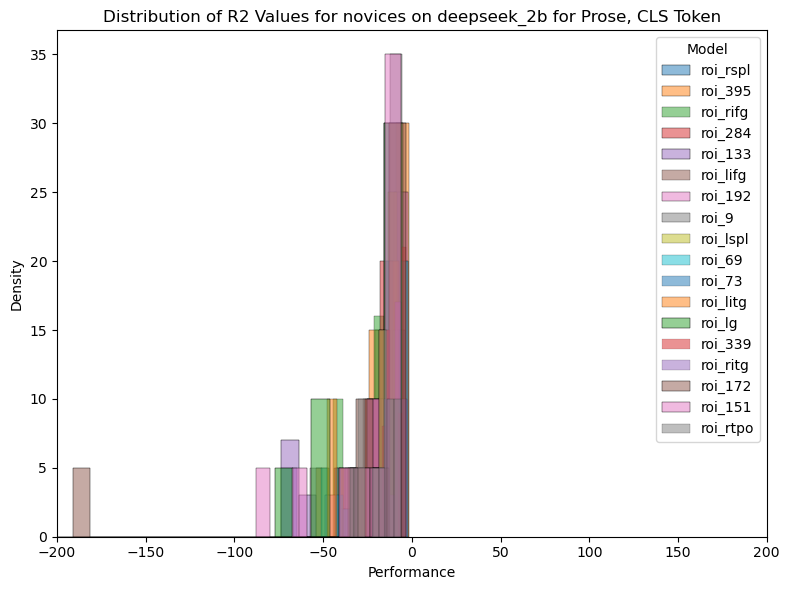

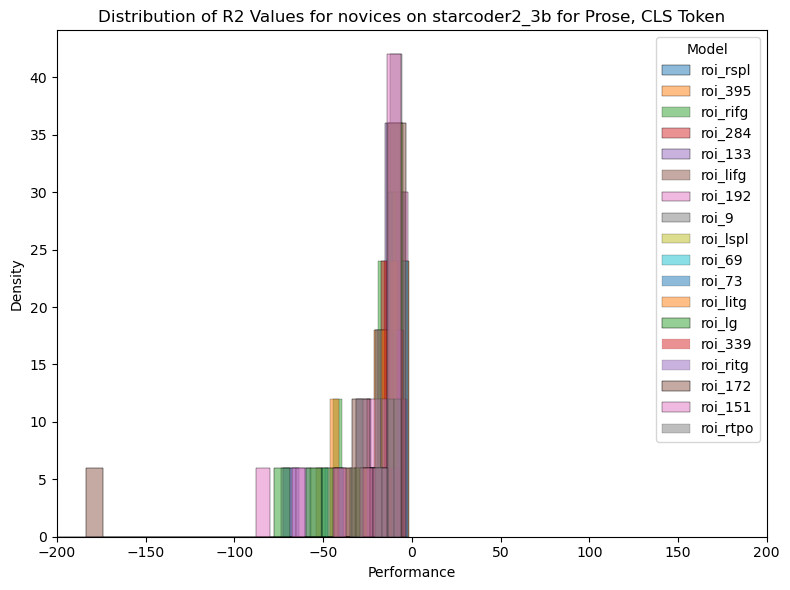

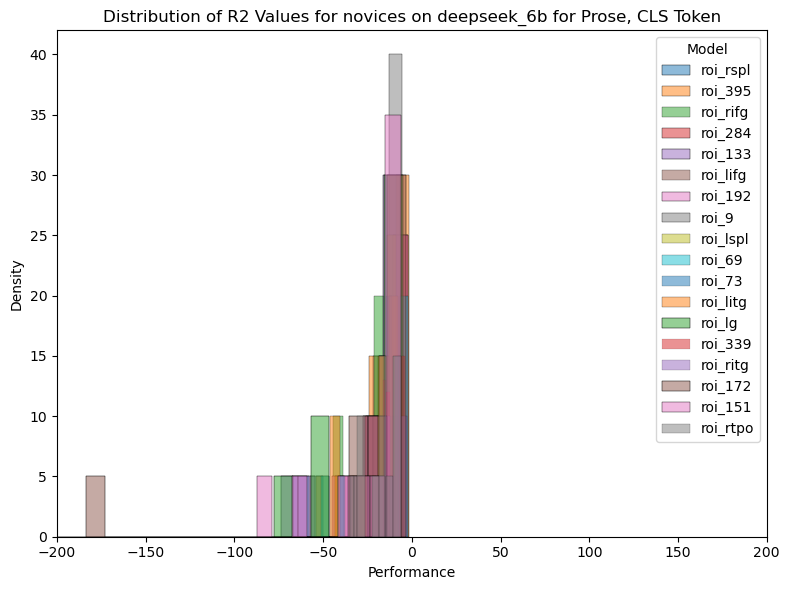

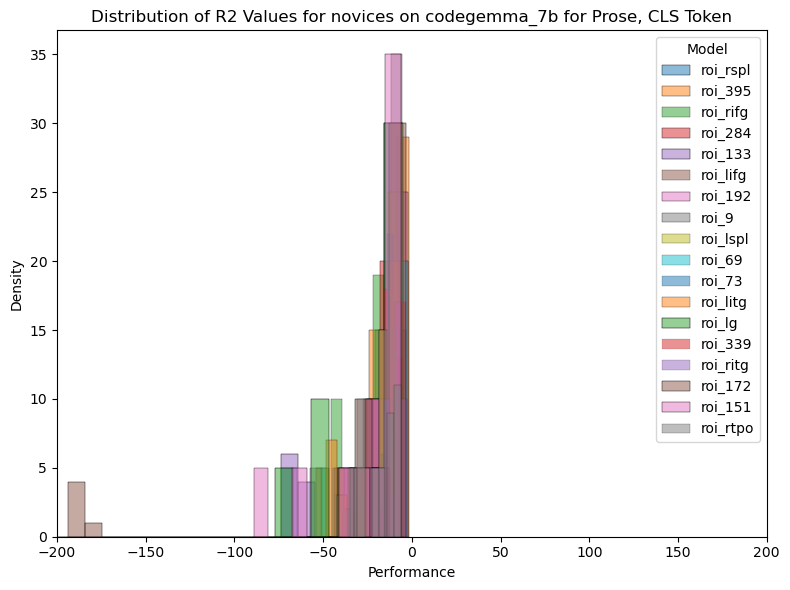

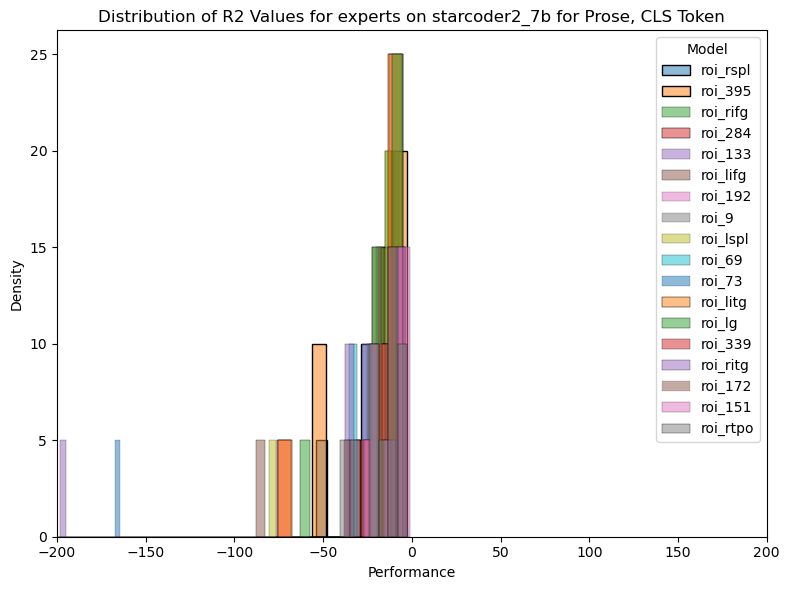

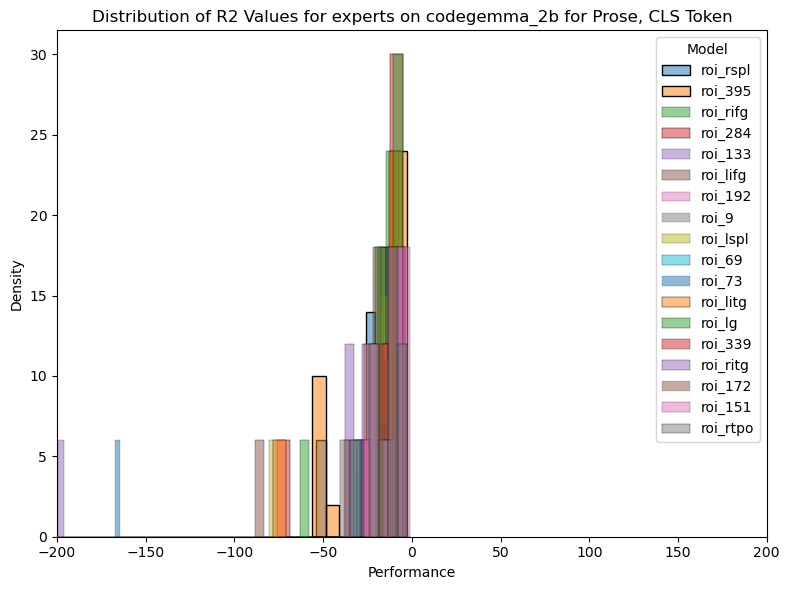

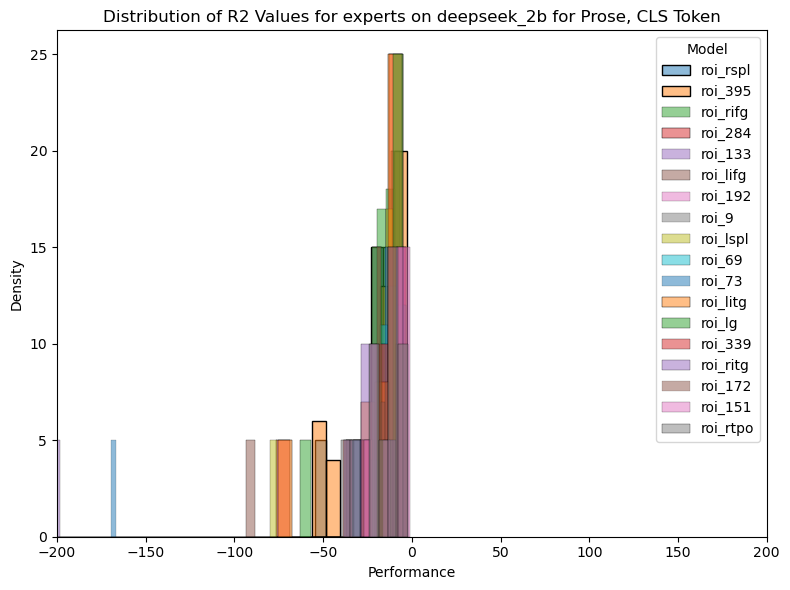

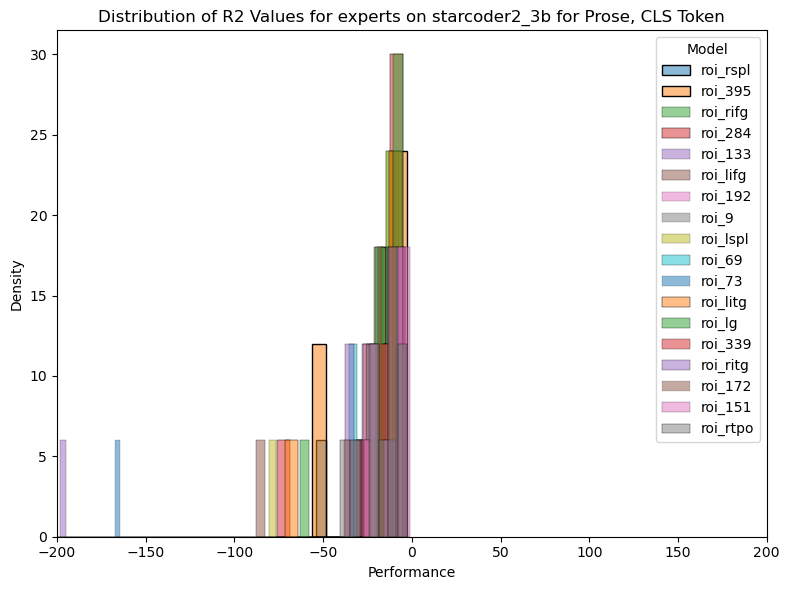

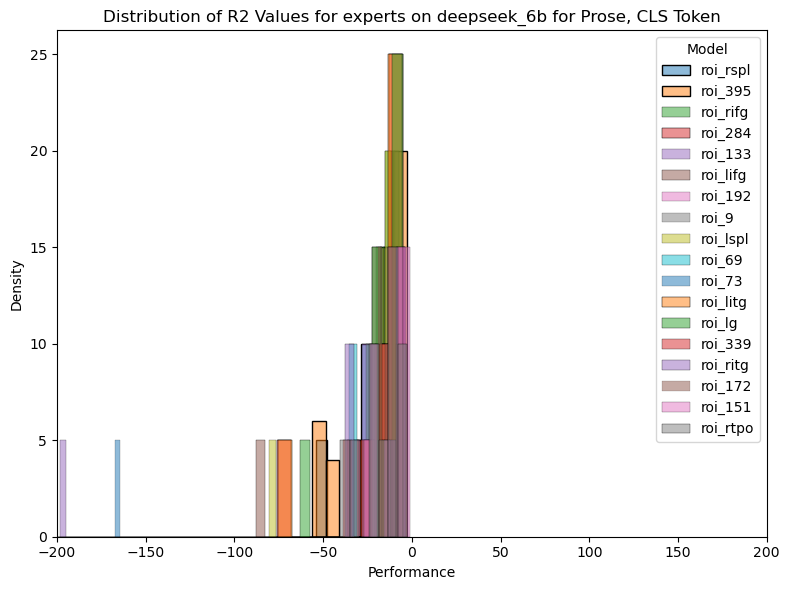

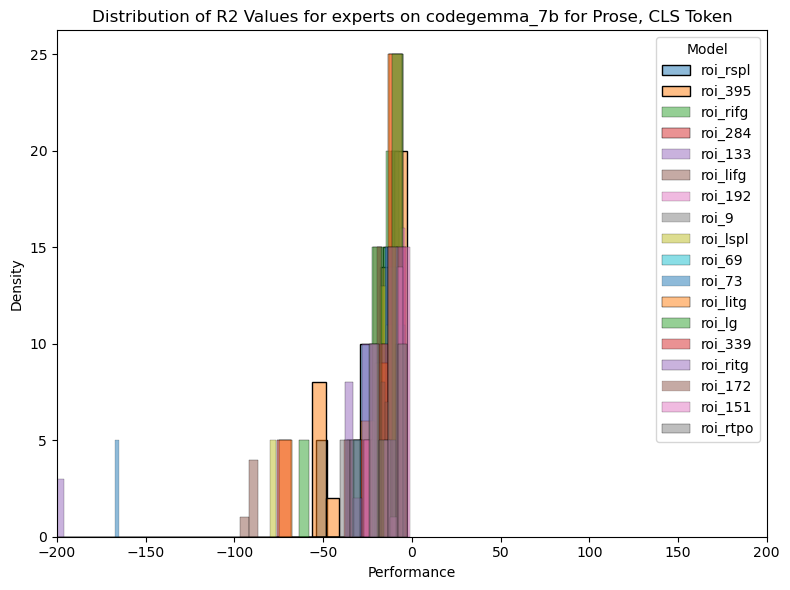

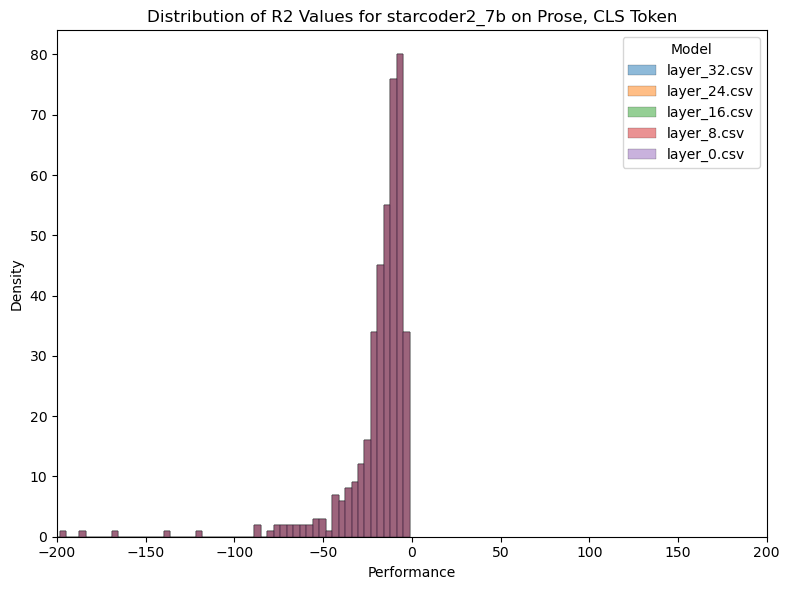

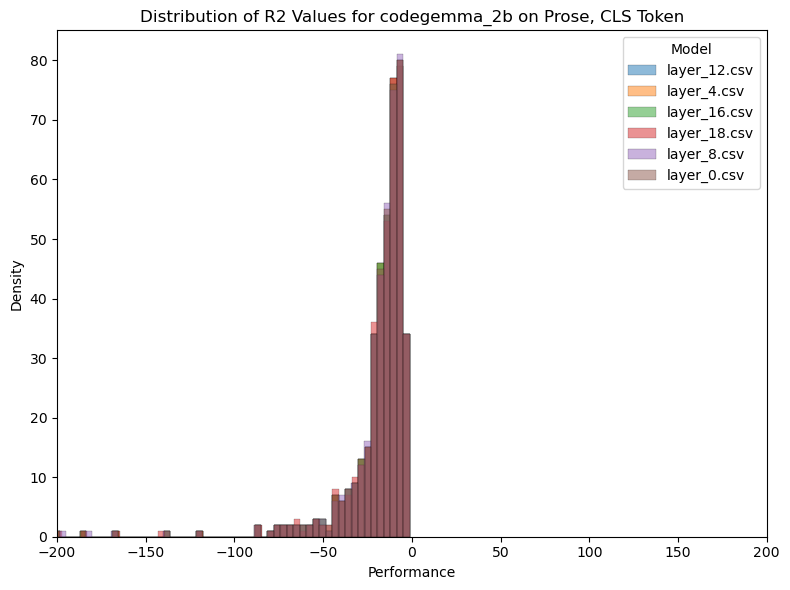

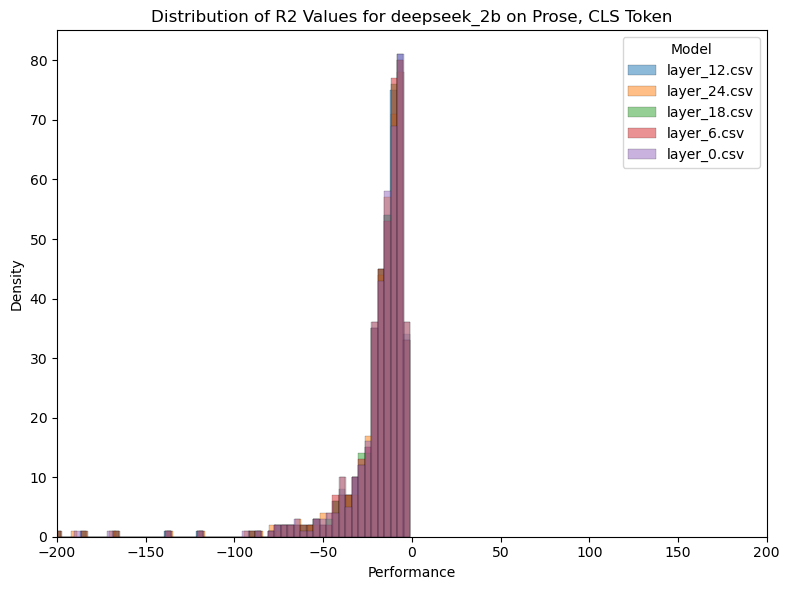

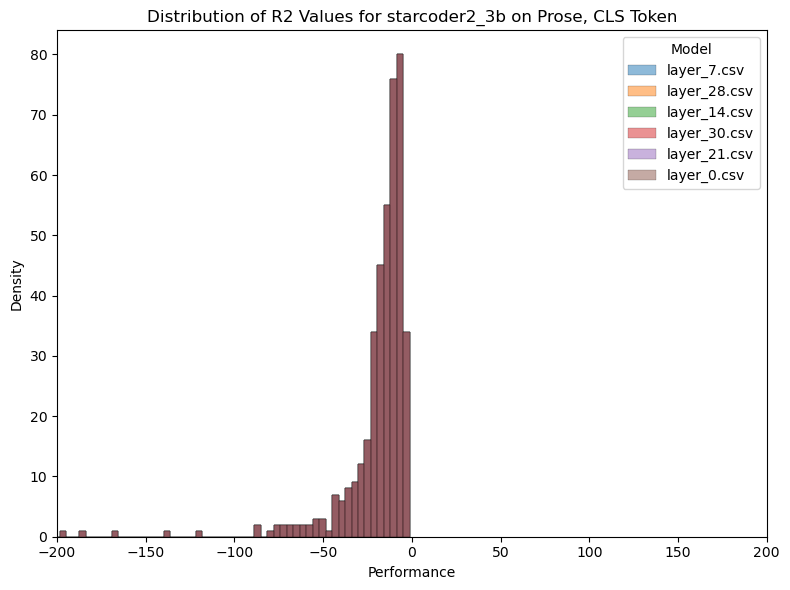

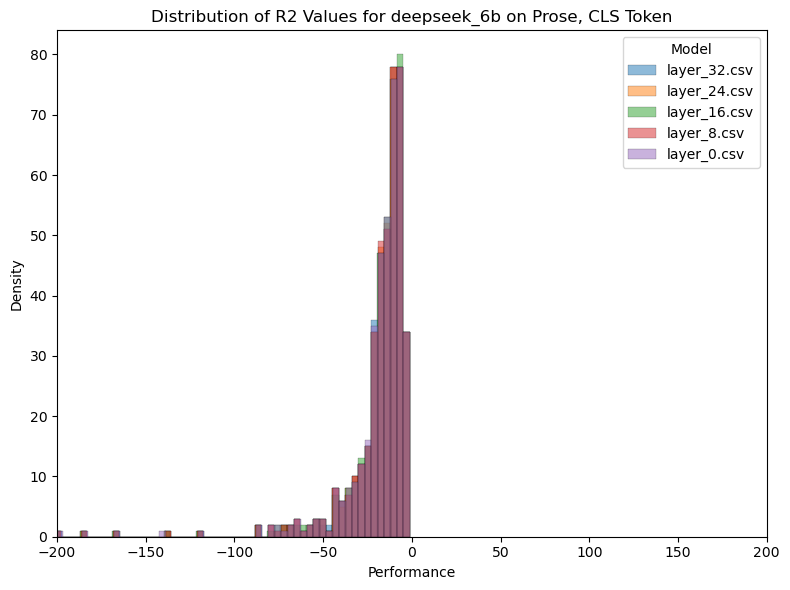

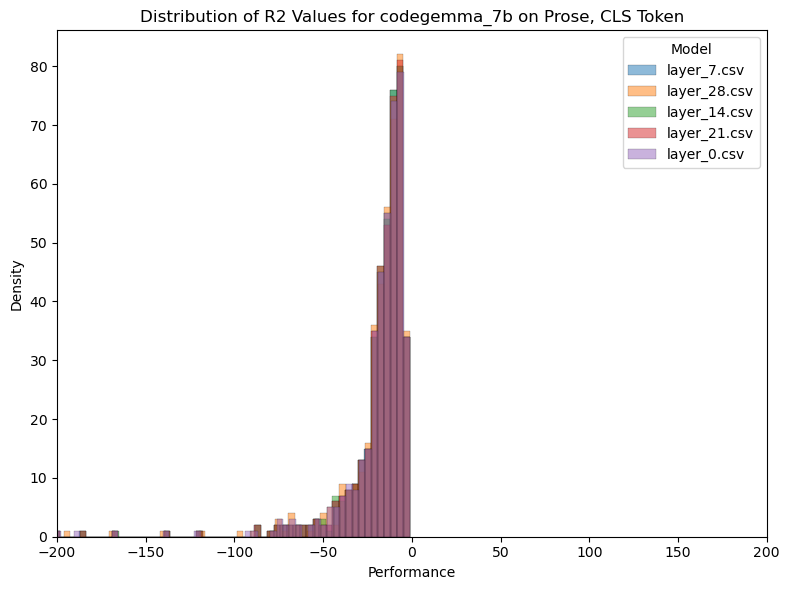

In [55]:
performance_by_roi(results_dict_cls_prose, 'CLS Token', 'Prose')

performance_by_expertise(results_dict_cls_prose, 'CLS Token', 'Prose')

performance_by_layer(results_dict_cls_prose, 'CLS Token', 'Prose')

### ROI Performance
I'd like to analyze how well each Region of Interest "aligns" with each layer of the models. I should report findings separately for each model, but aggregate across participants, ROIs, and layers.

iterate over participants, aggregate by ROI and layer

roi_findings = {}
for participant, roi_dict in results_dict.items():
    for roi, model_dict in roi_dict.items():
        # model_dict, layer
        # roi_findings keys should be rois, with values being dictionaries for each model, and performance results therein
        for model, layer_dict in model_dict.items():
            
            positive = [el for el in list(layer_dict.values()) if el > 0]
            if len(positive) > 0:
                print(positive)
            
            if roi not in roi_findings.keys():
                roi_findings[roi] = {}

            if model not in roi_findings[roi].keys():
                roi_findings[roi][model] = list(layer_dict.values())
            else:
                roi_findings[roi][model].extend(list(layer_dict.values()))


# Make separate plot for each ROI
for roi, model_data in roi_findings.items():
    plt.figure(figsize=(8, 6))
    
    # Plot each model's distribution
    for model, values in model_data.items():
        sns.histplot(values, label=model, fill=True, alpha=0.5)  # use sns.histplot if you prefer
    
    plt.title(f"Distribution of R2 Values for {roi}, Mean Pooling")
    plt.xlabel("Performance")
    plt.ylabel("Density")
    plt.legend(title="Model")
    plt.tight_layout()
    plt.show()

### Expertise
To compare model performance based on years of coding experience, I should have a dictionary with 
novices and experts as keys, then dictionaries as values where the keys are still models, and the values are aggregated across participants and layers

expertise_findings = {
    'novices' : {},
    'experts' : {}
}

expertise_roi_findings = {
    'novices' : {},
    'experts' : {}
}

experts = [ '112', '141', '105', '109', '118', '122', '129', '138', '143', '147', '101', '102', '108', '111', '201']

not_labeled = ['117', '204']

for participant, roi_dict in results_dict.items():
    if participant in experts:
        group = 'experts'
    elif participant not in experts and participant not in not_labeled:
        group = 'novices'
    else:
        continue

    for roi, model_dict in roi_dict.items():
        for model, layer_dict in model_dict.items():

            if model not in expertise_findings[group].keys():
                expertise_findings[group][model] = list(layer_dict.values())
            else:
                expertise_findings[group][model].extend(list(layer_dict.values()))

            if model not in expertise_roi_findings[group].keys():
                expertise_roi_findings[group][model] = {}
                
            if roi not in expertise_roi_findings[group][model].keys():
                expertise_roi_findings[group][model][roi] = list(layer_dict.values())
            else:
                expertise_roi_findings[group][model][roi].extend(list(layer_dict.values()))


# Make separate plot for each ROI
for group, model_data in expertise_findings.items():
    plt.figure(figsize=(8, 6))
    
    # Plot each model's distribution
    for model, values in model_data.items():
        sns.histplot(values, label=model, fill=True, alpha=0.5)  # use sns.histplot if you prefer
    
    plt.title(f"Distribution of R2 Values for {group}, Mean Pooling")
    plt.xlabel("Performance")
    plt.xlim([-200,200])
    plt.ylabel("Density")
    plt.legend(title="Model")
    plt.tight_layout()
    plt.show()

# Make separate plot for each ROI
for group, model_data in expertise_roi_findings.items():

    for model, roi_dict in model_data.items():
        
        plt.figure(figsize=(8, 6))
        
        for roi, values in roi_dict.items():
            sns.histplot(values, label=roi, fill=True, alpha=0.5)
        
        plt.title(f"Distribution of R2 Values for {group} on {model}, Mean Pooling")
        plt.xlabel("Performance")
        plt.xlim([-200,200])
        plt.ylabel("Density")
        plt.legend(title="Model")
        plt.tight_layout()
        plt.show()

### ROI Alignment with Layers

layer_findings = {}

# potential structure - model : layer

for participant, roi_dict in results_dict.items():
    for roi, model_dict in roi_dict.items():
        # model_dict, layer
        # layer_findings keys should be rois, with values being dictionaries for each model, and performance results therein
        for model, layer_dict in model_dict.items():
            
            if model not in layer_findings.keys():
                layer_findings[model] = {}
            
            for layer, value in layer_dict.items():
                if layer not in layer_findings[model].keys():
                    layer_findings[model][layer] = [value]
                
                else:
                    layer_findings[model][layer].append(value)

# Make separate plot for each ROI
for model, layer_data in layer_findings.items():
    plt.figure(figsize=(8, 6))
    
    # Plot each model's distribution
    for layer, values in layer_data.items():
        sns.histplot(values, label=layer, fill=True, alpha = 0.5)  # use sns.histplot if you prefer
    
    plt.title(f"Distribution of R2 Values for {model}, Mean Pooling")
    plt.xlabel("Performance")
    plt.ylabel("Density")
    plt.xlim([-200,200])
    plt.legend(title="Model")
    plt.tight_layout()
    plt.show()